In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

ANALYSIS_DIR = "/content/drive/MyDrive/Colab Notebooks/Data Analytics/group project/analysis_data"
os.makedirs(ANALYSIS_DIR, exist_ok=True)

print("Saved analysis folder:", ANALYSIS_DIR)

Saved analysis folder: /content/drive/MyDrive/Colab Notebooks/Data Analytics/group project/analysis_data


Phase 1: Compiling SPY/EEM price data


In [ ]:
import os
import pandas as pd
import numpy as np

# Section 1: Reading Price History, Organizing Date / Close / Return

# =========================
# path setting
# =========================
SPY_DIR = "/content/drive/MyDrive/Colab Notebooks/Data Analytics/group project/etf spy data"
EEM_DIR = "/content/drive/MyDrive/Colab Notebooks/Data Analytics/group project/etf eem data"
CLEAN_DIR = "/content/drive/MyDrive/Colab Notebooks/Data Analytics/group project/clean_data"
ANALYSIS_DIR = "/content/drive/MyDrive/Colab Notebooks/Data Analytics/group project/analysis_data"

os.makedirs(ANALYSIS_DIR, exist_ok=True)

spy_price_path = os.path.join(SPY_DIR, "Price History_20260413_2348 SPY.xlsm")
eem_price_path = os.path.join(EEM_DIR, "Price History_20260413_2355 EEM.xlsm")

print(spy_price_path)
print(eem_price_path)

print("SPY exists:", os.path.exists(spy_price_path))
print("EEM exists:", os.path.exists(eem_price_path))

# =========================
# read files
# =========================
spy_price_raw = pd.read_excel(spy_price_path)
eem_price_raw = pd.read_excel(eem_price_path)

spy_price_raw.columns = [str(c).strip() for c in spy_price_raw.columns]
eem_price_raw.columns = [str(c).strip() for c in eem_price_raw.columns]

print("SPY price columns:", spy_price_raw.columns.tolist())
print("EEM price columns:", eem_price_raw.columns.tolist())

print("\nSPY preview:")
print(spy_price_raw.head())

print("\nEEM preview:")
print(eem_price_raw.head())

/content/drive/MyDrive/Colab Notebooks/Data Analytics/group project/etf spy data/Price History_20260413_2348 SPY.xlsm
/content/drive/MyDrive/Colab Notebooks/Data Analytics/group project/etf eem data/Price History_20260413_2355 EEM.xlsm
SPY exists: True
EEM exists: True
SPY price columns: ['ETF', 'date', 'Close', 'Net', '%Chg', 'Open', 'Low', 'High', 'Volume', 'Turnover - USD']
EEM price columns: ['ETF', 'date', 'Close', 'Net', '%Chg', 'Open', 'Low', 'High', 'Volume', 'Turnover - USD']

SPY preview:
   ETF       date   Close   Net    %Chg    Open     Low    High       Volume  \
0  SPY 2014-01-02  182.92   NaN     NaN  183.98  182.48  184.07  119636836.0   
1  SPY 2014-01-03  182.89 -0.03 -0.0002  183.23  182.63  183.60   81390502.0   
2  SPY 2014-01-06  182.36 -0.52 -0.0029  183.49  182.08  183.56  108028139.0   
3  SPY 2014-01-07  183.48  1.12  0.0061  183.09  182.95  183.79   86144169.0   
4  SPY 2014-01-08  183.52  0.04  0.0002  183.45  182.89  183.83   96582234.0   

   Turnover - U

In [ ]:
# Paragraph 2: Clean up price data and calculate daily return

def clean_price_history(df, etf_name):
    data = df.copy()

    # common date name
    date_candidates = ["date", "Trade Date", "date"]
    price_candidates = ["Close", "Price Close", "Closing Price", "close"]

    date_col = None
    price_col = None

    for c in date_candidates:
        if c in data.columns:
            date_col = c
            break

    for c in price_candidates:
        if c in data.columns:
            price_col = c
            break

    if date_col is None:
        raise KeyError(f"{etf_name}: 找不到日期欄位")
    if price_col is None:
        raise KeyError(f"{etf_name}: 找不到收盤價欄位")

    data = data[[date_col, price_col]].copy()
    data = data.rename(columns={date_col: "date", price_col: "close"})

    data["date"] = pd.to_datetime(data["date"], errors="coerce")
    data["close"] = pd.to_numeric(data["close"], errors="coerce")

    data = data.dropna(subset=["date", "close"]).copy()
    data = data.sort_values("date").reset_index(drop=True)

    # log return
    data["log_return"] = np.log(data["close"] / data["close"].shift(1))

    # simple return
    data["simple_return"] = data["close"].pct_change()

    data["year"] = data["date"].dt.year
    data["month"] = data["date"].dt.to_period("M").astype(str)
    data["etf"] = etf_name

    return data


spy_price = clean_price_history(spy_price_raw, "SPY")
eem_price = clean_price_history(eem_price_raw, "EEM")

print("SPY cleaned shape:", spy_price.shape)
print("EEM cleaned shape:", eem_price.shape)

print("\nSPY cleaned preview:")
print(spy_price.head())

print("\nEEM cleaned preview:")
print(eem_price.head())

SPY cleaned shape: (2266, 7)
EEM cleaned shape: (2266, 7)

SPY cleaned preview:
        date   close  log_return  simple_return  year    month  etf
0 2014-01-02  182.92         NaN            NaN  2014  2014-01  SPY
1 2014-01-03  182.89   -0.000164      -0.000164  2014  2014-01  SPY
2 2014-01-06  182.36   -0.002902      -0.002898  2014  2014-01  SPY
3 2014-01-07  183.48    0.006123       0.006142  2014  2014-01  SPY
4 2014-01-08  183.52    0.000218       0.000218  2014  2014-01  SPY

EEM cleaned preview:
        date  close  log_return  simple_return  year    month  etf
0 2014-01-02  39.95         NaN            NaN  2014  2014-01  EEM
1 2014-01-03  39.88   -0.001754      -0.001752  2014  2014-01  EEM
2 2014-01-06  39.50   -0.009574      -0.009529  2014  2014-01  EEM
3 2014-01-07  39.67    0.004295       0.004304  2014  2014-01  EEM
4 2014-01-08  39.54   -0.003282      -0.003277  2014  2014-01  EEM


In [ ]:
# Section 3: First save the price clean file

spy_price.to_excel(os.path.join(ANALYSIS_DIR, "SPY_price_clean.xlsx"), index=False)
eem_price.to_excel(os.path.join(ANALYSIS_DIR, "EEM_price_clean.xlsx"), index=False)

print("Saved:", os.path.join(ANALYSIS_DIR, "SPY_price_clean.xlsx"))
print("Saved:", os.path.join(ANALYSIS_DIR, "EEM_price_clean.xlsx"))

Saved: /content/drive/MyDrive/Colab Notebooks/Data Analytics/group project/analysis_data/SPY_price_clean.xlsx
Saved: /content/drive/MyDrive/Colab Notebooks/Data Analytics/group project/analysis_data/EEM_price_clean.xlsx


In [ ]:
# Paragraph 4: Read "holdings + ESG", first look at the ESG score column.

import os
import pandas as pd
import numpy as np

CLEAN_DIR = "/content/drive/MyDrive/Colab Notebooks/Data Analytics/group project/clean_data"
ANALYSIS_DIR = "/content/drive/MyDrive/Colab Notebooks/Data Analytics/group project/analysis_data"

spy_holdings_path = os.path.join(CLEAN_DIR, "SPY_final_cleaned_with_lag_esg_v2.xlsx")
eem_holdings_path = os.path.join(CLEAN_DIR, "EEM_final_cleaned_with_lag_esg_v3.xlsx")

spy_holdings = pd.read_excel(spy_holdings_path)
eem_holdings = pd.read_excel(eem_holdings_path)

spy_holdings.columns = [str(c).strip() for c in spy_holdings.columns]
eem_holdings.columns = [str(c).strip() for c in eem_holdings.columns]

print("SPY columns:")
print(spy_holdings.columns.tolist())

print("\nEEM columns:")
print(eem_holdings.columns.tolist())

print("\nSPY preview:")
print(spy_holdings.head())

print("\nEEM preview:")
print(eem_holdings.head())

SPY columns:
['etf', 'date', 'RIC', 'Name', 'Country', 'Weight', 'No. Shares', 'old_RIC', 'year', 'Name_norm', 'flag_name_multi_ric', 'flag_ric_multi_name', 'problem_flag', 'Date', 'Financial Period Absolute', 'Calc Date', 'ESG Score', 'Environmental Pillar Score', 'Social Pillar Score', 'Governance Pillar Score', 'ESG Combined Score Grade', 'year_esg', 'lag_year', 'type1_flag', 'type2_flag', 'type3_flag']

EEM columns:
['etf', 'date', 'RIC', 'Name', 'Country', 'Weight', 'No. Shares', 'old_RIC', 'year', 'Name_norm', 'flag_name_multi_ric', 'flag_ric_multi_name', 'problem_flag', 'Date', 'Financial Period Absolute', 'Calc Date', 'ESG Score', 'Environmental Pillar Score', 'Social Pillar Score', 'Governance Pillar Score', 'ESG Combined Score Grade', 'year_esg', 'lag_year', 'type1_flag', 'type2_flag', 'type3_flag']

SPY preview:
   etf        date        RIC                         Name        Country  \
0  SPY  2015-12-31      MMM.N                    3M CO ORD  UNITED STATES   
1  SPY  201

Section 5: Dividing ESG scores into 8 categories

Here's the classification from the paper:

[8,10]
[7,8)
[6,7)
[5,6)
[4,5)
[3,4)
[1,3)
[0,1)

In [ ]:
def assign_esg_class_from_100(score):
    if pd.isna(score):
        return pd.NA

    try:
        score = float(score)
    except:
        return pd.NA

    # 先把 0-100 轉成 0-10
    score_10 = score / 10.0

    if 8 <= score_10 <= 10:
        return "A"
    elif 7 <= score_10 < 8:
        return "B"
    elif 6 <= score_10 < 7:
        return "C"
    elif 5 <= score_10 < 6:
        return "D"
    elif 4 <= score_10 < 5:
        return "E"
    elif 3 <= score_10 < 4:
        return "F"
    elif 1 <= score_10 < 3:
        return "G"
    elif 0 <= score_10 < 1:
        return "H"
    else:
        return pd.NA


spy_holdings_resg = spy_holdings.copy()
eem_holdings_resg = eem_holdings.copy()

spy_holdings_resg["ESG Score"] = pd.to_numeric(spy_holdings_resg["ESG Score"], errors="coerce")
eem_holdings_resg["ESG Score"] = pd.to_numeric(eem_holdings_resg["ESG Score"], errors="coerce")

# Leave an extra column for the scaled score; it will make checking easier later.
spy_holdings_resg["ESG Score 10"] = spy_holdings_resg["ESG Score"] / 10
eem_holdings_resg["ESG Score 10"] = eem_holdings_resg["ESG Score"] / 10

spy_holdings_resg["esg_class"] = spy_holdings_resg["ESG Score"].apply(assign_esg_class_from_100)
eem_holdings_resg["esg_class"] = eem_holdings_resg["ESG Score"].apply(assign_esg_class_from_100)

print("SPY ESG class counts:")
print(spy_holdings_resg["esg_class"].value_counts(dropna=False))

print("\nEEM ESG class counts:")
print(eem_holdings_resg["esg_class"].value_counts(dropna=False))

print("\nSPY preview:")
print(spy_holdings_resg[["RIC", "year", "ESG Score", "ESG Score 10", "esg_class"]].head(10))

print("\nEEM preview:")
print(eem_holdings_resg[["RIC", "year", "ESG Score", "ESG Score 10", "esg_class"]].head(10))

SPY ESG class counts:
esg_class
C       929
B       779
D       702
E       559
A       432
F       315
G       190
<NA>     93
H         6
Name: count, dtype: int64

EEM ESG class counts:
esg_class
D       1399
G       1351
E       1221
C       1116
F       1013
B        873
A        436
<NA>     413
H        195
Name: count, dtype: int64

SPY preview:
         RIC  year  ESG Score  ESG Score 10 esg_class
0      MMM.N  2015  89.996881      8.999688         A
1      ABT.N  2015  74.675253      7.467525         B
2     ABBV.N  2015  61.332762      6.133276         C
3      ACN.N  2015  72.548286      7.254829         B
4  ATVIn.BCU  2015  42.013155      4.201315         E
5    ADBE.OQ  2015  70.261748      7.026175         B
6      ADT.N  2015        NaN           NaN      <NA>
7      AAP.N  2015  38.746860      3.874686         F
8      AES.N  2015        NaN           NaN      <NA>
9  AET.N^K18  2015  66.872658      6.687266         C

EEM preview:
             RIC  year  ESG Score  E

Paragraph 6: First, look at the annual ESG coverage.

In [ ]:
def check_esg_coverage(df, etf_name):
    coverage = (
        df.groupby("year")
        .agg(
            total_weight=("Weight", "sum"),
            esg_weight=("Weight", lambda x: x[df.loc[x.index, "ESG Score"].notna()].sum()),
            n_obs=("RIC", "count"),
            n_esg=("ESG Score", lambda x: x.notna().sum())
        )
        .reset_index()
    )
    coverage["weight_coverage_ratio"] = coverage["esg_weight"] / coverage["total_weight"]
    coverage["obs_coverage_ratio"] = coverage["n_esg"] / coverage["n_obs"]

    print(f"\n{etf_name} ESG coverage:")
    print(coverage)

    return coverage

spy_coverage = check_esg_coverage(spy_holdings_resg, "SPY")
eem_coverage = check_esg_coverage(eem_holdings_resg, "EEM")


SPY ESG coverage:
   year  total_weight  esg_weight  n_obs  n_esg  weight_coverage_ratio  \
0  2015      0.996636    0.946406    502    464               0.949600   
1  2016      1.001486    0.983780    501    490               0.982320   
2  2017      0.976579    0.959534    500    491               0.982546   
3  2018      0.985586    0.982096    502    498               0.996459   
4  2019      1.015046    1.004676    500    491               0.989784   
5  2020      1.010258    1.005205    500    492               0.994998   
6  2021      1.000209    0.995892    500    493               0.995684   
7  2022      0.999740    0.995916    500    493               0.996175   

   obs_coverage_ratio  
0            0.924303  
1            0.978044  
2            0.982000  
3            0.992032  
4            0.982000  
5            0.984000  
6            0.986000  
7            0.986000  

EEM ESG coverage:
   year  total_weight  esg_weight  n_obs  n_esg  weight_coverage_ratio  \
0  20

Paragraph 7: First calculate the basic RESG (only companies with ESG are used, and the weights are re-standardized).

In [ ]:
def calculate_basic_resg(df, etf_name):
    data = df.copy()

    # Keep only data containing ESG classes
    data = data[data["esg_class"].notna()].copy()

    # Renormalize the weights of classes with ESG each year
    data["weight_norm"] = data.groupby("year")["Weight"].transform(lambda x: x / x.sum())

    # Calculate the weight percentage p_i for each ESG class each year
    p_table = (
        data.groupby(["year", "esg_class"])["weight_norm"]
        .sum()
        .reset_index(name="p_i")
    )

    # entropy component
    p_table["entropy_component"] = -p_table["p_i"] * np.log(p_table["p_i"])

    # Sum the results each year RESG
    resg_yearly = (
        p_table.groupby("year")["entropy_component"]
        .sum()
        .reset_index(name="RESG_basic")
    )

    print(f"\n{etf_name} p_i table preview:")
    print(p_table.head(20))

    print(f"\n{etf_name} RESG yearly:")
    print(resg_yearly)

    return p_table, resg_yearly

spy_p_table, spy_resg_yearly = calculate_basic_resg(spy_holdings_resg, "SPY")
eem_p_table, eem_resg_yearly = calculate_basic_resg(eem_holdings_resg, "EEM")


SPY p_i table preview:
    year esg_class       p_i  entropy_component
0   2015         A  0.109091           0.241699
1   2015         B  0.187547           0.313903
2   2015         C  0.215526           0.330762
3   2015         D  0.218201           0.332176
4   2015         E  0.117537           0.251647
5   2015         F  0.077435           0.198103
6   2015         G  0.071974           0.189397
7   2015         H  0.002688           0.015910
8   2016         A  0.165709           0.297865
9   2016         B  0.210825           0.328197
10  2016         C  0.220624           0.333428
11  2016         D  0.183822           0.311355
12  2016         E  0.088449           0.214517
13  2016         F  0.069118           0.184679
14  2016         G  0.059693           0.168248
15  2016         H  0.001762           0.011171
16  2017         A  0.185620           0.312594
17  2017         B  0.216406           0.331231
18  2017         C  0.296156           0.360383
19  2017        

Paragraph 8: Save the results first.

In [ ]:
spy_holdings_resg.to_excel(os.path.join(ANALYSIS_DIR, "SPY_holdings_with_esg_class.xlsx"), index=False)
eem_holdings_resg.to_excel(os.path.join(ANALYSIS_DIR, "EEM_holdings_with_esg_class.xlsx"), index=False)

spy_p_table.to_excel(os.path.join(ANALYSIS_DIR, "SPY_esg_class_weights.xlsx"), index=False)
eem_p_table.to_excel(os.path.join(ANALYSIS_DIR, "EEM_esg_class_weights.xlsx"), index=False)

spy_resg_yearly.to_excel(os.path.join(ANALYSIS_DIR, "SPY_resg_yearly_basic.xlsx"), index=False)
eem_resg_yearly.to_excel(os.path.join(ANALYSIS_DIR, "EEM_resg_yearly_basic.xlsx"), index=False)

print("Saved RESG basic outputs to:", ANALYSIS_DIR)

Saved RESG basic outputs to: /content/drive/MyDrive/Colab Notebooks/Data Analytics/group project/analysis_data


Paragraph 9: Perform Monthly Gaussian VaR

This step will initially use only ETF prices:

99% confidence variance-covariance method; 260-day rolling window; Estimate the next period's VaR at the end of each month.

In [ ]:
# 9.1 First, establish end-of-month observation points.

import os
import pandas as pd
import numpy as np
from scipy.stats import norm

ANALYSIS_DIR = "/content/drive/MyDrive/Colab Notebooks/Data Analytics/group project/analysis_data"

spy_price = pd.read_excel(os.path.join(ANALYSIS_DIR, "SPY_price_clean.xlsx"))
eem_price = pd.read_excel(os.path.join(ANALYSIS_DIR, "EEM_price_clean.xlsx"))

spy_price["date"] = pd.to_datetime(spy_price["date"])
eem_price["date"] = pd.to_datetime(eem_price["date"])

print("SPY shape:", spy_price.shape)
print("EEM shape:", eem_price.shape)

spy_price.head()

SPY shape: (2266, 7)
EEM shape: (2266, 7)


,date,close,log_return,simple_return,year,month,etf
0,2014-01-02,182.92,NaN,NaN,2014,2014-01,SPY
1,2014-01-03,182.89,-0.000164,-0.000164,2014,2014-01,SPY
2,2014-01-06,182.36,-0.002902,-0.002898,2014,2014-01,SPY
3,2014-01-07,183.48,0.006123,0.006142,2014,2014-01,SPY
4,2014-01-08,183.52,0.000218,0.000218,2014,2014-01,SPY


In [ ]:
# Find out on the last trading day of each month

def get_month_end_obs(price_df):
    df = price_df.copy()
    df["month_period"] = df["date"].dt.to_period("M")

    month_end = (
        df.groupby("month_period")
        .tail(1)
        .copy()
        .reset_index(drop=True)
    )
    return month_end

spy_month_end = get_month_end_obs(spy_price)
eem_month_end = get_month_end_obs(eem_price)

print("SPY month-end rows:", len(spy_month_end))
print("EEM month-end rows:", len(eem_month_end))

print("\nSPY month-end preview:")
print(spy_month_end[["date", "close", "month_period"]].head(12))

print("\nEEM month-end preview:")
print(eem_month_end[["date", "close", "month_period"]].head(12))

SPY month-end rows: 108
EEM month-end rows: 108

SPY month-end preview:
         date   close month_period
0  2014-01-31  178.18      2014-01
1  2014-02-28  186.29      2014-02
2  2014-03-31  187.01      2014-03
3  2014-04-30  188.31      2014-04
4  2014-05-30  192.68      2014-05
5  2014-06-30  195.72      2014-06
6  2014-07-31  193.09      2014-07
7  2014-08-29  200.71      2014-08
8  2014-09-30  197.02      2014-09
9  2014-10-31  201.66      2014-10
10 2014-11-28  207.20      2014-11
11 2014-12-31  205.54      2014-12

EEM month-end preview:
         date  close month_period
0  2014-01-31  37.96      2014-01
1  2014-02-28  39.24      2014-02
2  2014-03-31  40.76      2014-03
3  2014-04-30  41.08      2014-04
4  2014-05-30  42.29      2014-05
5  2014-06-30  42.97      2014-06
6  2014-07-31  43.56      2014-07
7  2014-08-29  44.79      2014-08
8  2014-09-30  41.31      2014-09
9  2014-10-31  41.90      2014-10
10 2014-11-28  41.25      2014-11
11 2014-12-31  39.05      2014-12


9.2 Calculate the rolling 260-day Gaussian VaR

VaRt​=z0.99​⋅σt​

Where:

1. z_{0.99} = 2.326347874

2. σt is the standard deviation of the log return for the first 260 trading days.

In [ ]:
# 9.2 Calculate rolling 260-day Gaussian VaR

Z_99 = norm.ppf(0.99)
ROLLING_WINDOW = 260

def calculate_monthly_var(price_df, etf_name, return_col="log_return", window=260, z_score=Z_99):
    df = price_df.copy().sort_values("date").reset_index(drop=True)

    # rolling std used for the first 260 days
    df["rolling_sigma"] = df[return_col].rolling(window=window).std()

    # daily Gaussian VaR
    df["VaR_99_daily"] = z_score * df["rolling_sigma"]

    # Sampling at the end of the month
    df["month_period"] = df["date"].dt.to_period("M")
    month_end = df.groupby("month_period").tail(1).copy().reset_index(drop=True)

    month_end["etf"] = etf_name
    month_end["year"] = month_end["date"].dt.year
    month_end["month"] = month_end["date"].dt.month

    return df, month_end

spy_price_var_daily, spy_var_monthly = calculate_monthly_var(spy_price, "SPY")
eem_price_var_daily, eem_var_monthly = calculate_monthly_var(eem_price, "EEM")

print("SPY monthly VaR preview:")
print(spy_var_monthly[["date", "close", "rolling_sigma", "VaR_99_daily"]].head(15))

print("\nEEM monthly VaR preview:")
print(eem_var_monthly[["date", "close", "rolling_sigma", "VaR_99_daily"]].head(15))

SPY monthly VaR preview:
         date   close  rolling_sigma  VaR_99_daily
0  2014-01-31  178.18            NaN           NaN
1  2014-02-28  186.29            NaN           NaN
2  2014-03-31  187.01            NaN           NaN
3  2014-04-30  188.31            NaN           NaN
4  2014-05-30  192.68            NaN           NaN
5  2014-06-30  195.72            NaN           NaN
6  2014-07-31  193.09            NaN           NaN
7  2014-08-29  200.71            NaN           NaN
8  2014-09-30  197.02            NaN           NaN
9  2014-10-31  201.66            NaN           NaN
10 2014-11-28  207.20            NaN           NaN
11 2014-12-31  205.54            NaN           NaN
12 2015-01-30  199.45       0.007461      0.017358
13 2015-02-27  210.66       0.007152      0.016637
14 2015-03-31  206.43       0.007399      0.017213

EEM monthly VaR preview:
         date  close  rolling_sigma  VaR_99_daily
0  2014-01-31  37.96            NaN           NaN
1  2014-02-28  39.24            N

In [ ]:
# 9.3 save the results

spy_price_var_daily.to_excel(os.path.join(ANALYSIS_DIR, "SPY_price_with_rolling_var_daily.xlsx"), index=False)
eem_price_var_daily.to_excel(os.path.join(ANALYSIS_DIR, "EEM_price_with_rolling_var_daily.xlsx"), index=False)

spy_var_monthly.to_excel(os.path.join(ANALYSIS_DIR, "SPY_var_monthly.xlsx"), index=False)
eem_var_monthly.to_excel(os.path.join(ANALYSIS_DIR, "EEM_var_monthly.xlsx"), index=False)

print("Saved monthly VaR files.")

Saved monthly VaR files.


In [ ]:
spy_var_monthly.head(15)

,date,close,log_return,simple_return,year,month,etf,rolling_sigma,VaR_99_daily,month_period
0,2014-01-31,178.18,-0.005876,-0.005858,2014,1,SPY,NaN,NaN,2014-01
1,2014-02-28,186.29,0.002526,0.002529,2014,2,SPY,NaN,NaN,2014-02
2,2014-03-31,187.01,0.008161,0.008195,2014,3,SPY,NaN,NaN,2014-03
3,2014-04-30,188.31,0.002978,0.002983,2014,4,SPY,NaN,NaN,2014-04
4,2014-05-30,192.68,0.001610,0.001611,2014,5,SPY,NaN,NaN,2014-05
5,2014-06-30,195.72,-0.000511,-0.000511,2014,6,SPY,NaN,NaN,2014-06
6,2014-07-31,193.09,-0.019946,-0.019748,2014,7,SPY,NaN,NaN,2014-07
7,2014-08-29,200.71,0.002844,0.002848,2014,8,SPY,NaN,NaN,2014-08
8,2014-09-30,197.02,-0.002636,-0.002632,2014,9,SPY,NaN,NaN,2014-09
9,2014-10-31,201.66,0.011371,0.011435,2014,10,SPY,NaN,NaN,2014-10


In [ ]:
eem_var_monthly.head(15)

,date,close,log_return,simple_return,year,month,etf,rolling_sigma,VaR_99_daily,month_period
0,2014-01-31,37.96,0.001582,0.001583,2014,1,EEM,NaN,NaN,2014-01
1,2014-02-28,39.24,-0.006857,-0.006834,2014,2,EEM,NaN,NaN,2014-02
2,2014-03-31,40.76,0.006399,0.006420,2014,3,EEM,NaN,NaN,2014-03
3,2014-04-30,41.08,-0.001946,-0.001944,2014,4,EEM,NaN,NaN,2014-04
4,2014-05-30,42.29,-0.013855,-0.013759,2014,5,EEM,NaN,NaN,2014-05
5,2014-06-30,42.97,-0.002789,-0.002785,2014,6,EEM,NaN,NaN,2014-06
6,2014-07-31,43.56,-0.017522,-0.017370,2014,7,EEM,NaN,NaN,2014-07
7,2014-08-29,44.79,-0.001562,-0.001560,2014,8,EEM,NaN,NaN,2014-08
8,2014-09-30,41.31,0.000000,0.000000,2014,9,EEM,NaN,NaN,2014-09
9,2014-10-31,41.90,0.004305,0.004314,2014,10,EEM,NaN,NaN,2014-10


In [ ]:
print(spy_var_monthly.loc[spy_var_monthly["year"] == 2020, ["date", "VaR_99_daily"]].head(12))
print(eem_var_monthly.loc[eem_var_monthly["year"] == 2020, ["date", "VaR_99_daily"]].head(12))

         date  VaR_99_daily
72 2020-01-31      0.017570
73 2020-02-28      0.019784
74 2020-03-31      0.042794
75 2020-04-30      0.045759
76 2020-05-29      0.046300
77 2020-06-30      0.047574
78 2020-07-31      0.047778
79 2020-08-31      0.047113
80 2020-09-30      0.047898
81 2020-10-30      0.048312
82 2020-11-30      0.048781
83 2020-12-31      0.048825
         date  VaR_99_daily
72 2020-01-31      0.022842
73 2020-02-28      0.023779
74 2020-03-31      0.044559
75 2020-04-30      0.046767
76 2020-05-29      0.047265
77 2020-06-30      0.048378
78 2020-07-31      0.049217
79 2020-08-31      0.048822
80 2020-09-30      0.049123
81 2020-10-30      0.049271
82 2020-11-30      0.049726
83 2020-12-31      0.049915


Paragraph 10: Mapping Monthly VaR to the Daily Return of the Next Month

The paper's logic is:

Calculate the VaR at the end of the month using the previous 260 days.

Use this VaR to check if the daily losses for the next month exceed the target.

Therefore, first create a function to map the VaR at the end of each month to the daily return for the next month.

In [ ]:
import os
import pandas as pd
import numpy as np

ANALYSIS_DIR = "/content/drive/MyDrive/Colab Notebooks/Data Analytics/group project/analysis_data"

spy_price_var_daily = pd.read_excel(os.path.join(ANALYSIS_DIR, "SPY_price_with_rolling_var_daily.xlsx"))
eem_price_var_daily = pd.read_excel(os.path.join(ANALYSIS_DIR, "EEM_price_with_rolling_var_daily.xlsx"))

spy_var_monthly = pd.read_excel(os.path.join(ANALYSIS_DIR, "SPY_var_monthly.xlsx"))
eem_var_monthly = pd.read_excel(os.path.join(ANALYSIS_DIR, "EEM_var_monthly.xlsx"))

# Date sorting
for df in [spy_price_var_daily, eem_price_var_daily, spy_var_monthly, eem_var_monthly]:
    df["date"] = pd.to_datetime(df["date"])

def assign_next_month_for_backtest(monthly_var_df, daily_price_df, etf_name):
    monthly = monthly_var_df.copy()
    daily = daily_price_df.copy()

    # The VaR at the end of the current month is used to predict the next month
    monthly["forecast_month"] = (monthly["date"] + pd.offsets.MonthBegin(1)).dt.to_period("M")
    daily["actual_month"] = daily["date"].dt.to_period("M")

    # Only retain the end-of-month VaR:
    monthly = monthly[monthly["VaR_99_daily"].notna()].copy()

    # merge: End-of-month VaR -> Daily pay for the next month
    merged = daily.merge(
        monthly[["date", "forecast_month", "VaR_99_daily", "etf"]],
        left_on="actual_month",
        right_on="forecast_month",
        how="left",
        suffixes=("", "_var")
    )

    merged["forecast_origin_date"] = merged["date_var"]
    merged = merged.drop(columns=["date_var"], errors="ignore")
    merged["etf"] = etf_name

    return merged

spy_backtest_daily = assign_next_month_for_backtest(spy_var_monthly, spy_price_var_daily, "SPY")
eem_backtest_daily = assign_next_month_for_backtest(eem_var_monthly, eem_price_var_daily, "EEM")

print("SPY backtest preview:")
print(spy_backtest_daily[["date", "actual_month", "forecast_origin_date", "log_return", "VaR_99_daily"]].head(15))

print("\nEEM backtest preview:")
print(eem_backtest_daily[["date", "actual_month", "forecast_origin_date", "log_return", "VaR_99_daily"]].head(15))

SPY backtest preview:
         date actual_month forecast_origin_date  log_return  VaR_99_daily
0  2014-01-02      2014-01                  NaT         NaN           NaN
1  2014-01-03      2014-01                  NaT   -0.000164           NaN
2  2014-01-06      2014-01                  NaT   -0.002902           NaN
3  2014-01-07      2014-01                  NaT    0.006123           NaN
4  2014-01-08      2014-01                  NaT    0.000218           NaN
5  2014-01-09      2014-01                  NaT    0.000654           NaN
6  2014-01-10      2014-01                  NaT    0.002719           NaN
7  2014-01-13      2014-01                  NaT   -0.013394           NaN
8  2014-01-14      2014-01                  NaT    0.010839           NaN
9  2014-01-15      2014-01                  NaT    0.005376           NaN
10 2014-01-16      2014-01                  NaT   -0.001301           NaN
11 2014-01-17      2014-01                  NaT   -0.004238           NaN
12 2014-01-21   

In [ ]:
# Paragraph 11: Definition of loss, violation, unexpected loss

def compute_var_violations(backtest_df):
    df = backtest_df.copy()

    # daily loss = - log return
    df["loss"] = -df["log_return"]

    # Only look at data with forecast VaR
    df = df[df["VaR_99_daily"].notna()].copy()

    # violation
    df["var_violation"] = df["loss"] > df["VaR_99_daily"]

    # unexpected loss magnitude
    df["unexpected_loss"] = np.where(
        df["var_violation"],
        df["loss"] - df["VaR_99_daily"],
        0
    )

    return df

spy_backtest_daily = compute_var_violations(spy_backtest_daily)
eem_backtest_daily = compute_var_violations(eem_backtest_daily)

print("SPY violations preview:")
print(spy_backtest_daily[["date", "loss", "VaR_99_daily", "var_violation", "unexpected_loss"]].head(20))

print("\nEEM violations preview:")
print(eem_backtest_daily[["date", "loss", "VaR_99_daily", "var_violation", "unexpected_loss"]].head(20))

SPY violations preview:
          date      loss  VaR_99_daily  var_violation  unexpected_loss
260 2015-01-14  0.006056      0.016910          False              0.0
261 2015-01-15  0.009203      0.016966          False              0.0
262 2015-01-16 -0.013029      0.017058          False              0.0
263 2015-01-20 -0.002130      0.017040          False              0.0
264 2015-01-21 -0.005035      0.017053          False              0.0
265 2015-01-22 -0.014761      0.017179          False              0.0
266 2015-01-23  0.005498      0.017197          False              0.0
267 2015-01-26 -0.002339      0.017082          False              0.0
268 2015-01-27  0.013278      0.017131          False              0.0
269 2015-01-28  0.012907      0.017222          False              0.0
270 2015-01-29 -0.009201      0.017268          False              0.0
271 2015-01-30  0.012655      0.017358          False              0.0
272 2015-02-02 -0.012308      0.017440          False

Paragraph 12: Make monthly evaluation summary

1. Out-of-VaR occurrences (overshootings)
2. Magnitude of unexpected losses
3. Realized average shortfall

In [ ]:
def monthly_var_evaluation(backtest_df, etf_name):
    df = backtest_df.copy()

    summary = (
        df.groupby("actual_month")
        .agg(
            n_days=("date", "count"),
            var_violations=("var_violation", "sum"),
            total_unexpected_loss=("unexpected_loss", "sum"),
            avg_unexpected_loss=("unexpected_loss", "mean"),
            realised_avg_shortfall=("unexpected_loss", lambda x: x[x > 0].mean() if (x > 0).any() else 0),
            avg_loss=("loss", "mean"),
            max_loss=("loss", "max"),
            var_level=("VaR_99_daily", "first"),
            forecast_origin_date=("forecast_origin_date", "first")
        )
        .reset_index()
    )

    summary["etf"] = etf_name
    summary["year"] = summary["actual_month"].astype(str).str[:4].astype(int)

    return summary

spy_var_eval = monthly_var_evaluation(spy_backtest_daily, "SPY")
eem_var_eval = monthly_var_evaluation(eem_backtest_daily, "EEM")

print("SPY monthly VaR evaluation:")
print(spy_var_eval.head(15))

print("\nEEM monthly VaR evaluation:")
print(eem_var_eval.head(15))

SPY monthly VaR evaluation:
   actual_month  n_days  var_violations  total_unexpected_loss  \
0       2015-01      12               0               0.000000   
1       2015-02      19               0               0.000000   
2       2015-03      22               0               0.000000   
3       2015-04      21               0               0.000000   
4       2015-05      20               0               0.000000   
5       2015-06      22               1               0.003820   
6       2015-07      22               0               0.000000   
7       2015-08      21               3               0.039188   
8       2015-09      21               2               0.012572   
9       2015-10      22               0               0.000000   
10      2015-11      20               0               0.000000   
11      2015-12      22               1               0.000844   
12      2016-01      19               2               0.003244   
13      2016-02      20               0         

In [ ]:
# Paragraph 13: First look at the 2020 crisis period

print("SPY 2020 VaR evaluation:")
print(spy_var_eval.loc[spy_var_eval["year"] == 2020, [
    "actual_month", "var_violations", "realised_avg_shortfall", "var_level", "max_loss"
]])

print("\nEEM 2020 VaR evaluation:")
print(eem_var_eval.loc[eem_var_eval["year"] == 2020, [
    "actual_month", "var_violations", "realised_avg_shortfall", "var_level", "max_loss"
]])

SPY 2020 VaR evaluation:
   actual_month  var_violations  realised_avg_shortfall  var_level  max_loss
60      2020-01               1                0.000754   0.020481  0.018325
61      2020-02               3                0.017921   0.017474  0.045952
62      2020-03               8                0.033720   0.020696  0.115887
63      2020-04               1                0.002783   0.043266  0.046049
64      2020-05               0                0.000000   0.045922  0.026830
65      2020-06               1                0.012176   0.046292  0.059377
66      2020-07               0                0.000000   0.047565  0.012003
67      2020-08               0                0.000000   0.047778  0.008289
68      2020-09               0                0.000000   0.047117  0.035020
69      2020-10               0                0.000000   0.047885  0.034777
70      2020-11               0                0.000000   0.048335  0.012108
71      2020-12               0                0.00

In [ ]:
spy_backtest_daily.to_excel(os.path.join(ANALYSIS_DIR, "SPY_var_backtest_daily.xlsx"), index=False)
eem_backtest_daily.to_excel(os.path.join(ANALYSIS_DIR, "EEM_var_backtest_daily.xlsx"), index=False)

spy_var_eval.to_excel(os.path.join(ANALYSIS_DIR, "SPY_var_evaluation_monthly.xlsx"), index=False)
eem_var_eval.to_excel(os.path.join(ANALYSIS_DIR, "EEM_var_evaluation_monthly.xlsx"), index=False)

print("Saved VaR backtesting files.")

Saved VaR backtesting files.


Paragraph 15: Merging yearly RESG into monthly VaR

First, connect RESG_basic to monthly VaR and monthly evaluation.

In [ ]:
import os
import pandas as pd
import numpy as np

ANALYSIS_DIR = "/content/drive/MyDrive/Colab Notebooks/Data Analytics/group project/analysis_data"

spy_var_monthly = pd.read_excel(os.path.join(ANALYSIS_DIR, "SPY_var_monthly.xlsx"))
eem_var_monthly = pd.read_excel(os.path.join(ANALYSIS_DIR, "EEM_var_monthly.xlsx"))

spy_var_eval = pd.read_excel(os.path.join(ANALYSIS_DIR, "SPY_var_evaluation_monthly.xlsx"))
eem_var_eval = pd.read_excel(os.path.join(ANALYSIS_DIR, "EEM_var_evaluation_monthly.xlsx"))

spy_resg_yearly = pd.read_excel(os.path.join(ANALYSIS_DIR, "SPY_resg_yearly_basic.xlsx"))
eem_resg_yearly = pd.read_excel(os.path.join(ANALYSIS_DIR, "EEM_resg_yearly_basic.xlsx"))

# add data "year"
for df in [spy_var_monthly, eem_var_monthly, spy_var_eval, eem_var_eval]:
    if "date" in df.columns:
        df["date"] = pd.to_datetime(df["date"], errors="coerce")
        df["year"] = df["date"].dt.year.combine_first(pd.to_numeric(df.get("year"), errors="coerce"))
    elif "actual_month" in df.columns:
        df["year"] = df["actual_month"].astype(str).str[:4].astype(int)

spy_var_monthly_resg = spy_var_monthly.merge(spy_resg_yearly, on="year", how="left")
eem_var_monthly_resg = eem_var_monthly.merge(eem_resg_yearly, on="year", how="left")

spy_var_eval_resg = spy_var_eval.merge(spy_resg_yearly, on="year", how="left")
eem_var_eval_resg = eem_var_eval.merge(eem_resg_yearly, on="year", how="left")

print("SPY monthly + RESG preview:")
print(spy_var_monthly_resg[["date", "year", "VaR_99_daily", "RESG_basic"]].head(15))

print("\nEEM monthly + RESG preview:")
print(eem_var_monthly_resg[["date", "year", "VaR_99_daily", "RESG_basic"]].head(15))

SPY monthly + RESG preview:
         date  year  VaR_99_daily  RESG_basic
0  2014-01-31  2014           NaN         NaN
1  2014-02-28  2014           NaN         NaN
2  2014-03-31  2014           NaN         NaN
3  2014-04-30  2014           NaN         NaN
4  2014-05-30  2014           NaN         NaN
5  2014-06-30  2014           NaN         NaN
6  2014-07-31  2014           NaN         NaN
7  2014-08-29  2014           NaN         NaN
8  2014-09-30  2014           NaN         NaN
9  2014-10-31  2014           NaN         NaN
10 2014-11-28  2014           NaN         NaN
11 2014-12-31  2014           NaN         NaN
12 2015-01-30  2015      0.017358    1.873597
13 2015-02-27  2015      0.016637    1.873597
14 2015-03-31  2015      0.017213    1.873597

EEM monthly + RESG preview:
         date  year  VaR_99_daily  RESG_basic
0  2014-01-31  2014           NaN         NaN
1  2014-02-28  2014           NaN         NaN
2  2014-03-31  2014           NaN         NaN
3  2014-04-30  2014    

/tmp/ipykernel_1111/3799452667.py:20: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  df["year"] = df["date"].dt.year.combine_first(pd.to_numeric(df.get("year"), errors="coerce"))
/tmp/ipykernel_1111/3799452667.py:20: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  df["year"] = df["date"].dt.year.combine_first(pd.to_numeric(df.get("year"), errors="coerce"))


Paragraph 16: First, create a working version of VaRESG

Here's a simplified version:

VaRESG

basic

=VaR×(1+J⋅RESG)

Where:

J=1/2

This is not the final, most rigorous paper version.

In [ ]:
J = 0.5

def add_basic_varesg(df):
    out = df.copy()
    out["VaRESG_basic"] = out["VaR_99_daily"] * (1 + J * out["RESG_basic"])
    return out

spy_var_monthly_resg = add_basic_varesg(spy_var_monthly_resg)
eem_var_monthly_resg = add_basic_varesg(eem_var_monthly_resg)

print("SPY VaR vs VaRESG preview:")
print(spy_var_monthly_resg[["date", "VaR_99_daily", "RESG_basic", "VaRESG_basic"]].head(15))

print("\nEEM VaR vs VaRESG preview:")
print(eem_var_monthly_resg[["date", "VaR_99_daily", "RESG_basic", "VaRESG_basic"]].head(15))

SPY VaR vs VaRESG preview:
         date  VaR_99_daily  RESG_basic  VaRESG_basic
0  2014-01-31           NaN         NaN           NaN
1  2014-02-28           NaN         NaN           NaN
2  2014-03-31           NaN         NaN           NaN
3  2014-04-30           NaN         NaN           NaN
4  2014-05-30           NaN         NaN           NaN
5  2014-06-30           NaN         NaN           NaN
6  2014-07-31           NaN         NaN           NaN
7  2014-08-29           NaN         NaN           NaN
8  2014-09-30           NaN         NaN           NaN
9  2014-10-31           NaN         NaN           NaN
10 2014-11-28           NaN         NaN           NaN
11 2014-12-31           NaN         NaN           NaN
12 2015-01-30      0.017358    1.873597      0.033618
13 2015-02-27      0.016637    1.873597      0.032222
14 2015-03-31      0.017213    1.873597      0.033339

EEM VaR vs VaRESG preview:
         date  VaR_99_daily  RESG_basic  VaRESG_basic
0  2014-01-31           NaN

Section 17: Connecting VaRESG back to daily backtest

This step involves using VaRESG_basic to perform violations/shortfall comparisons.

In [ ]:
spy_backtest_daily = pd.read_excel(os.path.join(ANALYSIS_DIR, "SPY_var_backtest_daily.xlsx"))
eem_backtest_daily = pd.read_excel(os.path.join(ANALYSIS_DIR, "EEM_var_backtest_daily.xlsx"))

spy_backtest_daily["date"] = pd.to_datetime(spy_backtest_daily["date"], errors="coerce")
eem_backtest_daily["date"] = pd.to_datetime(eem_backtest_daily["date"], errors="coerce")

spy_var_monthly_resg["month_period"] = spy_var_monthly_resg["date"].dt.to_period("M")
eem_var_monthly_resg["month_period"] = eem_var_monthly_resg["date"].dt.to_period("M")

# Match daily data with backtest data to forecast_origin_date
spy_backtest_daily = spy_backtest_daily.merge(
    spy_var_monthly_resg[["date", "VaRESG_basic"]],
    left_on="forecast_origin_date",
    right_on="date",
    how="left",
    suffixes=("", "_varesg")
).drop(columns=["date_varesg"], errors="ignore")

eem_backtest_daily = eem_backtest_daily.merge(
    eem_var_monthly_resg[["date", "VaRESG_basic"]],
    left_on="forecast_origin_date",
    right_on="date",
    how="left",
    suffixes=("", "_varesg")
).drop(columns=["date_varesg"], errors="ignore")

print("SPY backtest with VaRESG preview:")
print(spy_backtest_daily[["date", "forecast_origin_date", "VaR_99_daily", "VaRESG_basic"]].head(15))

print("\nEEM backtest with VaRESG preview:")
print(eem_backtest_daily[["date", "forecast_origin_date", "VaR_99_daily", "VaRESG_basic"]].head(15))

SPY backtest with VaRESG preview:
         date forecast_origin_date  VaR_99_daily  VaRESG_basic
0  2015-01-14                  NaT      0.016910           NaN
1  2015-01-15                  NaT      0.016966           NaN
2  2015-01-16                  NaT      0.017058           NaN
3  2015-01-20                  NaT      0.017040           NaN
4  2015-01-21                  NaT      0.017053           NaN
5  2015-01-22                  NaT      0.017179           NaN
6  2015-01-23                  NaT      0.017197           NaN
7  2015-01-26                  NaT      0.017082           NaN
8  2015-01-27                  NaT      0.017131           NaN
9  2015-01-28                  NaT      0.017222           NaN
10 2015-01-29                  NaT      0.017268           NaN
11 2015-01-30                  NaT      0.017358           NaN
12 2015-02-02           2015-01-30      0.017440      0.033618
13 2015-02-03           2015-01-30      0.017556      0.033618
14 2015-02-04        

In [ ]:
# Section 18: Calculating VaRESG Violations and Shortfall

def compute_varesg_violations(backtest_df):
    df = backtest_df.copy()

    # If a loss already exists, use it; otherwise, recalculate.
    if "loss" not in df.columns:
        df["loss"] = -df["log_return"]

    df = df[df["VaRESG_basic"].notna()].copy()

    df["varesg_violation"] = df["loss"] > df["VaRESG_basic"]

    df["unexpected_loss_varesg"] = np.where(
        df["varesg_violation"],
        df["loss"] - df["VaRESG_basic"],
        0
    )

    return df

spy_backtest_daily = compute_varesg_violations(spy_backtest_daily)
eem_backtest_daily = compute_varesg_violations(eem_backtest_daily)

print("SPY VaRESG violations preview:")
print(spy_backtest_daily[["date", "loss", "VaRESG_basic", "varesg_violation", "unexpected_loss_varesg"]].head(20))

print("\nEEM VaRESG violations preview:")
print(eem_backtest_daily[["date", "loss", "VaRESG_basic", "varesg_violation", "unexpected_loss_varesg"]].head(20))

SPY VaRESG violations preview:
         date      loss  VaRESG_basic  varesg_violation  \
12 2015-02-02 -0.012308      0.033618             False   
13 2015-02-03 -0.014358      0.033618             False   
14 2015-02-04  0.003815      0.033618             False   
15 2015-02-05 -0.010044      0.033618             False   
16 2015-02-06  0.002769      0.033618             False   
17 2015-02-09  0.004486      0.033618             False   
18 2015-02-10 -0.010597      0.033618             False   
19 2015-02-11 -0.000580      0.033618             False   
20 2015-02-12 -0.009571      0.033618             False   
21 2015-02-13 -0.004108      0.033618             False   
22 2015-02-17 -0.001572      0.033618             False   
23 2015-02-18 -0.000095      0.033618             False   
24 2015-02-19  0.000714      0.033618             False   
25 2015-02-20 -0.005983      0.033618             False   
26 2015-02-23  0.000142      0.033618             False   
27 2015-02-24 -0.002837  

In [ ]:
# Paragraph 19: Do monthly VaR vs VaRESG evaluation comparison

def monthly_compare_evaluation(backtest_df, etf_name):
    df = backtest_df.copy()

    summary = (
        df.groupby("actual_month")
        .agg(
            n_days=("date", "count"),

            var_violations=("var_violation", "sum"),
            varesg_violations=("varesg_violation", "sum"),

            total_unexpected_loss_var=("unexpected_loss", "sum"),
            total_unexpected_loss_varesg=("unexpected_loss_varesg", "sum"),

            realised_avg_shortfall_var=("unexpected_loss", lambda x: x[x > 0].mean() if (x > 0).any() else 0),
            realised_avg_shortfall_varesg=("unexpected_loss_varesg", lambda x: x[x > 0].mean() if (x > 0).any() else 0),

            var_level=("VaR_99_daily", "first"),
            varesg_level=("VaRESG_basic", "first"),
            max_loss=("loss", "max"),
            forecast_origin_date=("forecast_origin_date", "first")
        )
        .reset_index()
    )

    summary["etf"] = etf_name
    summary["year"] = summary["actual_month"].astype(str).str[:4].astype(int)

    # improvement indicator
    summary["violation_reduction"] = summary["var_violations"] - summary["varesg_violations"]
    summary["shortfall_reduction"] = summary["realised_avg_shortfall_var"] - summary["realised_avg_shortfall_varesg"]

    return summary

spy_compare_eval = monthly_compare_evaluation(spy_backtest_daily, "SPY")
eem_compare_eval = monthly_compare_evaluation(eem_backtest_daily, "EEM")

print("SPY comparison preview:")
print(spy_compare_eval.head(15))

print("\nEEM comparison preview:")
print(eem_compare_eval.head(15))

SPY comparison preview:
   actual_month  n_days  var_violations  varesg_violations  \
0       2015-02      19               0                  0   
1       2015-03      22               0                  0   
2       2015-04      21               0                  0   
3       2015-05      20               0                  0   
4       2015-06      22               1                  0   
5       2015-07      22               0                  0   
6       2015-08      21               3                  1   
7       2015-09      21               2                  0   
8       2015-10      22               0                  0   
9       2015-11      20               0                  0   
10      2015-12      22               1                  0   
11      2016-01      19               2                  0   
12      2016-02      20               0                  0   
13      2016-03      22               0                  0   
14      2016-04      21               0       

In [ ]:
# Paragraph 20: First, let's look at the comparison results for 2020.

print("SPY 2020 VaR vs VaRESG:")
print(spy_compare_eval.loc[spy_compare_eval["year"] == 2020, [
    "actual_month",
    "var_violations",
    "varesg_violations",
    "realised_avg_shortfall_var",
    "realised_avg_shortfall_varesg",
    "var_level",
    "varesg_level",
    "max_loss"
]])

print("\nEEM 2020 VaR vs VaRESG:")
print(eem_compare_eval.loc[eem_compare_eval["year"] == 2020, [
    "actual_month",
    "var_violations",
    "varesg_violations",
    "realised_avg_shortfall_var",
    "realised_avg_shortfall_varesg",
    "var_level",
    "varesg_level",
    "max_loss"
]])

SPY 2020 VaR vs VaRESG:
   actual_month  var_violations  varesg_violations  \
59      2020-01               1                  0   
60      2020-02               3                  2   
61      2020-03               8                  6   
62      2020-04               1                  0   
63      2020-05               0                  0   
64      2020-06               1                  0   
65      2020-07               0                  0   
66      2020-08               0                  0   
67      2020-09               0                  0   
68      2020-10               0                  0   
69      2020-11               0                  0   
70      2020-12               0                  0   

    realised_avg_shortfall_var  realised_avg_shortfall_varesg  var_level  \
59                    0.000754                       0.000000   0.020481   
60                    0.017921                       0.007821   0.017474   
61                    0.033720               

In [ ]:
spy_var_monthly_resg.to_excel(os.path.join(ANALYSIS_DIR, "SPY_var_monthly_with_resg.xlsx"), index=False)
eem_var_monthly_resg.to_excel(os.path.join(ANALYSIS_DIR, "EEM_var_monthly_with_resg.xlsx"), index=False)

spy_backtest_daily.to_excel(os.path.join(ANALYSIS_DIR, "SPY_var_varesg_backtest_daily.xlsx"), index=False)
eem_backtest_daily.to_excel(os.path.join(ANALYSIS_DIR, "EEM_var_varesg_backtest_daily.xlsx"), index=False)

spy_compare_eval.to_excel(os.path.join(ANALYSIS_DIR, "SPY_var_varesg_comparison_monthly.xlsx"), index=False)
eem_compare_eval.to_excel(os.path.join(ANALYSIS_DIR, "EEM_var_varesg_comparison_monthly.xlsx"), index=False)

print("Saved VaR / VaRESG comparison files.")

Saved VaR / VaRESG comparison files.


In [ ]:
def summarise_compare_results(compare_df, etf_name):
    df = compare_df.copy()

    full_sample = pd.DataFrame({
        "etf": [etf_name],
        "period": ["full_sample"],
        "var_violations": [df["var_violations"].sum()],
        "varesg_violations": [df["varesg_violations"].sum()],
        "violation_reduction": [df["var_violations"].sum() - df["varesg_violations"].sum()],
        "avg_var_level": [df["var_level"].mean()],
        "avg_varesg_level": [df["varesg_level"].mean()],
        "avg_realised_shortfall_var": [df["realised_avg_shortfall_var"].mean()],
        "avg_realised_shortfall_varesg": [df["realised_avg_shortfall_varesg"].mean()],
        "total_unexpected_loss_var": [df["total_unexpected_loss_var"].sum()],
        "total_unexpected_loss_varesg": [df["total_unexpected_loss_varesg"].sum()],
    })

    yearly = (
        df.groupby("year")
        .agg(
            var_violations=("var_violations", "sum"),
            varesg_violations=("varesg_violations", "sum"),
            avg_var_level=("var_level", "mean"),
            avg_varesg_level=("varesg_level", "mean"),
            avg_realised_shortfall_var=("realised_avg_shortfall_var", "mean"),
            avg_realised_shortfall_varesg=("realised_avg_shortfall_varesg", "mean"),
            total_unexpected_loss_var=("total_unexpected_loss_var", "sum"),
            total_unexpected_loss_varesg=("total_unexpected_loss_varesg", "sum"),
        )
        .reset_index()
    )

    yearly["violation_reduction"] = yearly["var_violations"] - yearly["varesg_violations"]
    yearly["etf"] = etf_name
    yearly["period"] = yearly["year"].astype(str)

    return full_sample, yearly


spy_full_summary, spy_yearly_summary = summarise_compare_results(spy_compare_eval, "SPY")
eem_full_summary, eem_yearly_summary = summarise_compare_results(eem_compare_eval, "EEM")

print("SPY full summary:")
print(spy_full_summary)

print("\nSPY yearly summary:")
print(spy_yearly_summary)

print("\nEEM full summary:")
print(eem_full_summary)

print("\nEEM yearly summary:")
print(eem_yearly_summary)

SPY full summary:
   etf       period  var_violations  varesg_violations  violation_reduction  \
0  SPY  full_sample              66                 12                   54   

   avg_var_level  avg_varesg_level  avg_realised_shortfall_var  \
0       0.024215          0.044397                    0.002361   

   avg_realised_shortfall_varesg  total_unexpected_loss_var  \
0                       0.000743                     0.6923   

   total_unexpected_loss_varesg  
0                      0.303333  

SPY yearly summary:
   year  var_violations  varesg_violations  avg_var_level  avg_varesg_level  \
0  2015               7                  1       0.018838          0.036390   
1  2016               4                  0       0.023404          0.045089   
2  2017               3                  0       0.013864          0.026151   
3  2018              16                  3       0.016915          0.031346   
4  2019               4                  0       0.023461          0.042952   


In [ ]:
spy_full_summary.to_excel(os.path.join(ANALYSIS_DIR, "SPY_full_summary.xlsx"), index=False)
spy_yearly_summary.to_excel(os.path.join(ANALYSIS_DIR, "SPY_yearly_summary.xlsx"), index=False)

eem_full_summary.to_excel(os.path.join(ANALYSIS_DIR, "EEM_full_summary.xlsx"), index=False)
eem_yearly_summary.to_excel(os.path.join(ANALYSIS_DIR, "EEM_yearly_summary.xlsx"), index=False)

The previous approach was rather conservative. The following will be an advanced analysis.

In [ ]:
import os

ADV_DIR = "/content/drive/MyDrive/Colab Notebooks/Data Analytics/group project/advanced_analysis_data"
os.makedirs(ADV_DIR, exist_ok=True)

print("Saved advanced analysis folder:", ADV_DIR)

Saved advanced analysis folder: /content/drive/MyDrive/Colab Notebooks/Data Analytics/group project/advanced_analysis_data


The current basic version is:

VaRESG
basic

=VaR×(1+J⋅RESG)

This is easy to run, but it significantly increases the learning curve.

To better align with your proposal and thesis writing style, the next step should be:

Advanced idea

Instead of directly using VaR × (1 + J·RESG), treat ESG as a risk adjustment term and perform a gentler integration:

VaRESG
advanced

=VaR×

1+J⋅RESG

Where:

J=1/2

In [ ]:
# Section 1: Perform advanced VaRESG in a new folder

import os
import pandas as pd
import numpy as np

ADV_DIR = "/content/drive/MyDrive/Colab Notebooks/Data Analytics/group project/advanced_analysis_data"
os.makedirs(ADV_DIR, exist_ok=True)

ANALYSIS_DIR = "/content/drive/MyDrive/Colab Notebooks/Data Analytics/group project/analysis_data"

spy_var_monthly_resg = pd.read_excel(os.path.join(ANALYSIS_DIR, "SPY_var_monthly_with_resg.xlsx"))
eem_var_monthly_resg = pd.read_excel(os.path.join(ANALYSIS_DIR, "EEM_var_monthly_with_resg.xlsx"))

# Date Organization
spy_var_monthly_resg["date"] = pd.to_datetime(spy_var_monthly_resg["date"], errors="coerce")
eem_var_monthly_resg["date"] = pd.to_datetime(eem_var_monthly_resg["date"], errors="coerce")

J = 0.5

def add_advanced_varesg(df):
    out = df.copy()
    out["VaRESG_advanced"] = out["VaR_99_daily"] * np.sqrt(1 + J * out["RESG_basic"])
    return out

spy_var_monthly_adv = add_advanced_varesg(spy_var_monthly_resg)
eem_var_monthly_adv = add_advanced_varesg(eem_var_monthly_resg)

print("SPY advanced VaRESG preview:")
print(spy_var_monthly_adv[["date", "VaR_99_daily", "RESG_basic", "VaRESG_advanced"]].head(15))

print("\nEEM advanced VaRESG preview:")
print(eem_var_monthly_adv[["date", "VaR_99_daily", "RESG_basic", "VaRESG_advanced"]].head(15))

SPY advanced VaRESG preview:
         date  VaR_99_daily  RESG_basic  VaRESG_advanced
0  2014-01-31           NaN         NaN              NaN
1  2014-02-28           NaN         NaN              NaN
2  2014-03-31           NaN         NaN              NaN
3  2014-04-30           NaN         NaN              NaN
4  2014-05-30           NaN         NaN              NaN
5  2014-06-30           NaN         NaN              NaN
6  2014-07-31           NaN         NaN              NaN
7  2014-08-29           NaN         NaN              NaN
8  2014-09-30           NaN         NaN              NaN
9  2014-10-31           NaN         NaN              NaN
10 2014-11-28           NaN         NaN              NaN
11 2014-12-31           NaN         NaN              NaN
12 2015-01-30      0.017358    1.873597         0.024156
13 2015-02-27      0.016637    1.873597         0.023153
14 2015-03-31      0.017213    1.873597         0.023956

EEM advanced VaRESG preview:
         date  VaR_99_daily  

In [ ]:
# Paragraph 2: Connect advanced VaRESG back to daily backtest

spy_backtest_daily = pd.read_excel(os.path.join(ANALYSIS_DIR, "SPY_var_backtest_daily.xlsx"))
eem_backtest_daily = pd.read_excel(os.path.join(ANALYSIS_DIR, "EEM_var_backtest_daily.xlsx"))

spy_backtest_daily["date"] = pd.to_datetime(spy_backtest_daily["date"], errors="coerce")
eem_backtest_daily["date"] = pd.to_datetime(eem_backtest_daily["date"], errors="coerce")

# advanced VaRESG
spy_backtest_adv = spy_backtest_daily.merge(
    spy_var_monthly_adv[["date", "VaRESG_advanced"]],
    left_on="forecast_origin_date",
    right_on="date",
    how="left",
    suffixes=("", "_adv")
).drop(columns=["date_adv"], errors="ignore")

eem_backtest_adv = eem_backtest_daily.merge(
    eem_var_monthly_adv[["date", "VaRESG_advanced"]],
    left_on="forecast_origin_date",
    right_on="date",
    how="left",
    suffixes=("", "_adv")
).drop(columns=["date_adv"], errors="ignore")

print("SPY backtest advanced preview:")
print(spy_backtest_adv[["date", "forecast_origin_date", "VaR_99_daily", "VaRESG_advanced"]].head(15))

print("\nEEM backtest advanced preview:")
print(eem_backtest_adv[["date", "forecast_origin_date", "VaR_99_daily", "VaRESG_advanced"]].head(15))

SPY backtest advanced preview:
         date forecast_origin_date  VaR_99_daily  VaRESG_advanced
0  2015-01-14                  NaT      0.016910              NaN
1  2015-01-15                  NaT      0.016966              NaN
2  2015-01-16                  NaT      0.017058              NaN
3  2015-01-20                  NaT      0.017040              NaN
4  2015-01-21                  NaT      0.017053              NaN
5  2015-01-22                  NaT      0.017179              NaN
6  2015-01-23                  NaT      0.017197              NaN
7  2015-01-26                  NaT      0.017082              NaN
8  2015-01-27                  NaT      0.017131              NaN
9  2015-01-28                  NaT      0.017222              NaN
10 2015-01-29                  NaT      0.017268              NaN
11 2015-01-30                  NaT      0.017358              NaN
12 2015-02-02           2015-01-30      0.017440         0.024156
13 2015-02-03           2015-01-30      0.017

In [ ]:
# Paragraph 3: Calculate advanced violations

def compute_advanced_violations(df):
    out = df.copy()

    if "loss" not in out.columns:
        out["loss"] = -out["log_return"]

    out = out[out["VaRESG_advanced"].notna()].copy()

    out["varesg_adv_violation"] = out["loss"] > out["VaRESG_advanced"]

    out["unexpected_loss_varesg_adv"] = np.where(
        out["varesg_adv_violation"],
        out["loss"] - out["VaRESG_advanced"],
        0
    )

    return out

spy_backtest_adv = compute_advanced_violations(spy_backtest_adv)
eem_backtest_adv = compute_advanced_violations(eem_backtest_adv)

print("SPY advanced violations preview:")
print(spy_backtest_adv[["date", "loss", "VaRESG_advanced", "varesg_adv_violation", "unexpected_loss_varesg_adv"]].head(20))

print("\nEEM advanced violations preview:")
print(eem_backtest_adv[["date", "loss", "VaRESG_advanced", "varesg_adv_violation", "unexpected_loss_varesg_adv"]].head(20))

SPY advanced violations preview:
         date      loss  VaRESG_advanced  varesg_adv_violation  \
12 2015-02-02 -0.012308         0.024156                 False   
13 2015-02-03 -0.014358         0.024156                 False   
14 2015-02-04  0.003815         0.024156                 False   
15 2015-02-05 -0.010044         0.024156                 False   
16 2015-02-06  0.002769         0.024156                 False   
17 2015-02-09  0.004486         0.024156                 False   
18 2015-02-10 -0.010597         0.024156                 False   
19 2015-02-11 -0.000580         0.024156                 False   
20 2015-02-12 -0.009571         0.024156                 False   
21 2015-02-13 -0.004108         0.024156                 False   
22 2015-02-17 -0.001572         0.024156                 False   
23 2015-02-18 -0.000095         0.024156                 False   
24 2015-02-19  0.000714         0.024156                 False   
25 2015-02-20 -0.005983         0.024156   

In [ ]:
# Paragraph 4: Creating an advanced monthly summary

def monthly_advanced_summary(df, etf_name):
    out = df.copy()

    summary = (
        out.groupby("actual_month")
        .agg(
            n_days=("date", "count"),
            var_violations=("var_violation", "sum"),
            varesg_adv_violations=("varesg_adv_violation", "sum"),
            total_unexpected_loss_var=("unexpected_loss", "sum"),
            total_unexpected_loss_varesg_adv=("unexpected_loss_varesg_adv", "sum"),
            realised_avg_shortfall_var=("unexpected_loss", lambda x: x[x > 0].mean() if (x > 0).any() else 0),
            realised_avg_shortfall_varesg_adv=("unexpected_loss_varesg_adv", lambda x: x[x > 0].mean() if (x > 0).any() else 0),
            var_level=("VaR_99_daily", "first"),
            varesg_adv_level=("VaRESG_advanced", "first"),
            max_loss=("loss", "max"),
            forecast_origin_date=("forecast_origin_date", "first")
        )
        .reset_index()
    )

    summary["etf"] = etf_name
    summary["year"] = summary["actual_month"].astype(str).str[:4].astype(int)
    summary["violation_reduction_adv"] = summary["var_violations"] - summary["varesg_adv_violations"]
    summary["shortfall_reduction_adv"] = summary["realised_avg_shortfall_var"] - summary["realised_avg_shortfall_varesg_adv"]

    return summary

spy_compare_adv = monthly_advanced_summary(spy_backtest_adv, "SPY")
eem_compare_adv = monthly_advanced_summary(eem_backtest_adv, "EEM")

print("SPY advanced comparison preview:")
print(spy_compare_adv.head(15))

print("\nEEM advanced comparison preview:")
print(eem_compare_adv.head(15))

SPY advanced comparison preview:
   actual_month  n_days  var_violations  varesg_adv_violations  \
0       2015-02      19               0                      0   
1       2015-03      22               0                      0   
2       2015-04      21               0                      0   
3       2015-05      20               0                      0   
4       2015-06      22               1                      0   
5       2015-07      22               0                      0   
6       2015-08      21               3                      2   
7       2015-09      21               2                      1   
8       2015-10      22               0                      0   
9       2015-11      20               0                      0   
10      2015-12      22               1                      0   
11      2016-01      19               2                      0   
12      2016-02      20               0                      0   
13      2016-03      22               0    

In [ ]:
# Paragraph 5: See the 2020 Advanced Results

print("SPY 2020 advanced VaR vs VaRESG:")
print(spy_compare_adv.loc[spy_compare_adv["year"] == 2020, [
    "actual_month",
    "var_violations",
    "varesg_adv_violations",
    "realised_avg_shortfall_var",
    "realised_avg_shortfall_varesg_adv",
    "var_level",
    "varesg_adv_level",
    "max_loss"
]])

print("\nEEM 2020 advanced VaR vs VaRESG:")
print(eem_compare_adv.loc[eem_compare_adv["year"] == 2020, [
    "actual_month",
    "var_violations",
    "varesg_adv_violations",
    "realised_avg_shortfall_var",
    "realised_avg_shortfall_varesg_adv",
    "var_level",
    "varesg_adv_level",
    "max_loss"
]])

SPY 2020 advanced VaR vs VaRESG:
   actual_month  var_violations  varesg_adv_violations  \
59      2020-01               1                      0   
60      2020-02               3                      3   
61      2020-03               8                      9   
62      2020-04               1                      0   
63      2020-05               0                      0   
64      2020-06               1                      0   
65      2020-07               0                      0   
66      2020-08               0                      0   
67      2020-09               0                      0   
68      2020-10               0                      0   
69      2020-11               0                      0   
70      2020-12               0                      0   

    realised_avg_shortfall_var  realised_avg_shortfall_varesg_adv  var_level  \
59                    0.000754                           0.000000   0.020481   
60                    0.017921                      

In [ ]:
# Paragraph 6: Create a full summary and save it to a new folder.

def summarise_advanced(compare_df, etf_name):
    df = compare_df.copy()

    full_sample = pd.DataFrame({
        "etf": [etf_name],
        "period": ["full_sample"],
        "var_violations": [df["var_violations"].sum()],
        "varesg_adv_violations": [df["varesg_adv_violations"].sum()],
        "violation_reduction_adv": [df["var_violations"].sum() - df["varesg_adv_violations"].sum()],
        "avg_var_level": [df["var_level"].mean()],
        "avg_varesg_adv_level": [df["varesg_adv_level"].mean()],
        "avg_realised_shortfall_var": [df["realised_avg_shortfall_var"].mean()],
        "avg_realised_shortfall_varesg_adv": [df["realised_avg_shortfall_varesg_adv"].mean()],
        "total_unexpected_loss_var": [df["total_unexpected_loss_var"].sum()],
        "total_unexpected_loss_varesg_adv": [df["total_unexpected_loss_varesg_adv"].sum()],
    })

    yearly = (
        df.groupby("year")
        .agg(
            var_violations=("var_violations", "sum"),
            varesg_adv_violations=("varesg_adv_violations", "sum"),
            avg_var_level=("var_level", "mean"),
            avg_varesg_adv_level=("varesg_adv_level", "mean"),
            avg_realised_shortfall_var=("realised_avg_shortfall_var", "mean"),
            avg_realised_shortfall_varesg_adv=("realised_avg_shortfall_varesg_adv", "mean"),
            total_unexpected_loss_var=("total_unexpected_loss_var", "sum"),
            total_unexpected_loss_varesg_adv=("total_unexpected_loss_varesg_adv", "sum"),
        )
        .reset_index()
    )

    yearly["violation_reduction_adv"] = yearly["var_violations"] - yearly["varesg_adv_violations"]
    yearly["etf"] = etf_name
    yearly["period"] = yearly["year"].astype(str)

    return full_sample, yearly

spy_full_adv, spy_yearly_adv = summarise_advanced(spy_compare_adv, "SPY")
eem_full_adv, eem_yearly_adv = summarise_advanced(eem_compare_adv, "EEM")

print("SPY full advanced summary:")
print(spy_full_adv)

print("\nEEM full advanced summary:")
print(eem_full_adv)

SPY full advanced summary:
   etf       period  var_violations  varesg_adv_violations  \
0  SPY  full_sample              66                     33   

   violation_reduction_adv  avg_var_level  avg_varesg_adv_level  \
0                       33       0.024215              0.032771   

   avg_realised_shortfall_var  avg_realised_shortfall_varesg_adv  \
0                    0.002361                           0.001242   

   total_unexpected_loss_var  total_unexpected_loss_varesg_adv  
0                     0.6923                          0.490882  

EEM full advanced summary:
   etf       period  var_violations  varesg_adv_violations  \
0  EEM  full_sample              48                     18   

   violation_reduction_adv  avg_var_level  avg_varesg_adv_level  \
0                       30       0.030497                0.0427   

   avg_realised_shortfall_var  avg_realised_shortfall_varesg_adv  \
0                    0.002242                           0.001019   

   total_unexpected_l

In [ ]:
spy_var_monthly_adv.to_excel(os.path.join(ADV_DIR, "SPY_var_monthly_with_resg_advanced.xlsx"), index=False)
eem_var_monthly_adv.to_excel(os.path.join(ADV_DIR, "EEM_var_monthly_with_resg_advanced.xlsx"), index=False)

spy_backtest_adv.to_excel(os.path.join(ADV_DIR, "SPY_var_varesg_advanced_backtest_daily.xlsx"), index=False)
eem_backtest_adv.to_excel(os.path.join(ADV_DIR, "EEM_var_varesg_advanced_backtest_daily.xlsx"), index=False)

spy_compare_adv.to_excel(os.path.join(ADV_DIR, "SPY_var_varesg_advanced_comparison_monthly.xlsx"), index=False)
eem_compare_adv.to_excel(os.path.join(ADV_DIR, "EEM_var_varesg_advanced_comparison_monthly.xlsx"), index=False)

spy_full_adv.to_excel(os.path.join(ADV_DIR, "SPY_full_advanced_summary.xlsx"), index=False)
eem_full_adv.to_excel(os.path.join(ADV_DIR, "EEM_full_advanced_summary.xlsx"), index=False)

spy_yearly_adv.to_excel(os.path.join(ADV_DIR, "SPY_yearly_advanced_summary.xlsx"), index=False)
eem_yearly_adv.to_excel(os.path.join(ADV_DIR, "EEM_yearly_advanced_summary.xlsx"), index=False)

print("Saved advanced outputs to:", ADV_DIR)

Saved advanced outputs to: /content/drive/MyDrive/Colab Notebooks/Data Analytics/group project/advanced_analysis_data


In [ ]:
# Check SPY 2020-03 Daily Data

spy_check_mar2020 = spy_backtest_adv.loc[
spy_backtest_adv["actual_month"].astype(str) == "2020-03",

["date", "forecast_origin_date", "loss", "VaR_99_daily", "VaRESG_advanced", "var_violation", "varesg_adv_violation"]

].copy()

print(spy_check_mar2020.sort_values("date"))

# Theoretically, this must be true

spy_check_mar2020["logic_ok"] = spy_check_mar2020["VaRESG_advanced"] >= spy_check_mar2020["VaR_99_daily"]

print("\nAll VaRESG >= VaR ?")
print(spy_check_mar2020["logic_ok"].all())

# If VaRESG is higher than VaR, varesg_adv_violation should not be more than var_violation
spy_check_mar2020["violation_inconsistency"] = (
(spy_check_mar2020["varesg_adv_violation"] == True) &
(spy_check_mar2020["var_violation"] == False)
)

print("\nRows where VaRESG violation happens but VaR violation does not:")
print(spy_check_mar2020.loc[spy_check_mar2020["violation_inconsistency"]])

spy_check_mar2020 = spy_backtest_adv.loc[
    spy_backtest_adv["actual_month"].astype(str) == "2020-03",
    ["date", "forecast_origin_date", "loss", "VaR_99_daily", "VaRESG_advanced", "var_violation", "varesg_adv_violation"]
].copy()

print(spy_check_mar2020.sort_values("date"))

spy_check_mar2020["logic_ok"] = spy_check_mar2020["VaRESG_advanced"] >= spy_check_mar2020["VaR_99_daily"]
print("\nAll VaRESG >= VaR ?")
print(spy_check_mar2020["logic_ok"].all())

# If VaRESG is higher than VaR, varesg_adv_violation should not be more than var_violation
spy_check_mar2020["violation_inconsistency"] = (
    (spy_check_mar2020["varesg_adv_violation"] == True) &
    (spy_check_mar2020["var_violation"] == False)
)

print("\nRows where VaRESG violation happens but VaR violation does not:")
print(spy_check_mar2020.loc[spy_check_mar2020["violation_inconsistency"]])

           date forecast_origin_date      loss  VaR_99_daily  VaRESG_advanced  \
1290 2020-03-02           2020-02-28 -0.042395      0.020696         0.026707   
1291 2020-03-03           2020-02-28  0.029050      0.021127         0.026707   
1292 2020-03-04           2020-02-28 -0.041174      0.021927         0.026707   
1293 2020-03-05           2020-02-28  0.033807      0.022462         0.026707   
1294 2020-03-06           2020-02-28  0.016669      0.022594         0.026707   
1295 2020-03-09           2020-02-28  0.081313      0.025474         0.026707   
1296 2020-03-10           2020-02-28 -0.050451      0.026496         0.026707   
1297 2020-03-11           2020-02-28  0.049977      0.027463         0.026707   
1298 2020-03-12           2020-02-28  0.100569      0.031041         0.026707   
1299 2020-03-13           2020-02-28 -0.082028      0.033241         0.026707   
1300 2020-03-16           2020-02-28  0.115887      0.037200         0.026707   
1301 2020-03-17           20

In [ ]:
import os
import pandas as pd
import numpy as np

ANALYSIS_DIR = "/content/drive/MyDrive/Colab Notebooks/Data Analytics/group project/analysis_data"
ADV_DIR = "/content/drive/MyDrive/Colab Notebooks/Data Analytics/group project/advanced_analysis_data"

# Re-read "Original VaR backtest daily"
spy_backtest_base = pd.read_excel(os.path.join(ANALYSIS_DIR, "SPY_var_backtest_daily.xlsx"))
eem_backtest_base = pd.read_excel(os.path.join(ANALYSIS_DIR, "EEM_var_backtest_daily.xlsx"))

spy_backtest_base["date"] = pd.to_datetime(spy_backtest_base["date"], errors="coerce")
eem_backtest_base["date"] = pd.to_datetime(eem_backtest_base["date"], errors="coerce")
spy_backtest_base["forecast_origin_date"] = pd.to_datetime(spy_backtest_base["forecast_origin_date"], errors="coerce")
eem_backtest_base["forecast_origin_date"] = pd.to_datetime(eem_backtest_base["forecast_origin_date"], errors="coerce")

# Read advanced monthly VaRESG
spy_var_monthly_adv = pd.read_excel(os.path.join(ADV_DIR, "SPY_var_monthly_with_resg_advanced.xlsx"))
eem_var_monthly_adv = pd.read_excel(os.path.join(ADV_DIR, "EEM_var_monthly_with_resg_advanced.xlsx"))

spy_var_monthly_adv["date"] = pd.to_datetime(spy_var_monthly_adv["date"], errors="coerce")
eem_var_monthly_adv["date"] = pd.to_datetime(eem_var_monthly_adv["date"], errors="coerce")

# Only keep the necessary fields, and remove duplicates first to avoid multiple records for the same `forecast_origin_date`
spy_var_monthly_adv_map = (
    spy_var_monthly_adv[["date", "VaR_99_daily", "VaRESG_advanced"]]
    .drop_duplicates(subset=["date"])
    .rename(columns={"date": "forecast_origin_date"})
)

eem_var_monthly_adv_map = (
    eem_var_monthly_adv[["date", "VaR_99_daily", "VaRESG_advanced"]]
    .drop_duplicates(subset=["date"])
    .rename(columns={"date": "forecast_origin_date"})
)

# Step 1：merge RESG first (not VaRESG)
spy_resg_yearly = pd.read_excel(os.path.join(ANALYSIS_DIR, "SPY_resg_yearly_basic.xlsx"))
eem_resg_yearly = pd.read_excel(os.path.join(ANALYSIS_DIR, "EEM_resg_yearly_basic.xlsx"))

spy_backtest_base["year"] = spy_backtest_base["actual_month"].astype(str).str[:4].astype(int)
eem_backtest_base["year"] = eem_backtest_base["actual_month"].astype(str).str[:4].astype(int)

spy_backtest_adv = spy_backtest_base.merge(spy_resg_yearly, on="year", how="left")
eem_backtest_adv = eem_backtest_base.merge(eem_resg_yearly, on="year", how="left")

# Step 2：Directly use the same VaR to calculate VaRESG
J=0.5

spy_backtest_adv["VaRESG_advanced"] = (
    spy_backtest_adv["VaR_99_daily"] * np.sqrt(1 + J * spy_backtest_adv["RESG_basic"])
)

eem_backtest_adv["VaRESG_advanced"] = (
    eem_backtest_adv["VaR_99_daily"] * np.sqrt(1 + J * eem_backtest_adv["RESG_basic"])
)

# Step 3：Recalculate violation
def recompute_advanced_violations(df):
    out = df.copy()

    out["loss"] = -out["log_return"]

    out = out[out["VaRESG_advanced"].notna()].copy()

    out["var_violation"] = out["loss"] > out["VaR_99_daily"]
    out["varesg_adv_violation"] = out["loss"] > out["VaRESG_advanced"]

    out["unexpected_loss"] = np.where(out["var_violation"], out["loss"] - out["VaR_99_daily"], 0)
    out["unexpected_loss_varesg_adv"] = np.where(out["varesg_adv_violation"], out["loss"] - out["VaRESG_advanced"], 0)

    return out

spy_backtest_adv = recompute_advanced_violations(spy_backtest_adv)
eem_backtest_adv = recompute_advanced_violations(eem_backtest_adv)

# Do sanity check again (must be 0)
spy_bad = spy_backtest_adv[
    (spy_backtest_adv["varesg_adv_violation"] == True) &
    (spy_backtest_adv["var_violation"] == False)
]

eem_bad = eem_backtest_adv[
    (eem_backtest_adv["varesg_adv_violation"] == True) &
    (eem_backtest_adv["var_violation"] == False)
]

print("SPY bad rows:", len(spy_bad))
print("EEM bad rows:", len(eem_bad))

SPY bad rows: 0
EEM bad rows: 0


In [ ]:
def monthly_advanced_summary(df, etf_name):
    out = df.copy()

    summary = (
        out.groupby("actual_month")
        .agg(
            n_days=("date", "count"),
            var_violations=("var_violation", "sum"),
            varesg_adv_violations=("varesg_adv_violation", "sum"),
            total_unexpected_loss_var=("unexpected_loss", "sum"),
            total_unexpected_loss_varesg_adv=("unexpected_loss_varesg_adv", "sum"),
            realised_avg_shortfall_var=("unexpected_loss", lambda x: x[x > 0].mean() if (x > 0).any() else 0),
            realised_avg_shortfall_varesg_adv=("unexpected_loss_varesg_adv", lambda x: x[x > 0].mean() if (x > 0).any() else 0),
            var_level=("VaR_99_daily", "first"),
            varesg_adv_level=("VaRESG_advanced", "first"),
            max_loss=("loss", "max"),
            forecast_origin_date=("forecast_origin_date", "first")
        )
        .reset_index()
    )

    summary["etf"] = etf_name
    summary["year"] = summary["actual_month"].astype(str).str[:4].astype(int)
    summary["violation_reduction_adv"] = summary["var_violations"] - summary["varesg_adv_violations"]
    summary["shortfall_reduction_adv"] = summary["realised_avg_shortfall_var"] - summary["realised_avg_shortfall_varesg_adv"]

    return summary

spy_compare_adv = monthly_advanced_summary(spy_backtest_adv, "SPY")
eem_compare_adv = monthly_advanced_summary(eem_backtest_adv, "EEM")

print("SPY 2020 advanced VaR vs VaRESG:")
print(spy_compare_adv.loc[spy_compare_adv["year"] == 2020, [
    "actual_month", "var_violations", "varesg_adv_violations",
    "realised_avg_shortfall_var", "realised_avg_shortfall_varesg_adv",
    "var_level", "varesg_adv_level", "max_loss"
]])

print("\nEEM 2020 advanced VaR vs VaRESG:")
print(eem_compare_adv.loc[eem_compare_adv["year"] == 2020, [
    "actual_month", "var_violations", "varesg_adv_violations",
    "realised_avg_shortfall_var", "realised_avg_shortfall_varesg_adv",
    "var_level", "varesg_adv_level", "max_loss"
]])

SPY 2020 advanced VaR vs VaRESG:
   actual_month  var_violations  varesg_adv_violations  \
60      2020-01               1                      0   
61      2020-02               3                      3   
62      2020-03               8                      6   
63      2020-04               1                      0   
64      2020-05               0                      0   
65      2020-06               1                      0   
66      2020-07               0                      0   
67      2020-08               0                      0   
68      2020-09               0                      0   
69      2020-10               0                      0   
70      2020-11               0                      0   
71      2020-12               0                      0   

    realised_avg_shortfall_var  realised_avg_shortfall_varesg_adv  var_level  \
60                    0.000754                           0.000000   0.020481   
61                    0.017921                      

In [ ]:
# Identify the impossible scenario: VaRESG has a higher barrier to entry, yet only VaRESG defaults, while VaR has not.

spy_bad_rows = spy_backtest_adv[
    (spy_backtest_adv["varesg_adv_violation"] == True) &
    (spy_backtest_adv["var_violation"] == False)
].copy()

eem_bad_rows = eem_backtest_adv[
    (eem_backtest_adv["varesg_adv_violation"] == True) &
    (eem_backtest_adv["var_violation"] == False)
].copy()

print("SPY bad rows:", len(spy_bad_rows))
print("EEM bad rows:", len(eem_bad_rows))

print("\nSPY bad rows preview:")
print(spy_bad_rows[[
    "date", "actual_month", "forecast_origin_date",
    "loss", "VaR_99_daily", "VaRESG_advanced",
    "var_violation", "varesg_adv_violation"
]].head(20))

print("\nEEM bad rows preview:")
print(eem_bad_rows[[
    "date", "actual_month", "forecast_origin_date",
    "loss", "VaR_99_daily", "VaRESG_advanced",
    "var_violation", "varesg_adv_violation"
]].head(20))

SPY bad rows: 0
EEM bad rows: 0

SPY bad rows preview:
Empty DataFrame
Columns: [date, actual_month, forecast_origin_date, loss, VaR_99_daily, VaRESG_advanced, var_violation, varesg_adv_violation]
Index: []

EEM bad rows preview:
Empty DataFrame
Columns: [date, actual_month, forecast_origin_date, loss, VaR_99_daily, VaRESG_advanced, var_violation, varesg_adv_violation]
Index: []


In [ ]:
spy_var_monthly_adv.to_excel(os.path.join(ADV_DIR, "SPY_var_monthly_with_resg_advanced.xlsx"), index=False)
eem_var_monthly_adv.to_excel(os.path.join(ADV_DIR, "EEM_var_monthly_with_resg_advanced.xlsx"), index=False)
spy_backtest_adv.to_excel(os.path.join(ADV_DIR, "SPY_backtest_daily_advanced.xlsx"), index=False)
eem_backtest_adv.to_excel(os.path.join(ADV_DIR, "EEM_backtest_daily_advanced.xlsx"), index=False)
spy_compare_adv.to_excel(os.path.join(ADV_DIR, "SPY_monthly_comparison_advanced.xlsx"), index=False)
eem_compare_adv.to_excel(os.path.join(ADV_DIR, "EEM_monthly_comparison_advanced.xlsx"), index=False)
spy_full_adv.to_excel(os.path.join(ADV_DIR, "SPY_full_summary_advanced.xlsx"), index=False)
eem_full_adv.to_excel(os.path.join(ADV_DIR, "EEM_full_summary_advanced.xlsx"), index=False)
spy_yearly_adv.to_excel(os.path.join(ADV_DIR, "SPY_yearly_summary_advanced.xlsx"), index=False)
eem_yearly_adv.to_excel(os.path.join(ADV_DIR, "EEM_yearly_summary_advanced.xlsx"), index=False)

output reults

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# set path
# =========================
ADV_DIR = "/content/drive/MyDrive/Colab Notebooks/Data Analytics/group project/advanced_analysis_data"

# =========================
# read files
# =========================
spy_monthly = pd.read_excel(os.path.join(ADV_DIR, "SPY_var_monthly_with_resg_advanced.xlsx"))
eem_monthly = pd.read_excel(os.path.join(ADV_DIR, "EEM_var_monthly_with_resg_advanced.xlsx"))

spy_compare = pd.read_excel(os.path.join(ADV_DIR, "SPY_monthly_comparison_advanced.xlsx"))
eem_compare = pd.read_excel(os.path.join(ADV_DIR, "EEM_monthly_comparison_advanced.xlsx"))

# check date format
spy_monthly["date"] = pd.to_datetime(spy_monthly["date"])
eem_monthly["date"] = pd.to_datetime(eem_monthly["date"])

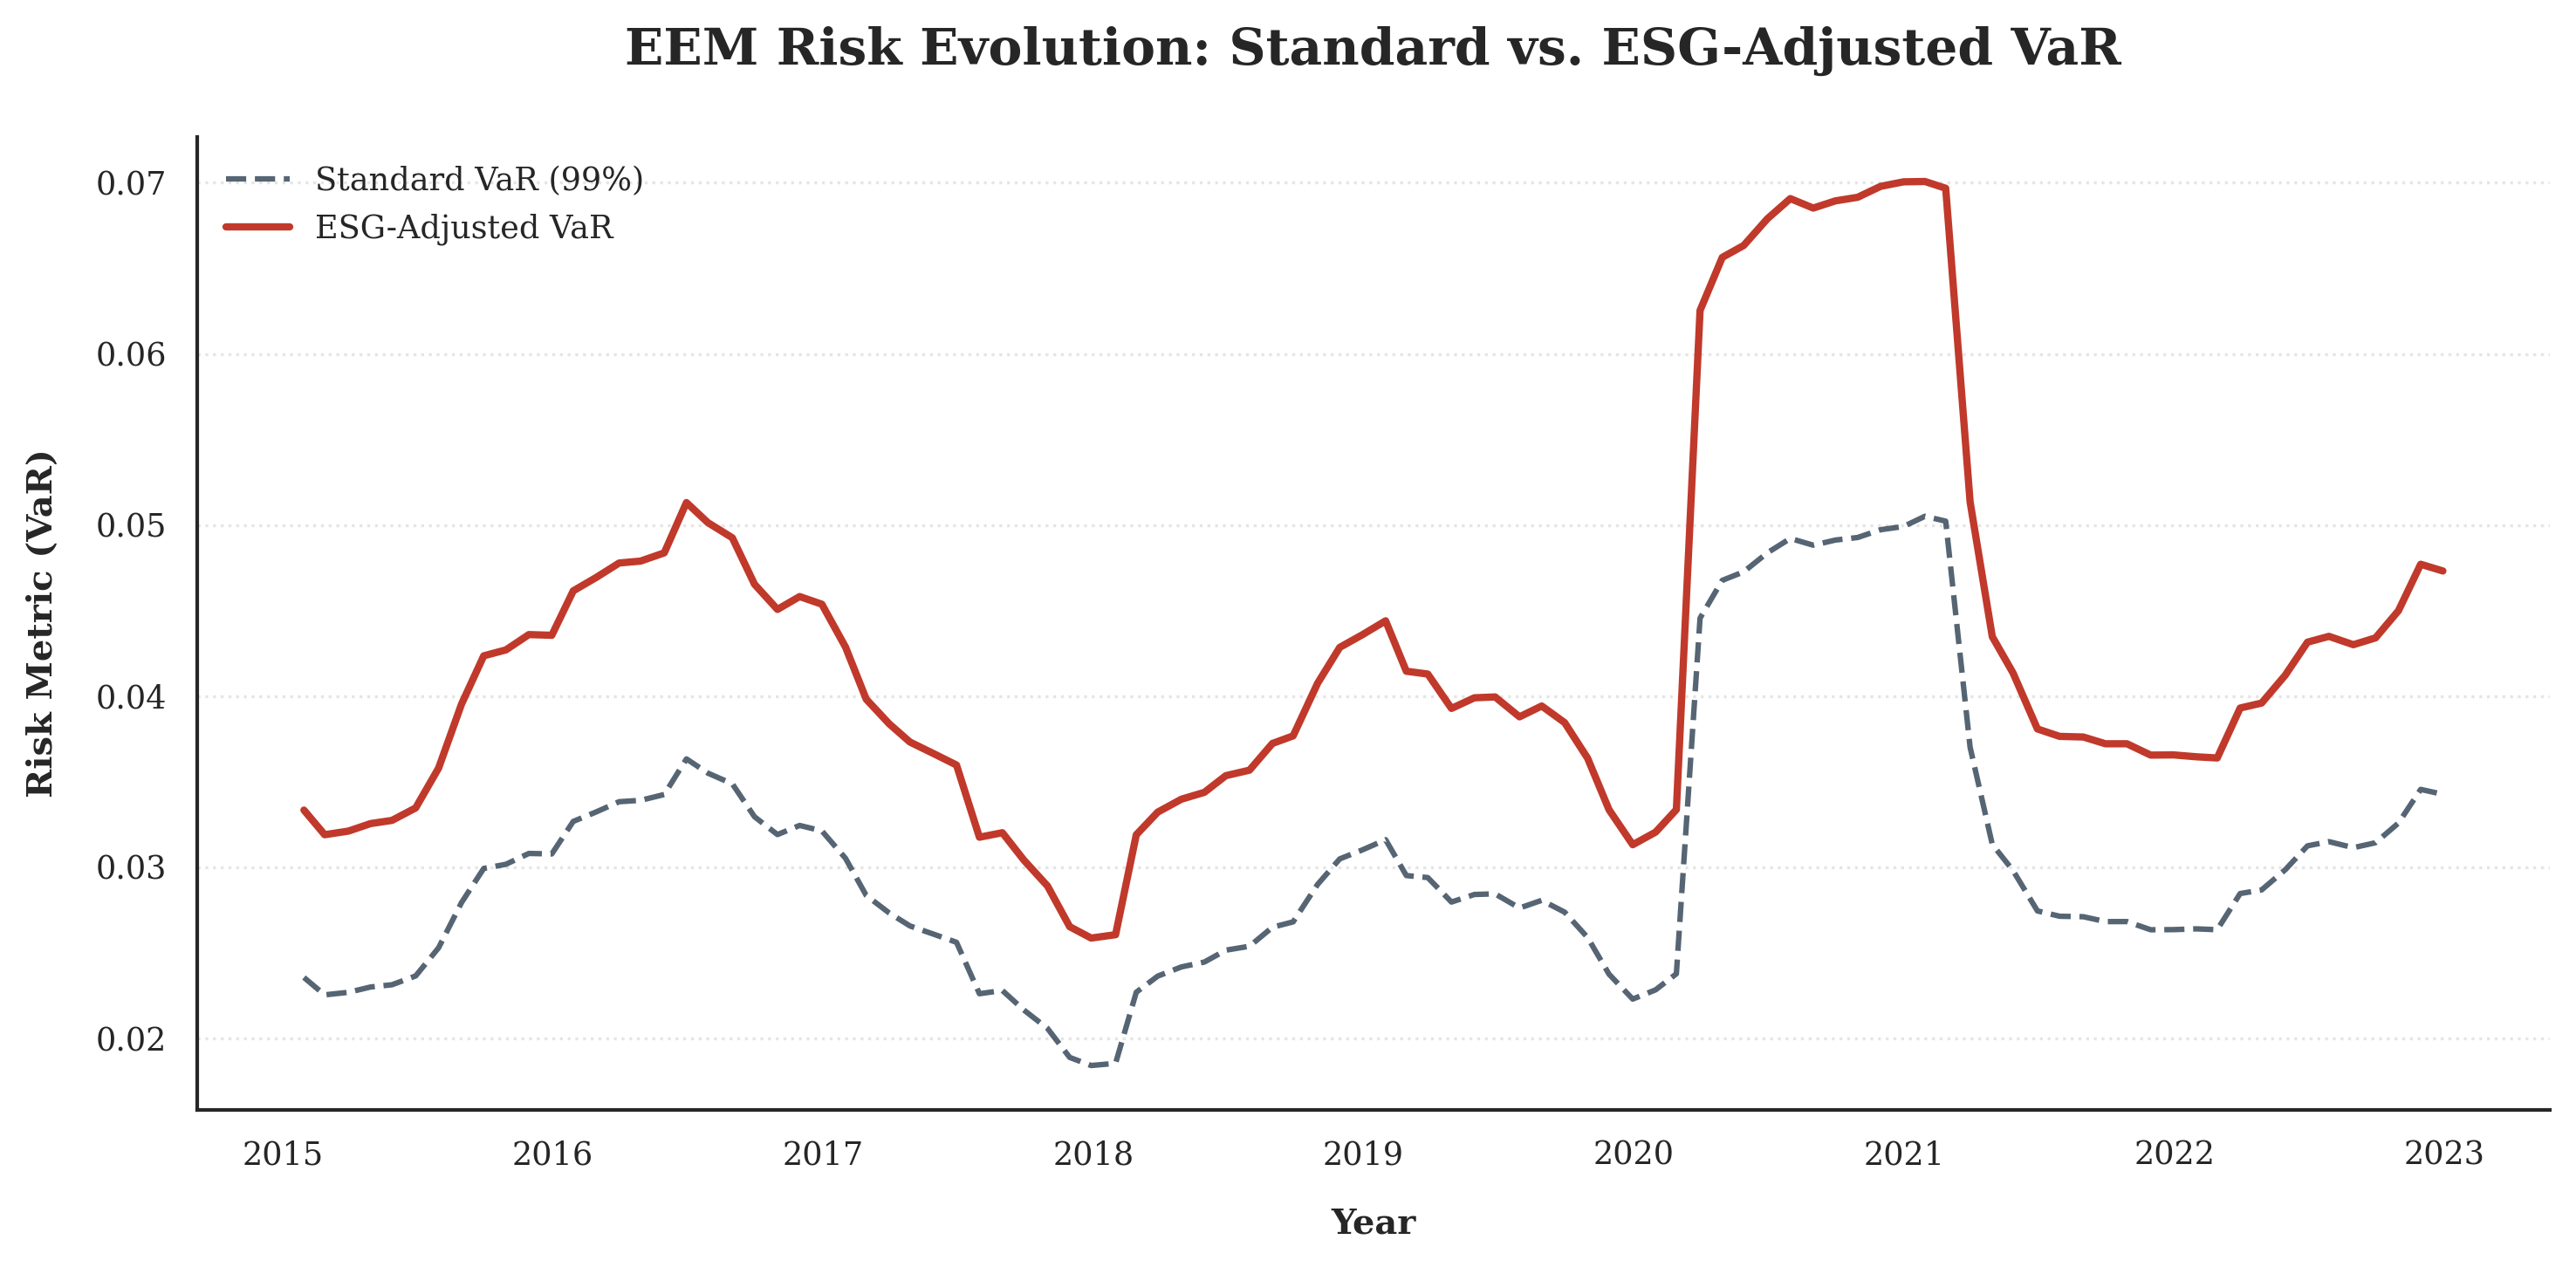

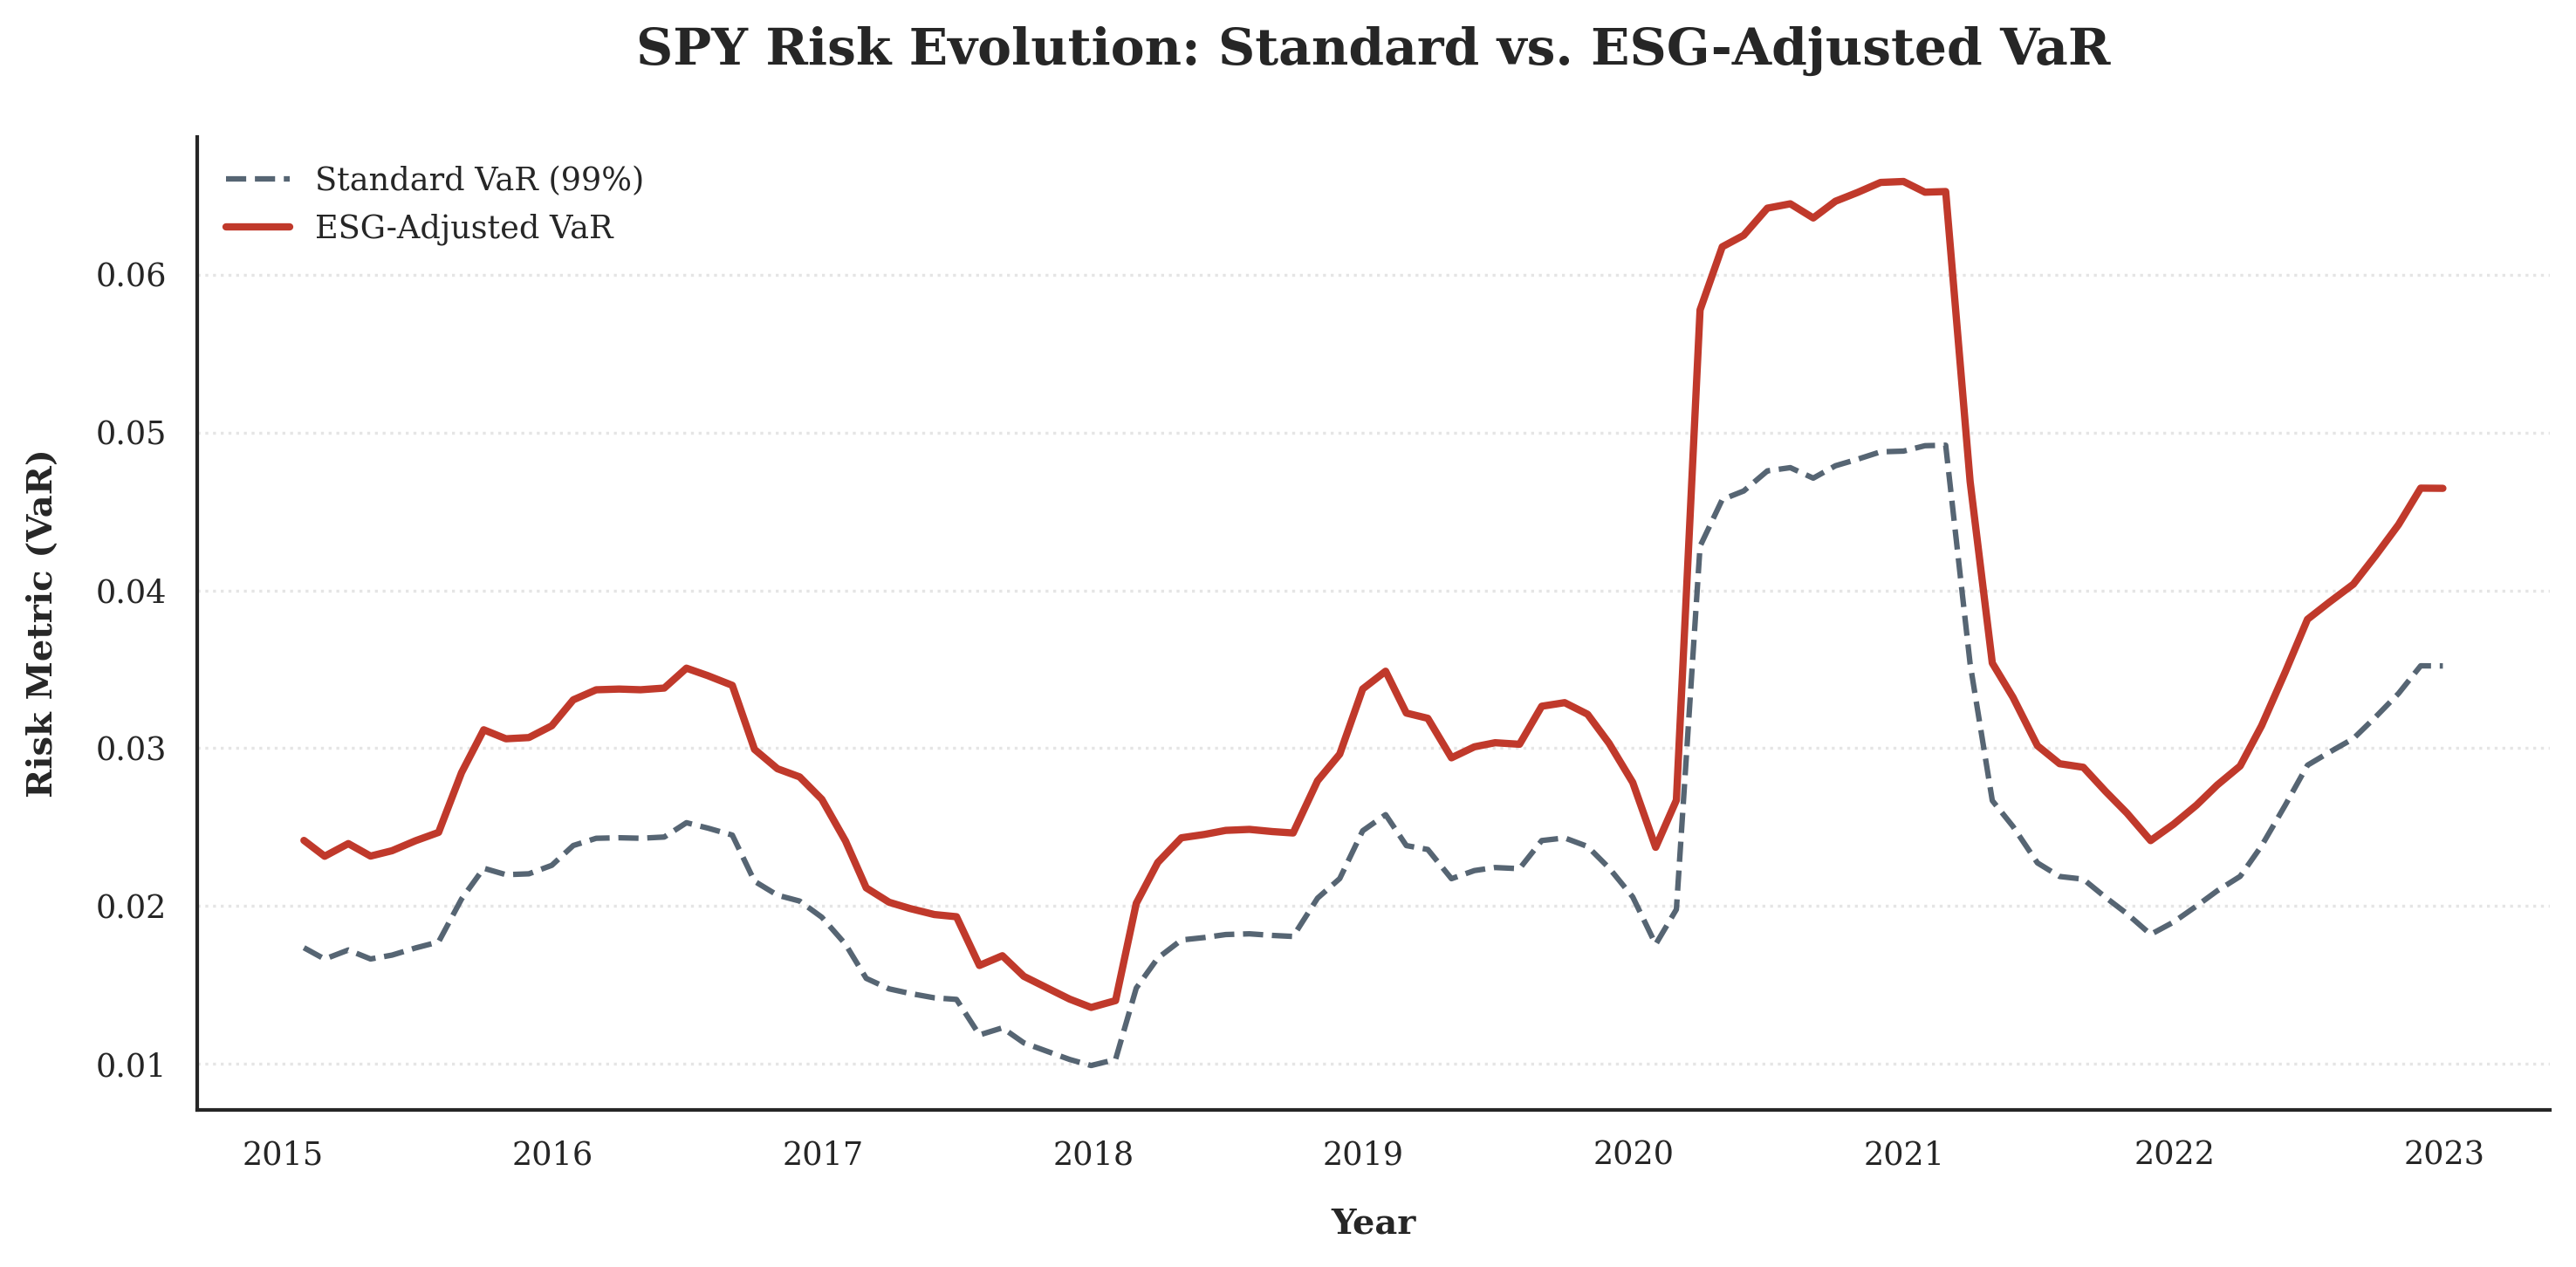

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Global Style Setting (Style Basics) ---
sns.set_theme(style="white", context="paper")
STYLE_CONFIG = {
    "font.family": "serif",
    "font.size": 12,
    "axes.labelweight": "bold",
    "axes.titlesize": 14,
    "figure.dpi": 300
}
plt.rcParams.update(STYLE_CONFIG)

# Unified Color Definition
COLOR_STD = "#2c3e50" # Dark Blue-Gray (Standard VaR)
COLOR_ESG = "#c0392b" # Brick Red (ESG VaR)
EXPECTED_LINE = "black"

# --- 2. Encapsulating Plotting Functions ---

def plot_time_series(df, ticker_name):
    """產出統一風格的 VaR 時間序列折線圖"""
    fig, ax = plt.subplots(figsize=(10, 5))

    # Line chart settings: Standard uses dashed lines, ESG uses thick solid lines
    ax.plot(df["date"], df["VaR_99_daily"],
            label="Standard VaR (99%)",
            color=COLOR_STD, linestyle="--", linewidth=1.5, alpha=0.8)

    ax.plot(df["date"], df["VaRESG_advanced"],
            label="ESG-Adjusted VaR",
            color=COLOR_ESG, linewidth=2)

    ax.set_title(f"{ticker_name} Risk Evolution: Standard vs. ESG-Adjusted VaR",
                 fontsize=14, fontweight="bold", pad=20)
    ax.set_xlabel("Year", labelpad=10)
    ax.set_ylabel("Risk Metric (VaR)", labelpad=10)

    # Enhancement
    ax.legend(frameon=False, loc="upper left")
    ax.grid(axis="y", linestyle=":", alpha=0.5)
    sns.despine()
    plt.tight_layout()
    return fig

def plot_annual_violations(data, ticker_name):
    """Produces a uniform style annual violation bar chart"""
    yearly_data = data.groupby("year")[["var_violations", "varesg_adv_violations"]].sum()

    fig, ax = plt.subplots(figsize=(10, 6))

    yearly_data.plot(kind="bar", ax=ax, width=0.8, edgecolor="black", linewidth=0.6,
                     color=[COLOR_STD, COLOR_ESG], alpha=0.9)

    # Add expected default baseline (1% VaR)
    expected_val = 2.52
    ax.axhline(y=expected_val, color=EXPECTED_LINE, linestyle="--", linewidth=1.2,
               label=f"Expected Violations ({expected_val})", alpha=0.7)

    ax.set_title(f"{ticker_name} Backtesting: Annual Violation Analysis",
                 fontsize=14, fontweight="bold", pad=20)
    ax.set_ylabel("Violation Count", labelpad=10)
    ax.set_xlabel("Year", labelpad=10)

    # Enhancement
    ax.legend(frameon=False, loc="upper left")
    ax.grid(axis="y", linestyle=":", alpha=0.5)
    sns.despine()
    plt.xticks(rotation=0)
    plt.tight_layout()
    return fig

# --- 3. Perform plotting ---

# Plot an EEM line chart
fig1 = plot_time_series(eem_monthly, "EEM")
plt.show()

# Plot an SPY line chart
fig3 = plot_time_series(spy_monthly, "SPY")
# fig4 = plot_annual_violations(spy_compare, "SPY")

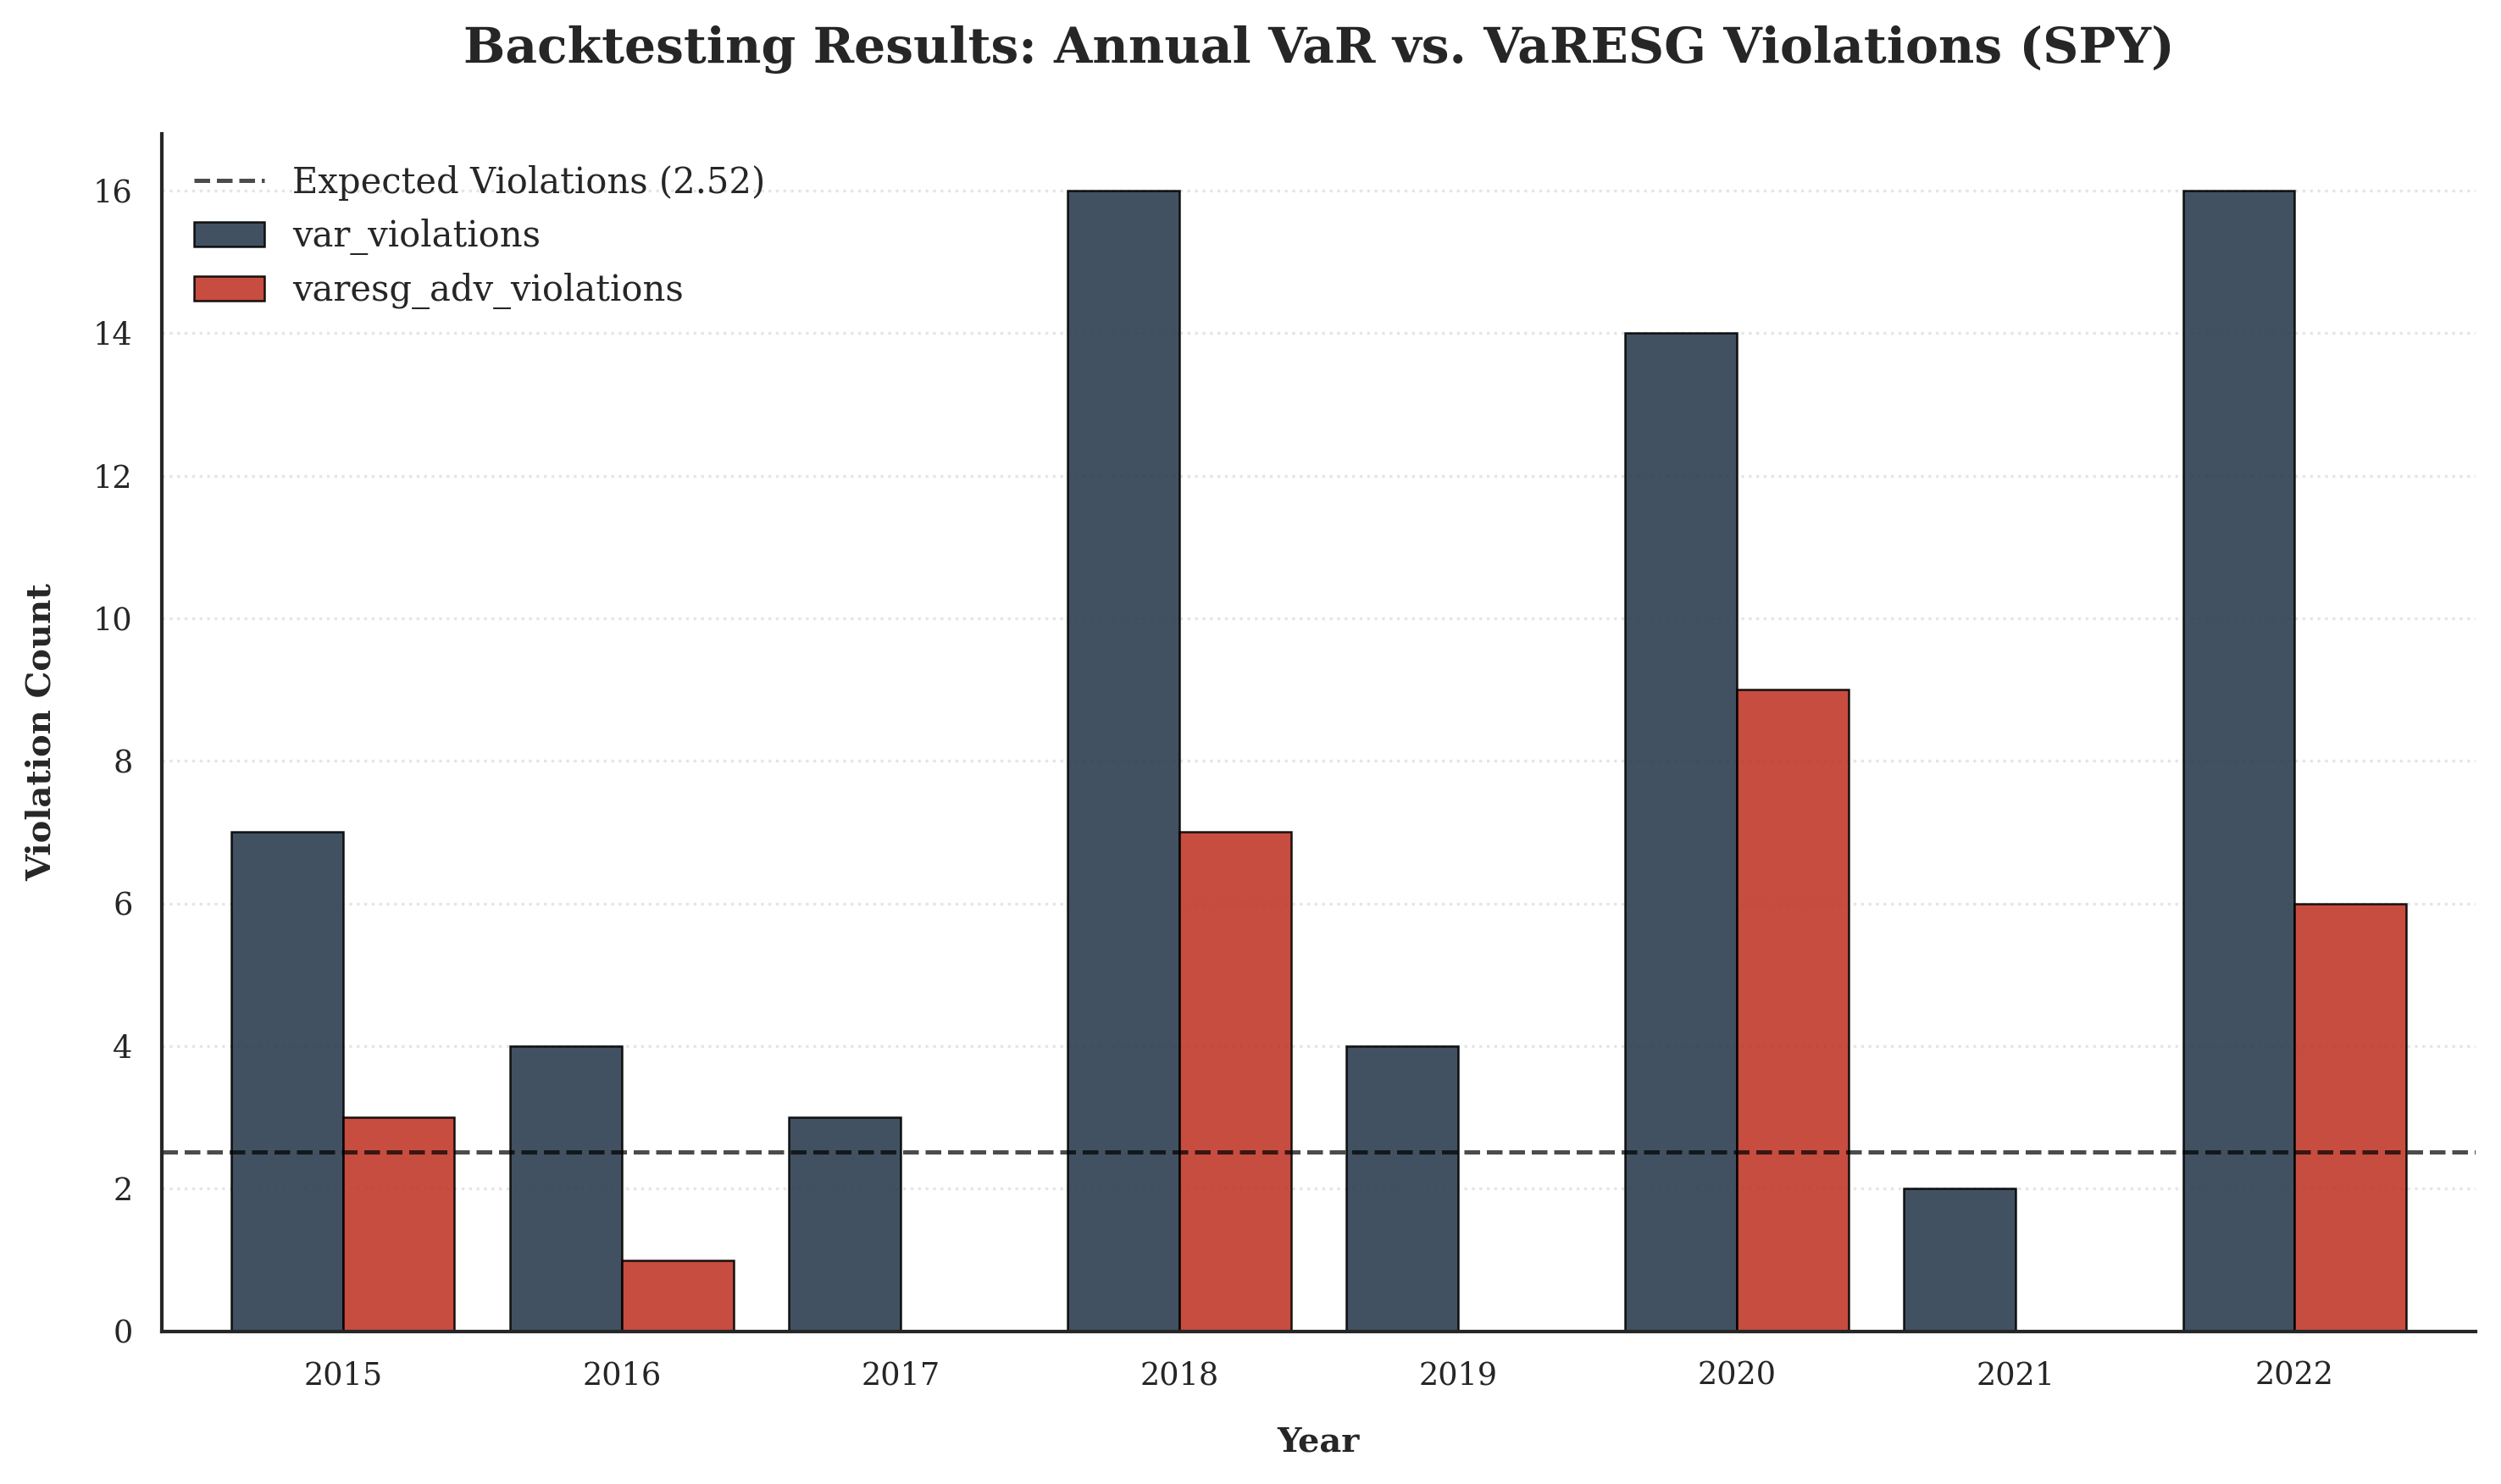

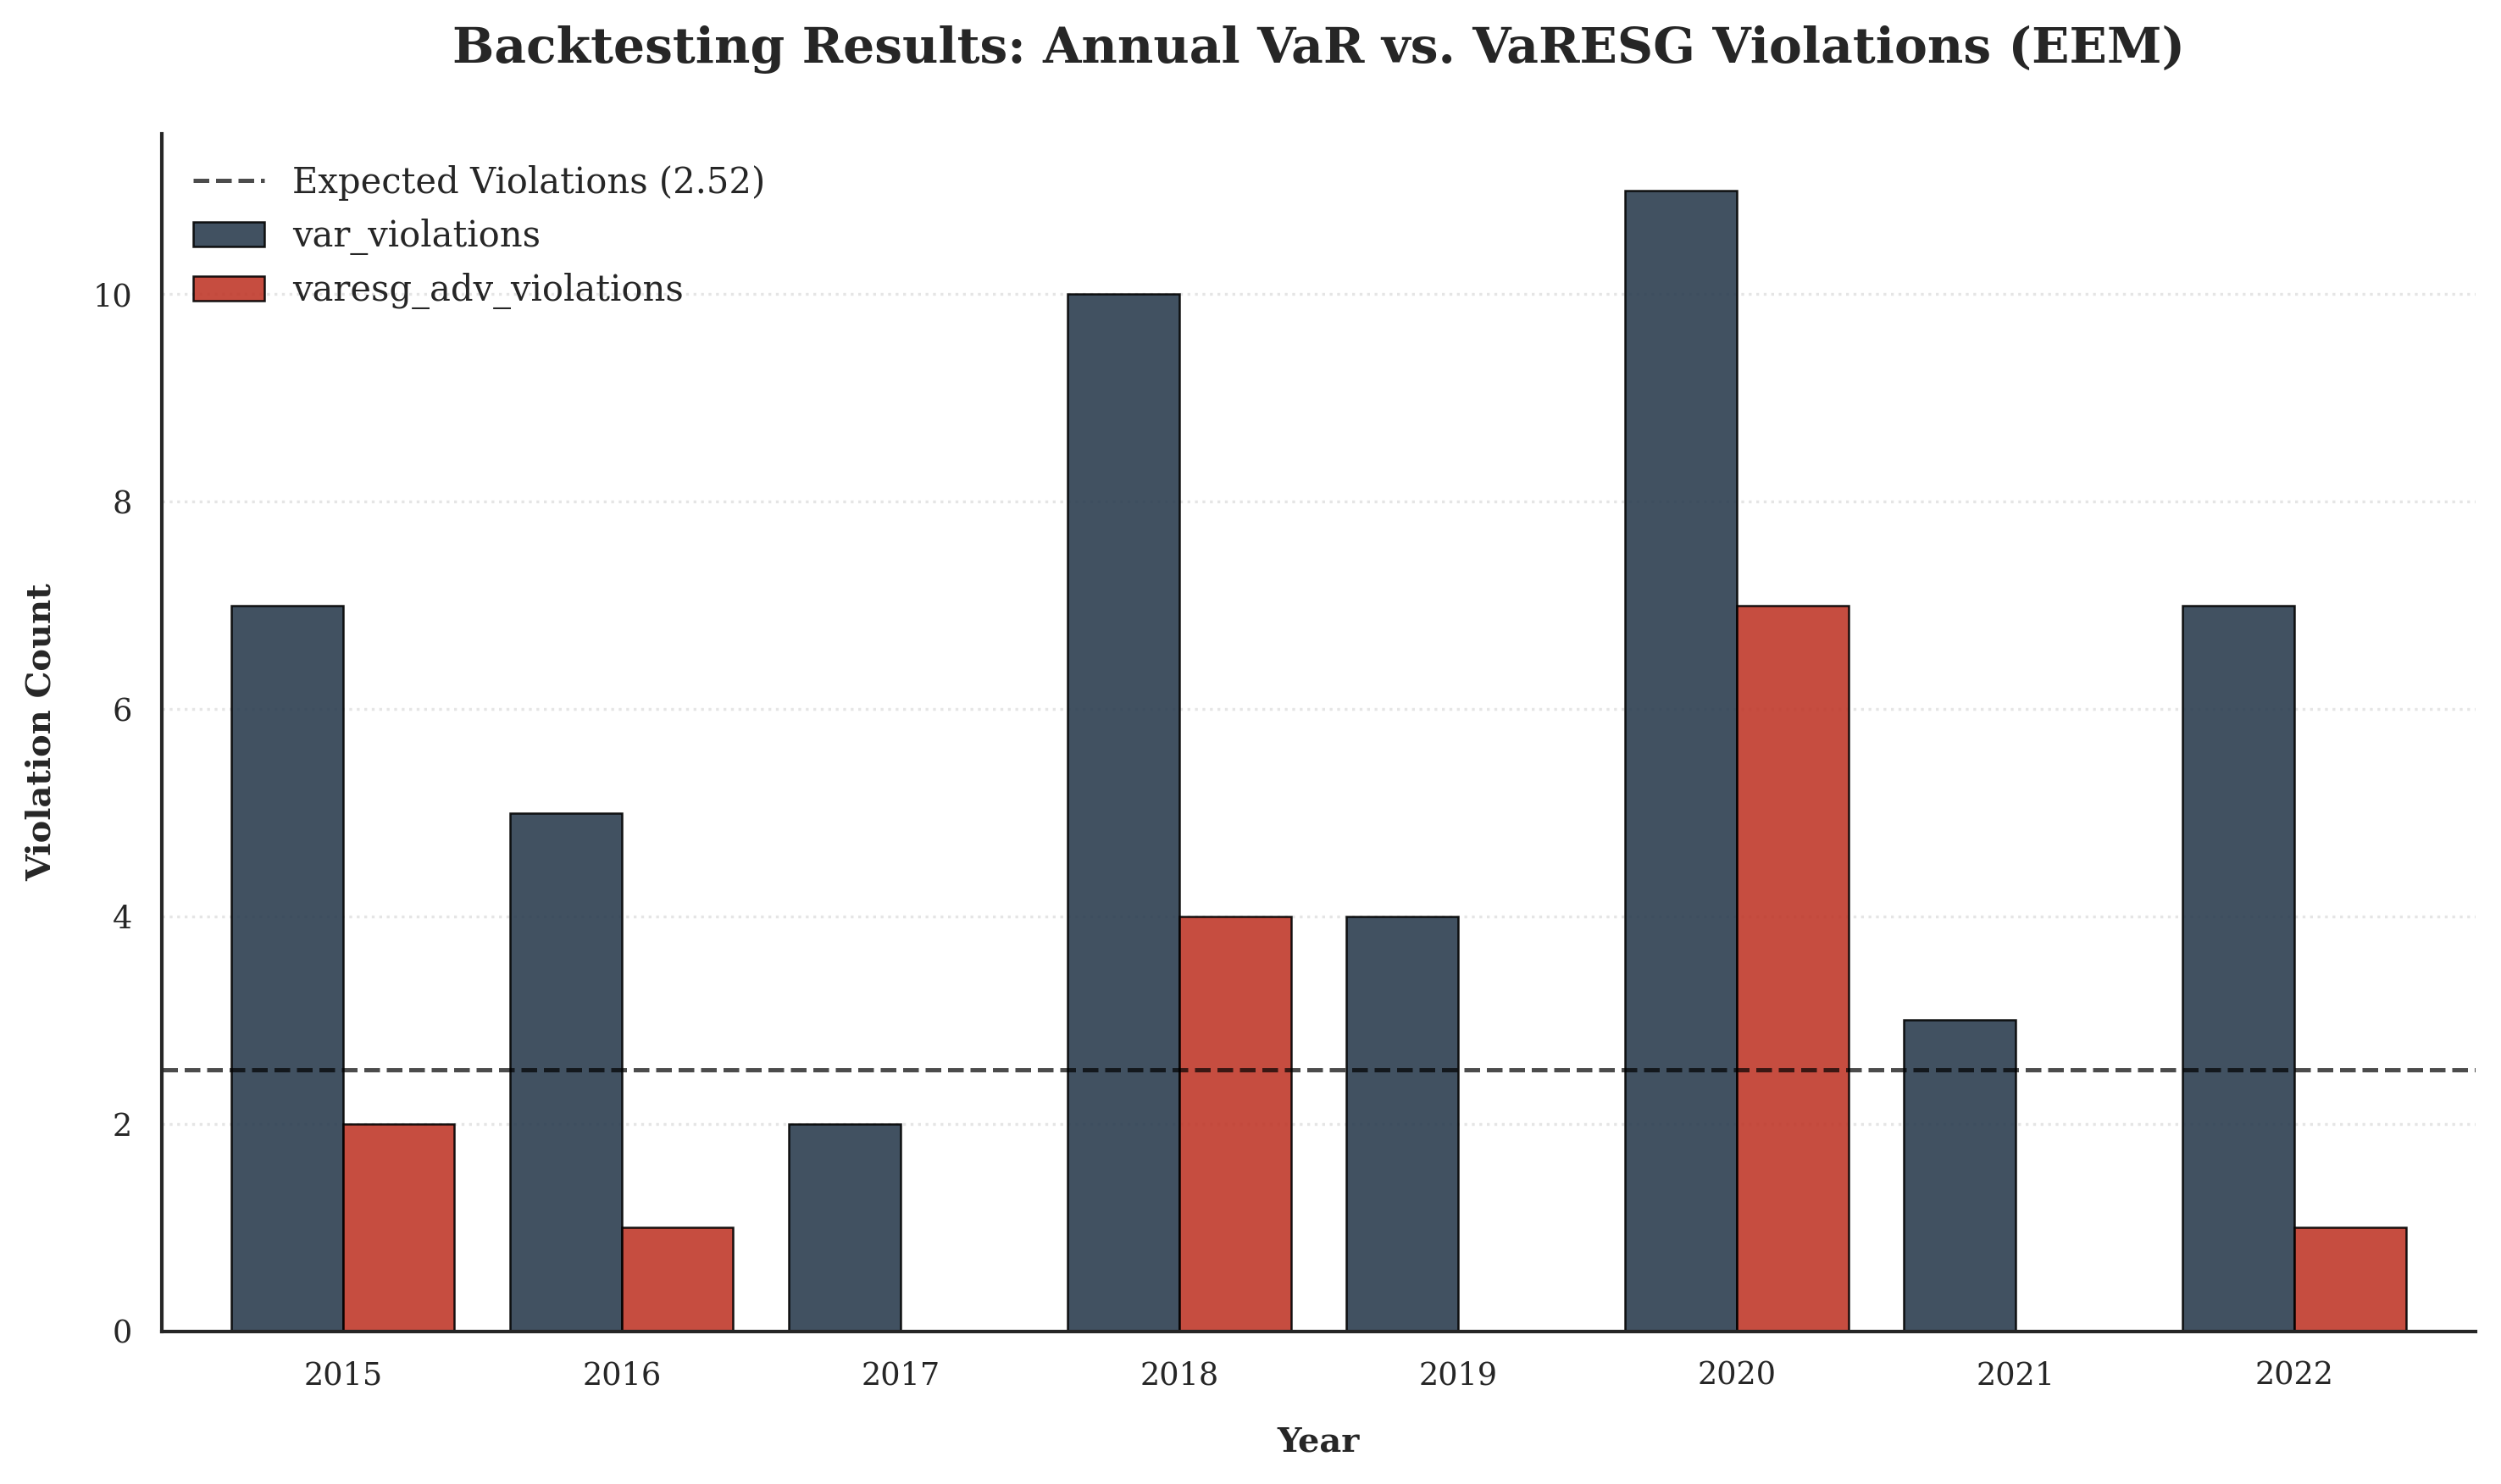

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Global style setting (only needs to be executed once) ---
sns.set_theme(style="white", context="paper")
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.labelweight": "bold",
    "axes.titlesize": 14,
    "figure.dpi": 300
})

def plot_annual_violations(data, ticker_name):
    """
    Generate a uniformly formatted annual backtesting violation count comparison plot
    """

    # Calculate the annual sum
    yearly_data = data.groupby("year")[["var_violations", "varesg_adv_violations"]].sum()

    fig, ax = plt.subplots(figsize=(10, 6))

    # Unified color scheme: Dark blue (Standard) and brick red (ESG)
    colors = ["#2c3e50", "#c0392b"]

    yearly_data.plot(kind="bar",
                     ax=ax,
                     color=colors,
                     width=0.8,
                     edgecolor="black",
                     linewidth=0.6,
                     alpha=0.9)

    # 4. Unified baseline (1% VaR expected number of defaults)
    expected_val = 2.52
    ax.axhline(y=expected_val, color="black", linestyle="--", linewidth=1.2,
               label=f"Expected Violations ({expected_val})", alpha=0.7)

    # 5. Unified label and title format
    ax.set_title(f"Backtesting Results: Annual VaR vs. VaRESG Violations ({ticker_name})",
                 fontsize=14, fontweight="bold", pad=20)
    ax.set_ylabel("Violation Count", labelpad=10)
    ax.set_xlabel("Year", labelpad=10)

    # 6. Unify detail rendering
    ax.legend(frameon=False, loc="upper left", fontsize=10)
    ax.grid(axis="y", linestyle=":", alpha=0.5)
    sns.despine() # Remove top and right borders

    plt.xticks(rotation=0)
    plt.tight_layout()

    return fig

# --- 2. Generate charts separately ---

# Generate SPY chart
fig_spy = plot_annual_violations(spy_compare, "SPY")
plt.show()

# Generate EEM chart
fig_eem = plot_annual_violations(eem_compare, "EEM")
plt.show()

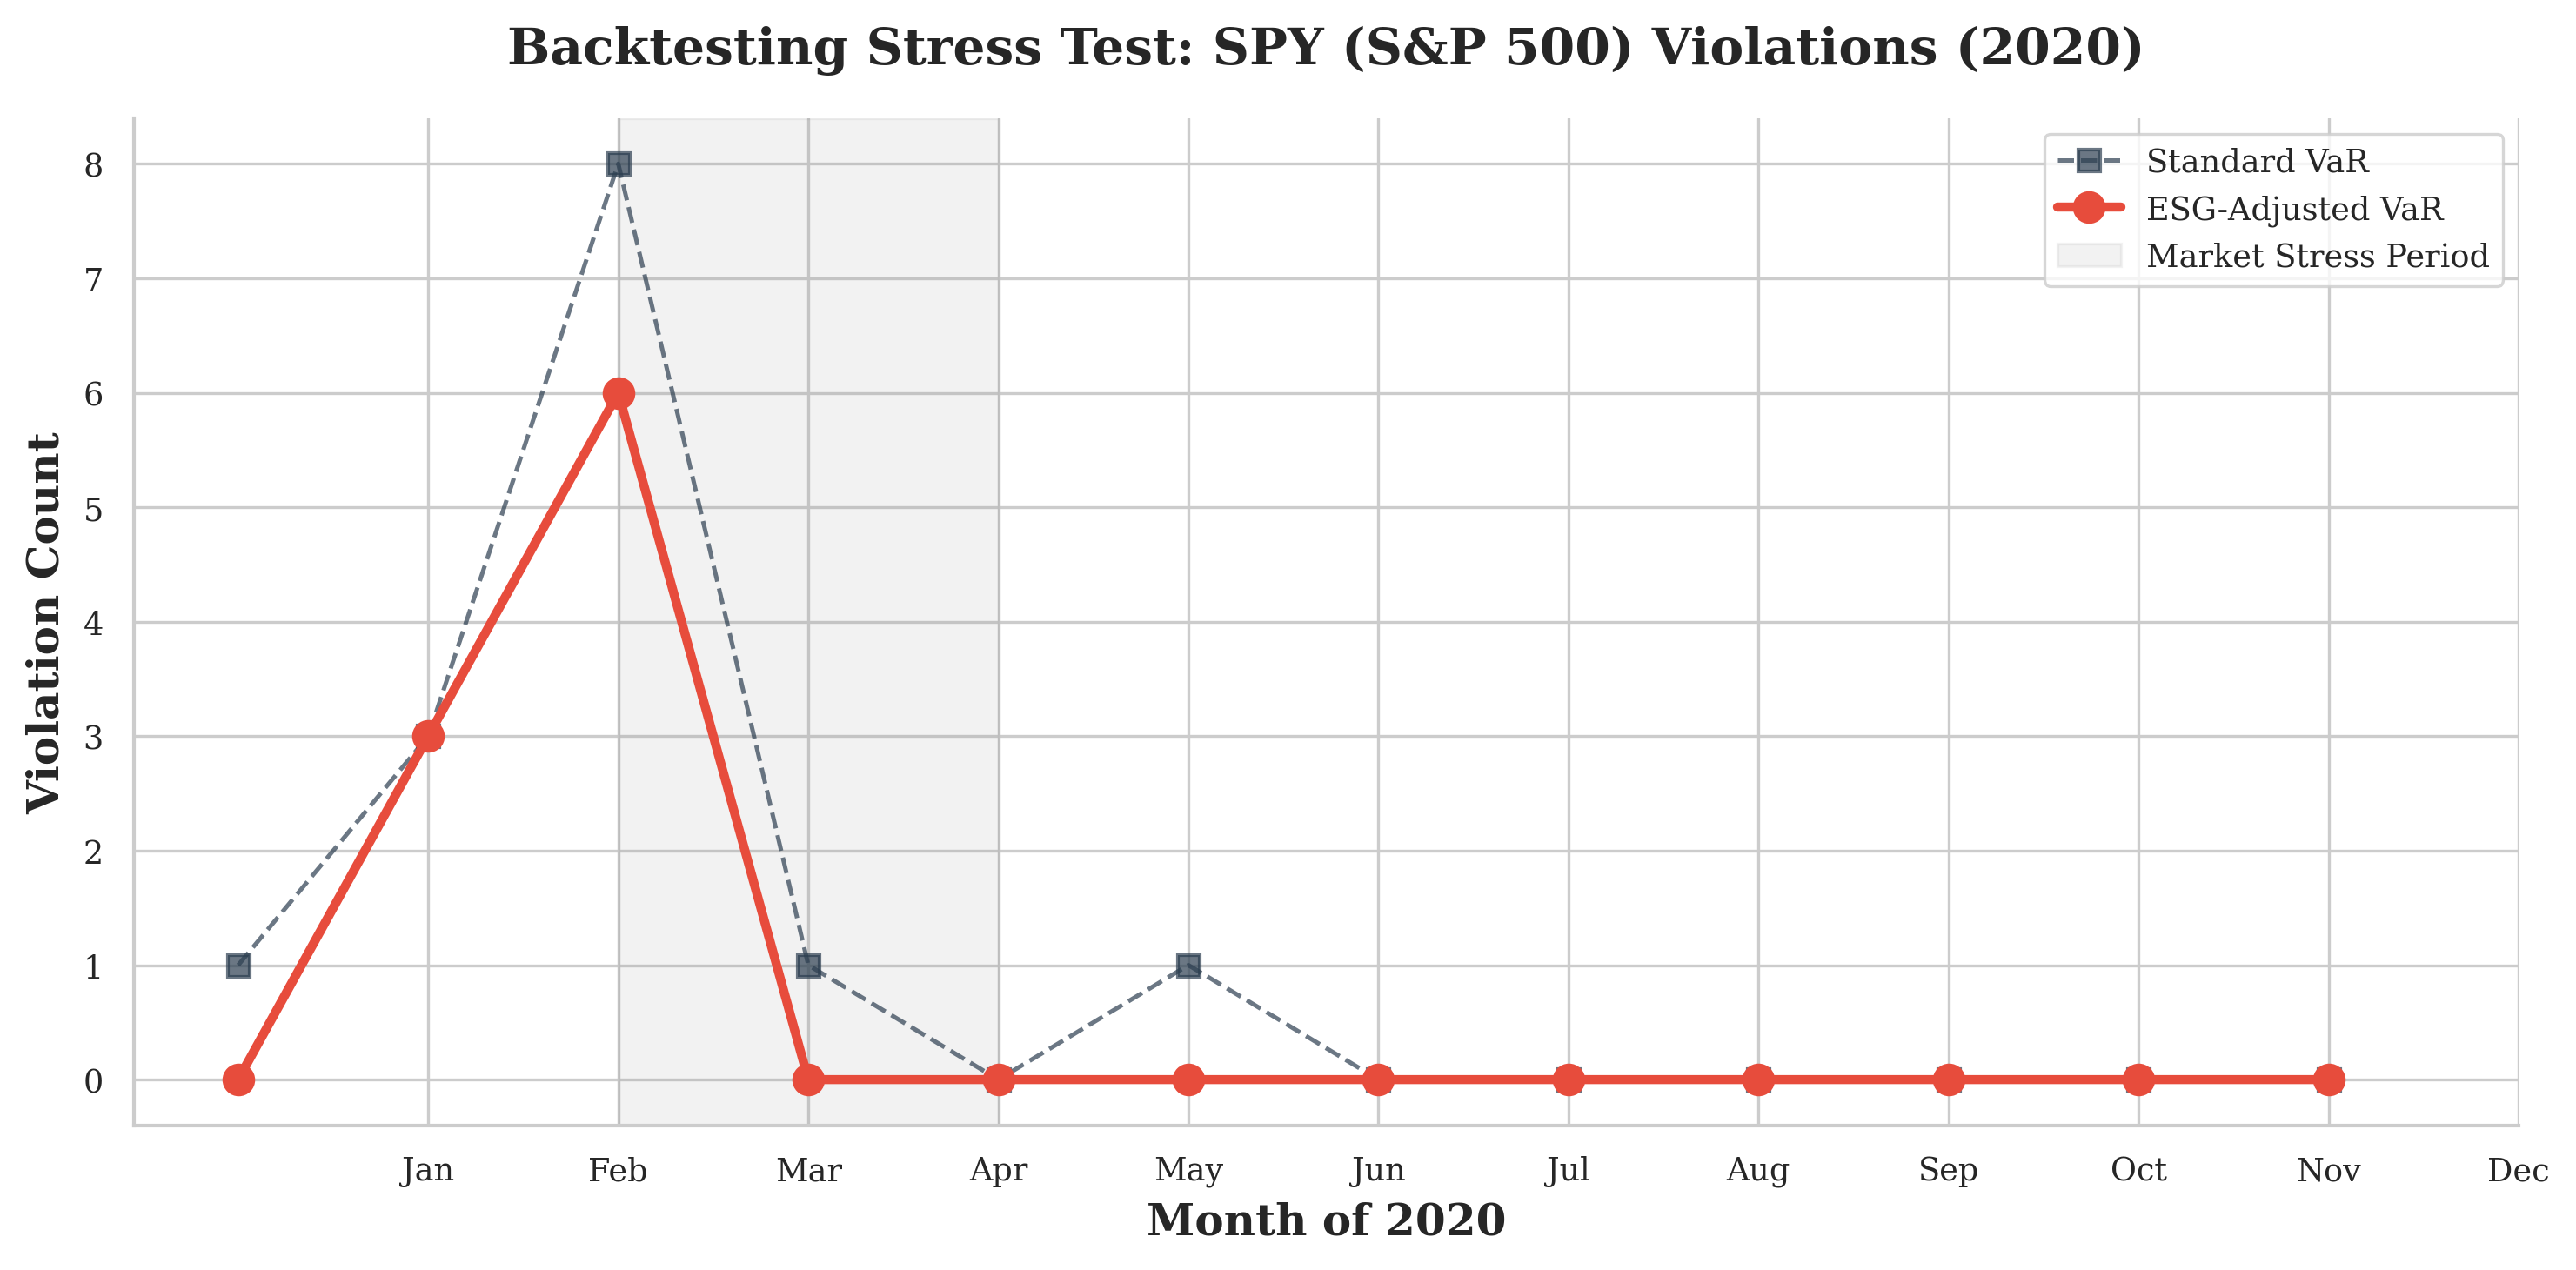

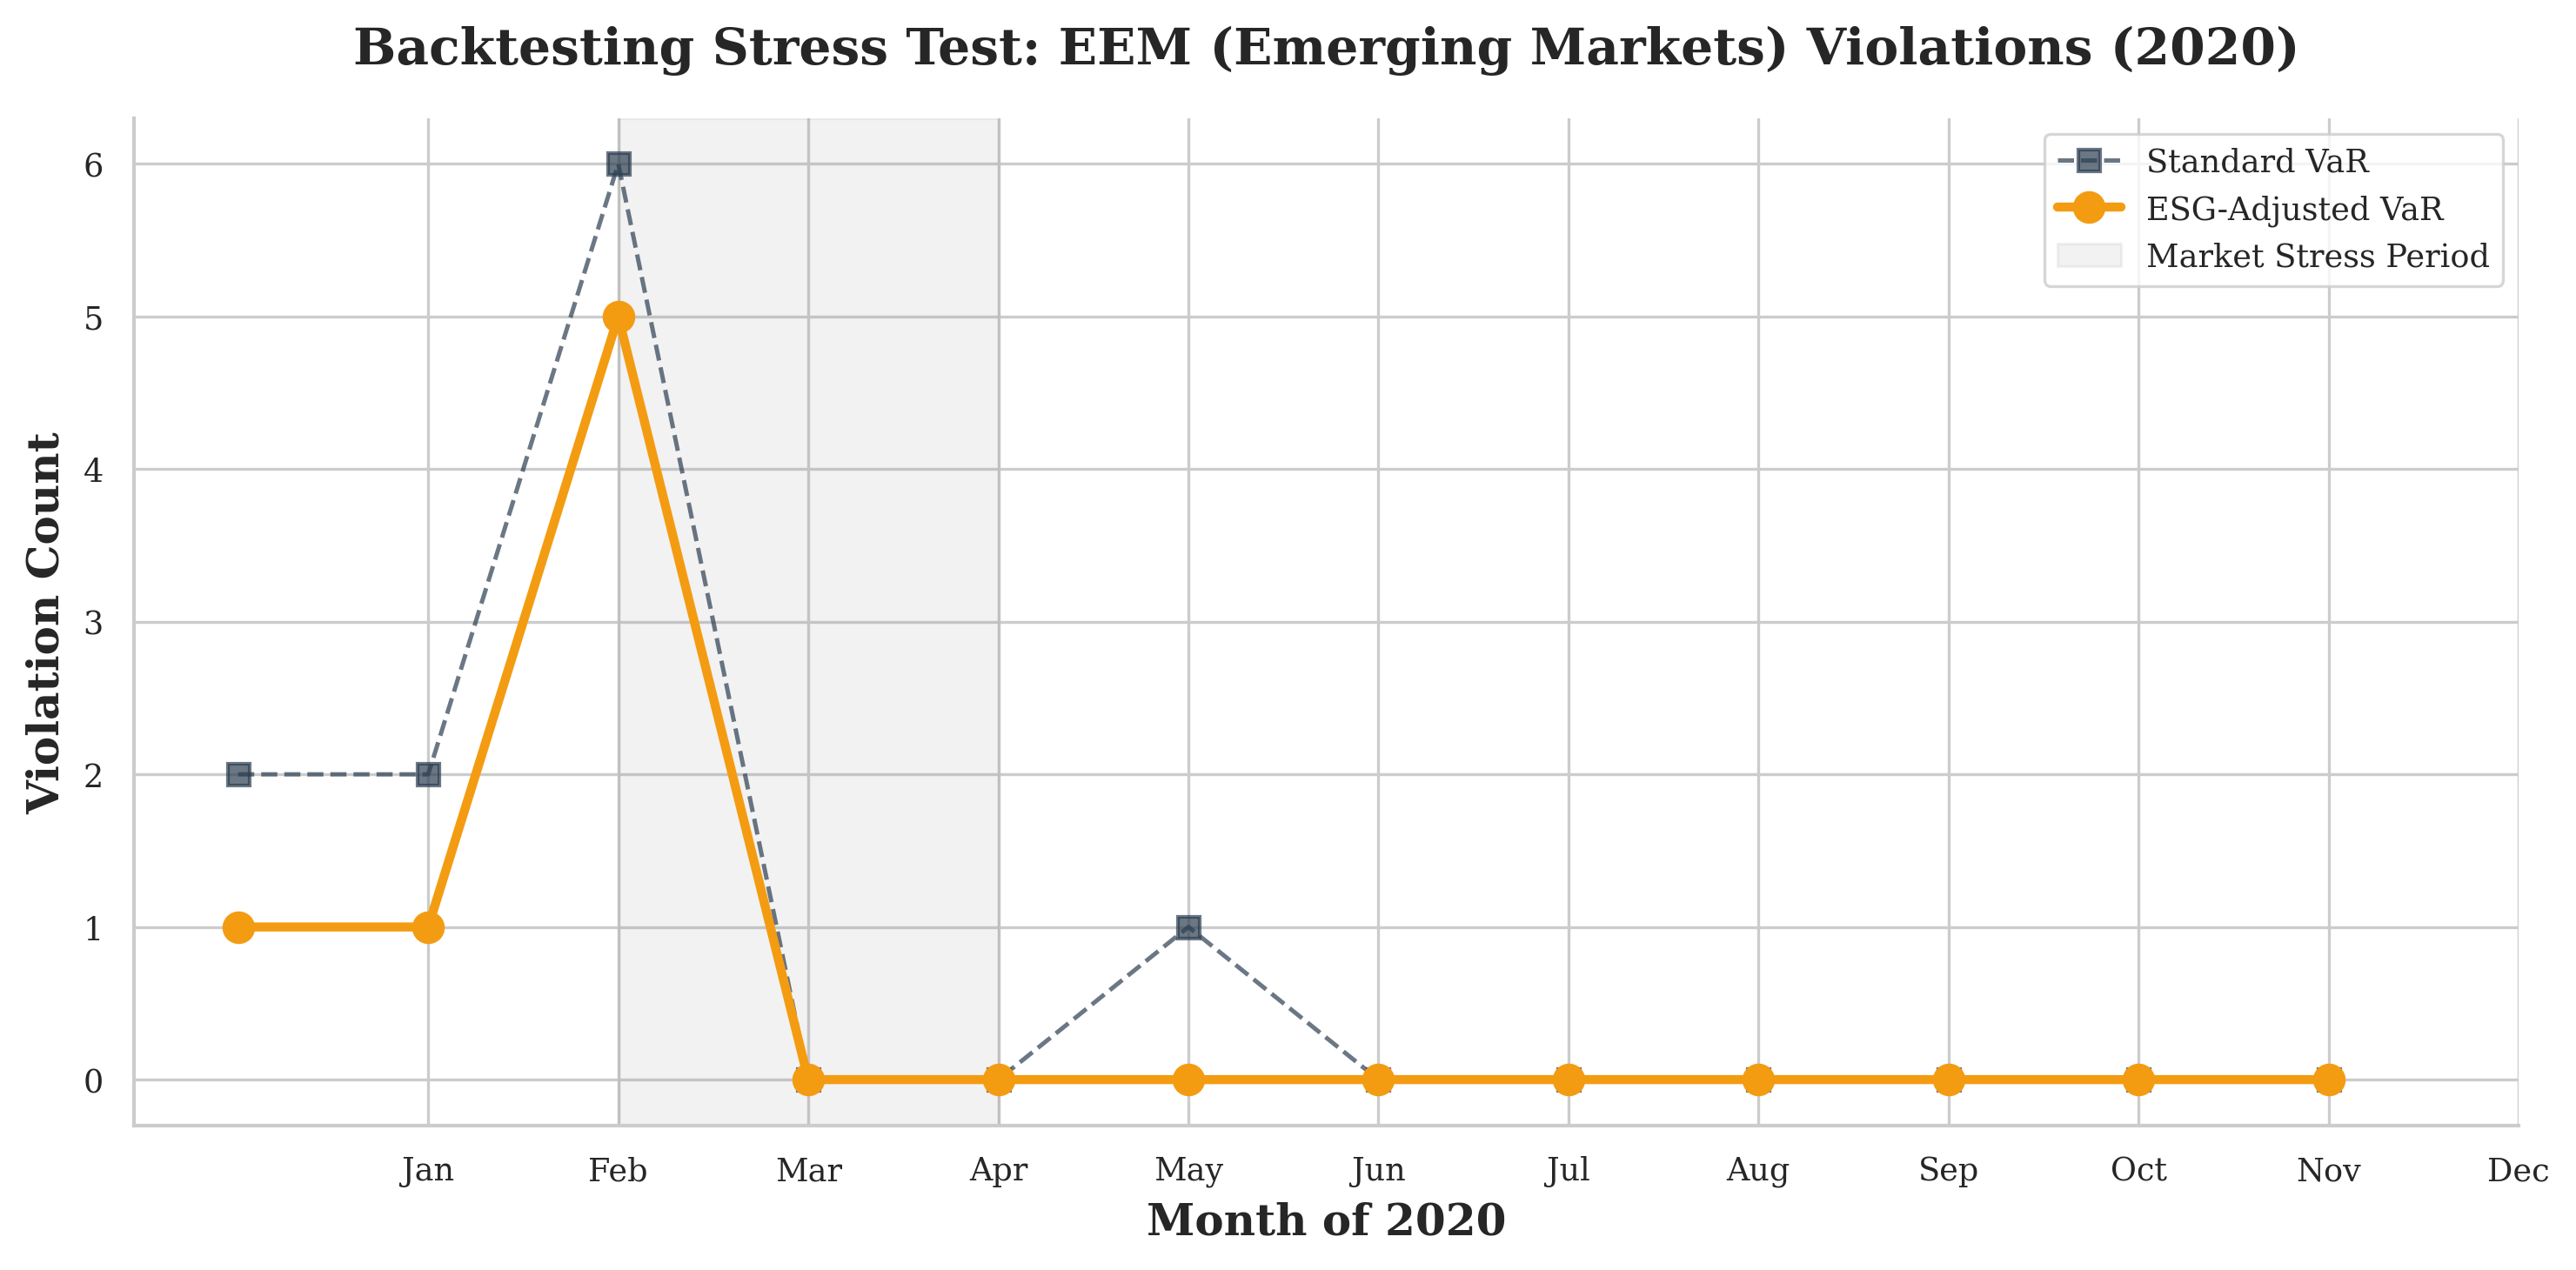

In [ ]:
spy_2020 = spy_compare[spy_compare["year"] == 2020]
eem_2020 = eem_compare[eem_compare["year"] == 2020]

import matplotlib.pyplot as plt
import seaborn as sns

# 1. Global Academic Styling
sns.set_theme(style="whitegrid", context="paper")
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.labelsize": 12
})

def plot_covid_violations(data, ticker_name, color_palette):
    """Function to generate a publication-quality violation plot."""
    fig, ax = plt.subplots(figsize=(10, 5), dpi=300)

    # Plot lines with markers
    ax.plot(data["actual_month"], data["var_violations"],
            marker="s", markersize=6, label="Standard VaR",
            linestyle="--", color="#2c3e50", alpha=0.7)

    ax.plot(data["actual_month"], data["varesg_adv_violations"],
            marker="o", markersize=8, label="ESG-Adjusted VaR",
            linewidth=2.5, color=color_palette)

    # Highlight the COVID Crash Period (March 2020)
    ax.axvspan(2, 4, color='gray', alpha=0.1, label="Market Stress Period")

    # Titles and Labels
    ax.set_title(f"Backtesting Stress Test: {ticker_name} Violations (2020)", pad=15, fontweight="bold")
    ax.set_ylabel("Violation Count")
    ax.set_xlabel("Month of 2020")

    # Customizing x-axis to show months clearly
    month_labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(month_labels)

    # Legend and Spines
    ax.legend(frameon=True, loc="upper right")
    sns.despine()

    plt.tight_layout()
    return fig

# --- Generate SPY Plot ---
fig_spy = plot_covid_violations(spy_2020, "SPY (S&P 500)", "#e74c3c")
plt.show()

# --- Generate EEM Plot ---
fig_eem = plot_covid_violations(eem_2020, "EEM (Emerging Markets)", "#f39c12")
plt.show()

In [ ]:
spy_2022 = spy_compare[spy_compare["year"] == 2022].copy()
eem_2022 = eem_compare[eem_compare["year"] == 2022].copy()

print("SPY 2022 preview:")
print(spy_2022[[
    "actual_month", "var_violations", "varesg_adv_violations",
    "realised_avg_shortfall_var", "realised_avg_shortfall_varesg_adv"
]])

print("\nEEM 2022 preview:")
print(eem_2022[[
    "actual_month", "var_violations", "varesg_adv_violations",
    "realised_avg_shortfall_var", "realised_avg_shortfall_varesg_adv"
]])

SPY 2022 preview:
   actual_month  var_violations  varesg_adv_violations  \
84      2022-01               2                      0   
85      2022-02               2                      0   
86      2022-03               1                      1   
87      2022-04               3                      1   
88      2022-05               3                      2   
89      2022-06               3                      1   
90      2022-07               0                      0   
91      2022-08               1                      0   
92      2022-09               1                      1   
93      2022-10               0                      0   
94      2022-11               0                      0   
95      2022-12               0                      0   

    realised_avg_shortfall_var  realised_avg_shortfall_varesg_adv  
84                    0.000210                           0.000000  
85                    0.002323                           0.000000  
86                    0

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="paper")
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.labelsize": 12
})

def plot_stress_violations(data, ticker_name, year_label, color_palette, shade_start=None, shade_end=None):
    fig, ax = plt.subplots(figsize=(10, 5), dpi=300)

    # The x-axis is first converted to 1~12
    x = list(range(1, len(data) + 1))

    ax.plot(
        x, data["var_violations"],
        marker="s", markersize=6,
        label="Standard VaR",
        linestyle="--", color="#2c3e50", alpha=0.8
    )

    ax.plot(
        x, data["varesg_adv_violations"],
        marker="o", markersize=7,
        label="ESG-Adjusted VaR",
        linewidth=2.5, color=color_palette
    )

    # Optional shading
    if shade_start is not None and shade_end is not None:
        ax.axvspan(shade_start, shade_end, color="gray", alpha=0.10, label="Stress window")

    ax.set_title(f"{ticker_name}: Violation Comparison ({year_label})", pad=15, fontweight="bold")
    ax.set_ylabel("Violation Count")
    ax.set_xlabel(f"Month of {year_label}")

    month_labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(month_labels)

    ax.legend(frameon=True, loc="upper right")
    sns.despine()
    plt.tight_layout()

    return fig

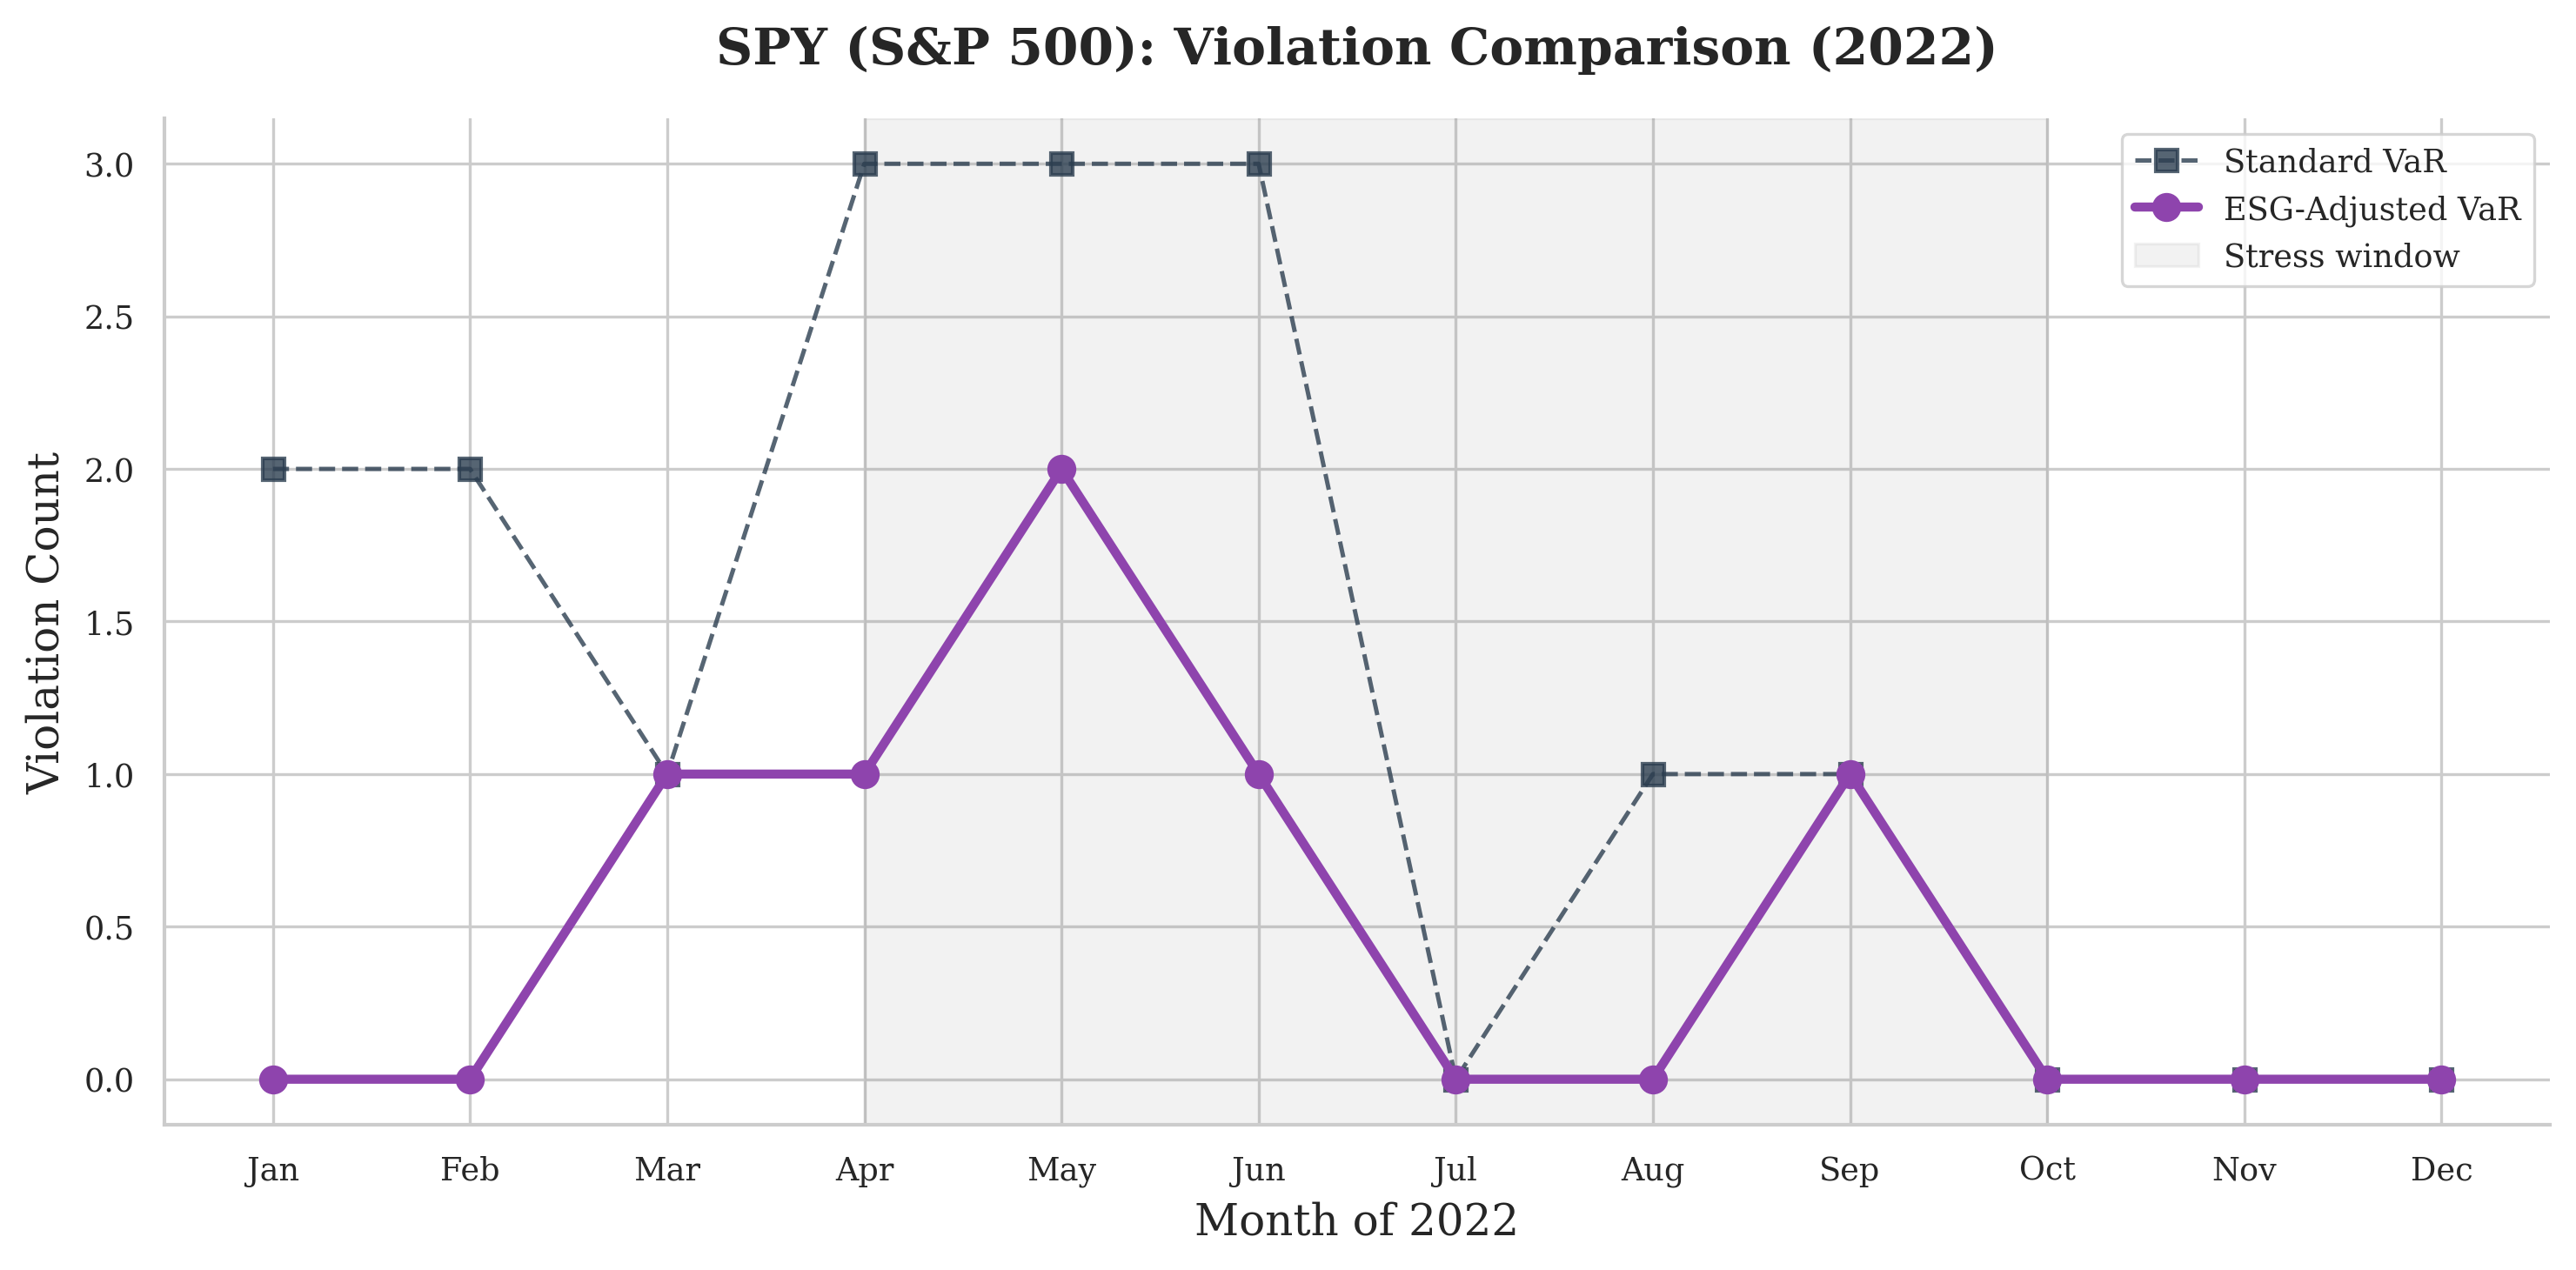

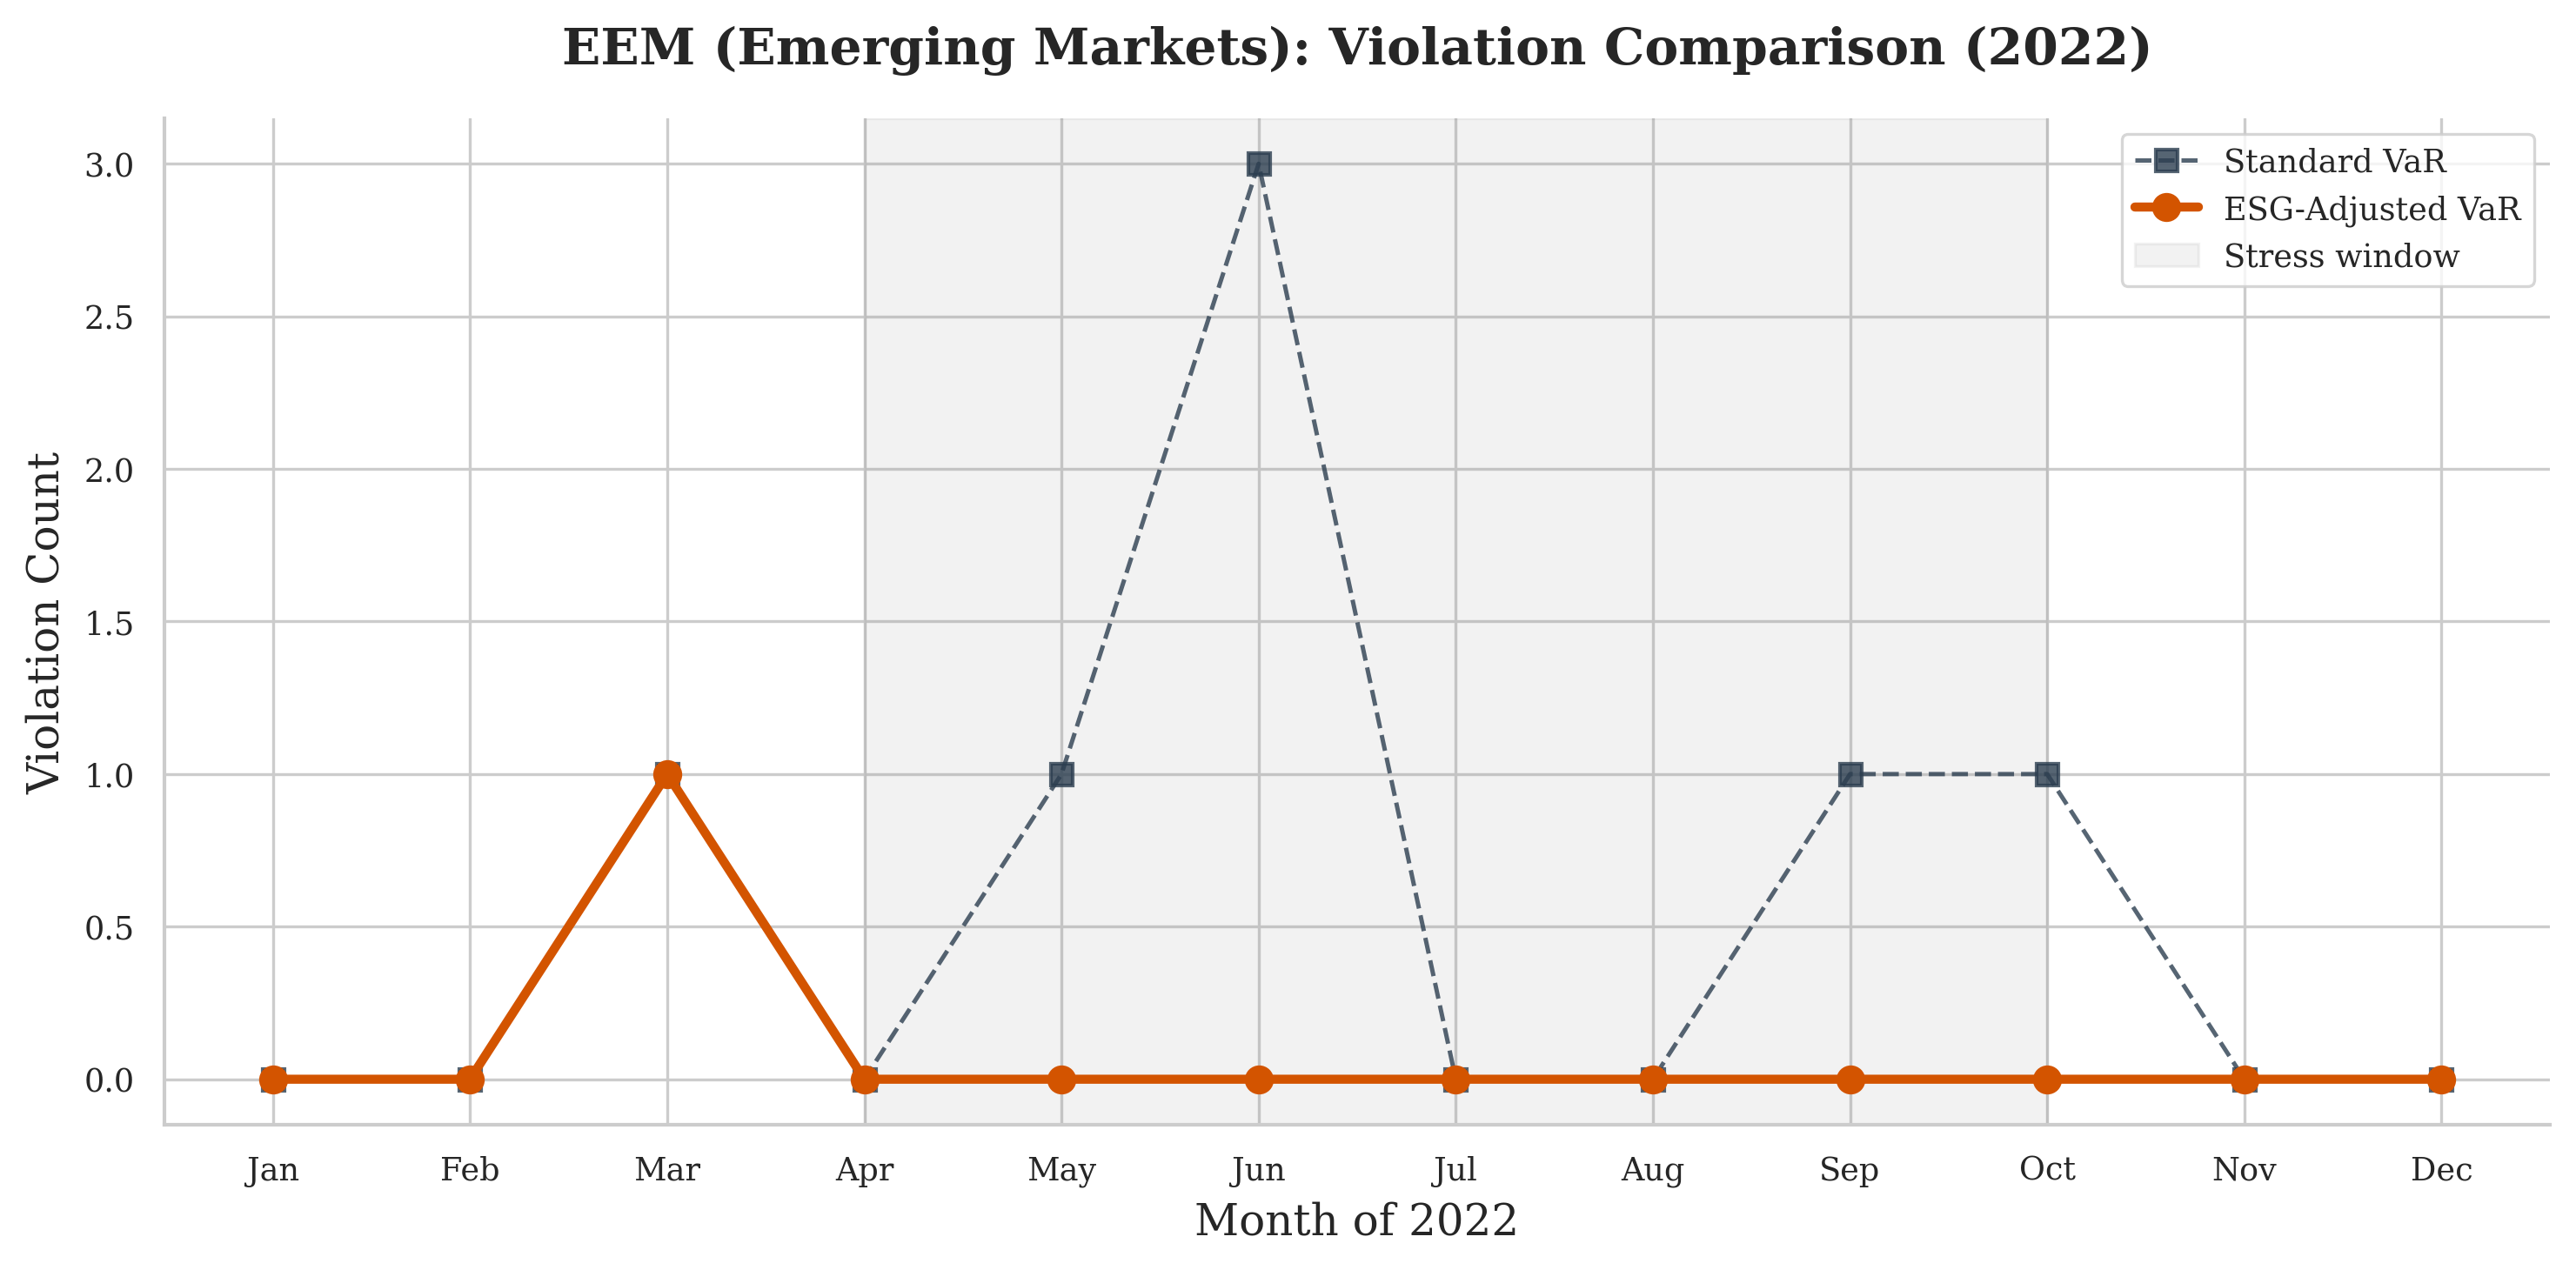

In [ ]:
# SPY 2022
fig_spy_2022 = plot_stress_violations(
    spy_2022, "SPY (S&P 500)", 2022, "#8e44ad",
    shade_start=4, shade_end=10
)
plt.show()

# EEM 2022
fig_eem_2022 = plot_stress_violations(
    eem_2022, "EEM (Emerging Markets)", 2022, "#d35400",
    shade_start=4, shade_end=10
)
plt.show()

In [ ]:
VIS_DIR = "/content/drive/MyDrive/Colab Notebooks/Data Analytics/group project/visualization"

fig_spy_2022.savefig(f"{VIS_DIR}/Figure4_Downturn_2022_SPY.png", dpi=300, bbox_inches="tight")
fig_eem_2022.savefig(f"{VIS_DIR}/Figure5_Downturn_2022_EEM.png", dpi=300, bbox_inches="tight")

print(f"Saved: {VIS_DIR}/Figure4_Downturn_2022_SPY.png")
print(f"Saved: {VIS_DIR}/Figure5_Downturn_2022_EEM.png")

Saved: /content/drive/MyDrive/Colab Notebooks/Data Analytics/group project/visualization/Figure4_Downturn_2022_SPY.png
Saved: /content/drive/MyDrive/Colab Notebooks/Data Analytics/group project/visualization/Figure5_Downturn_2022_EEM.png


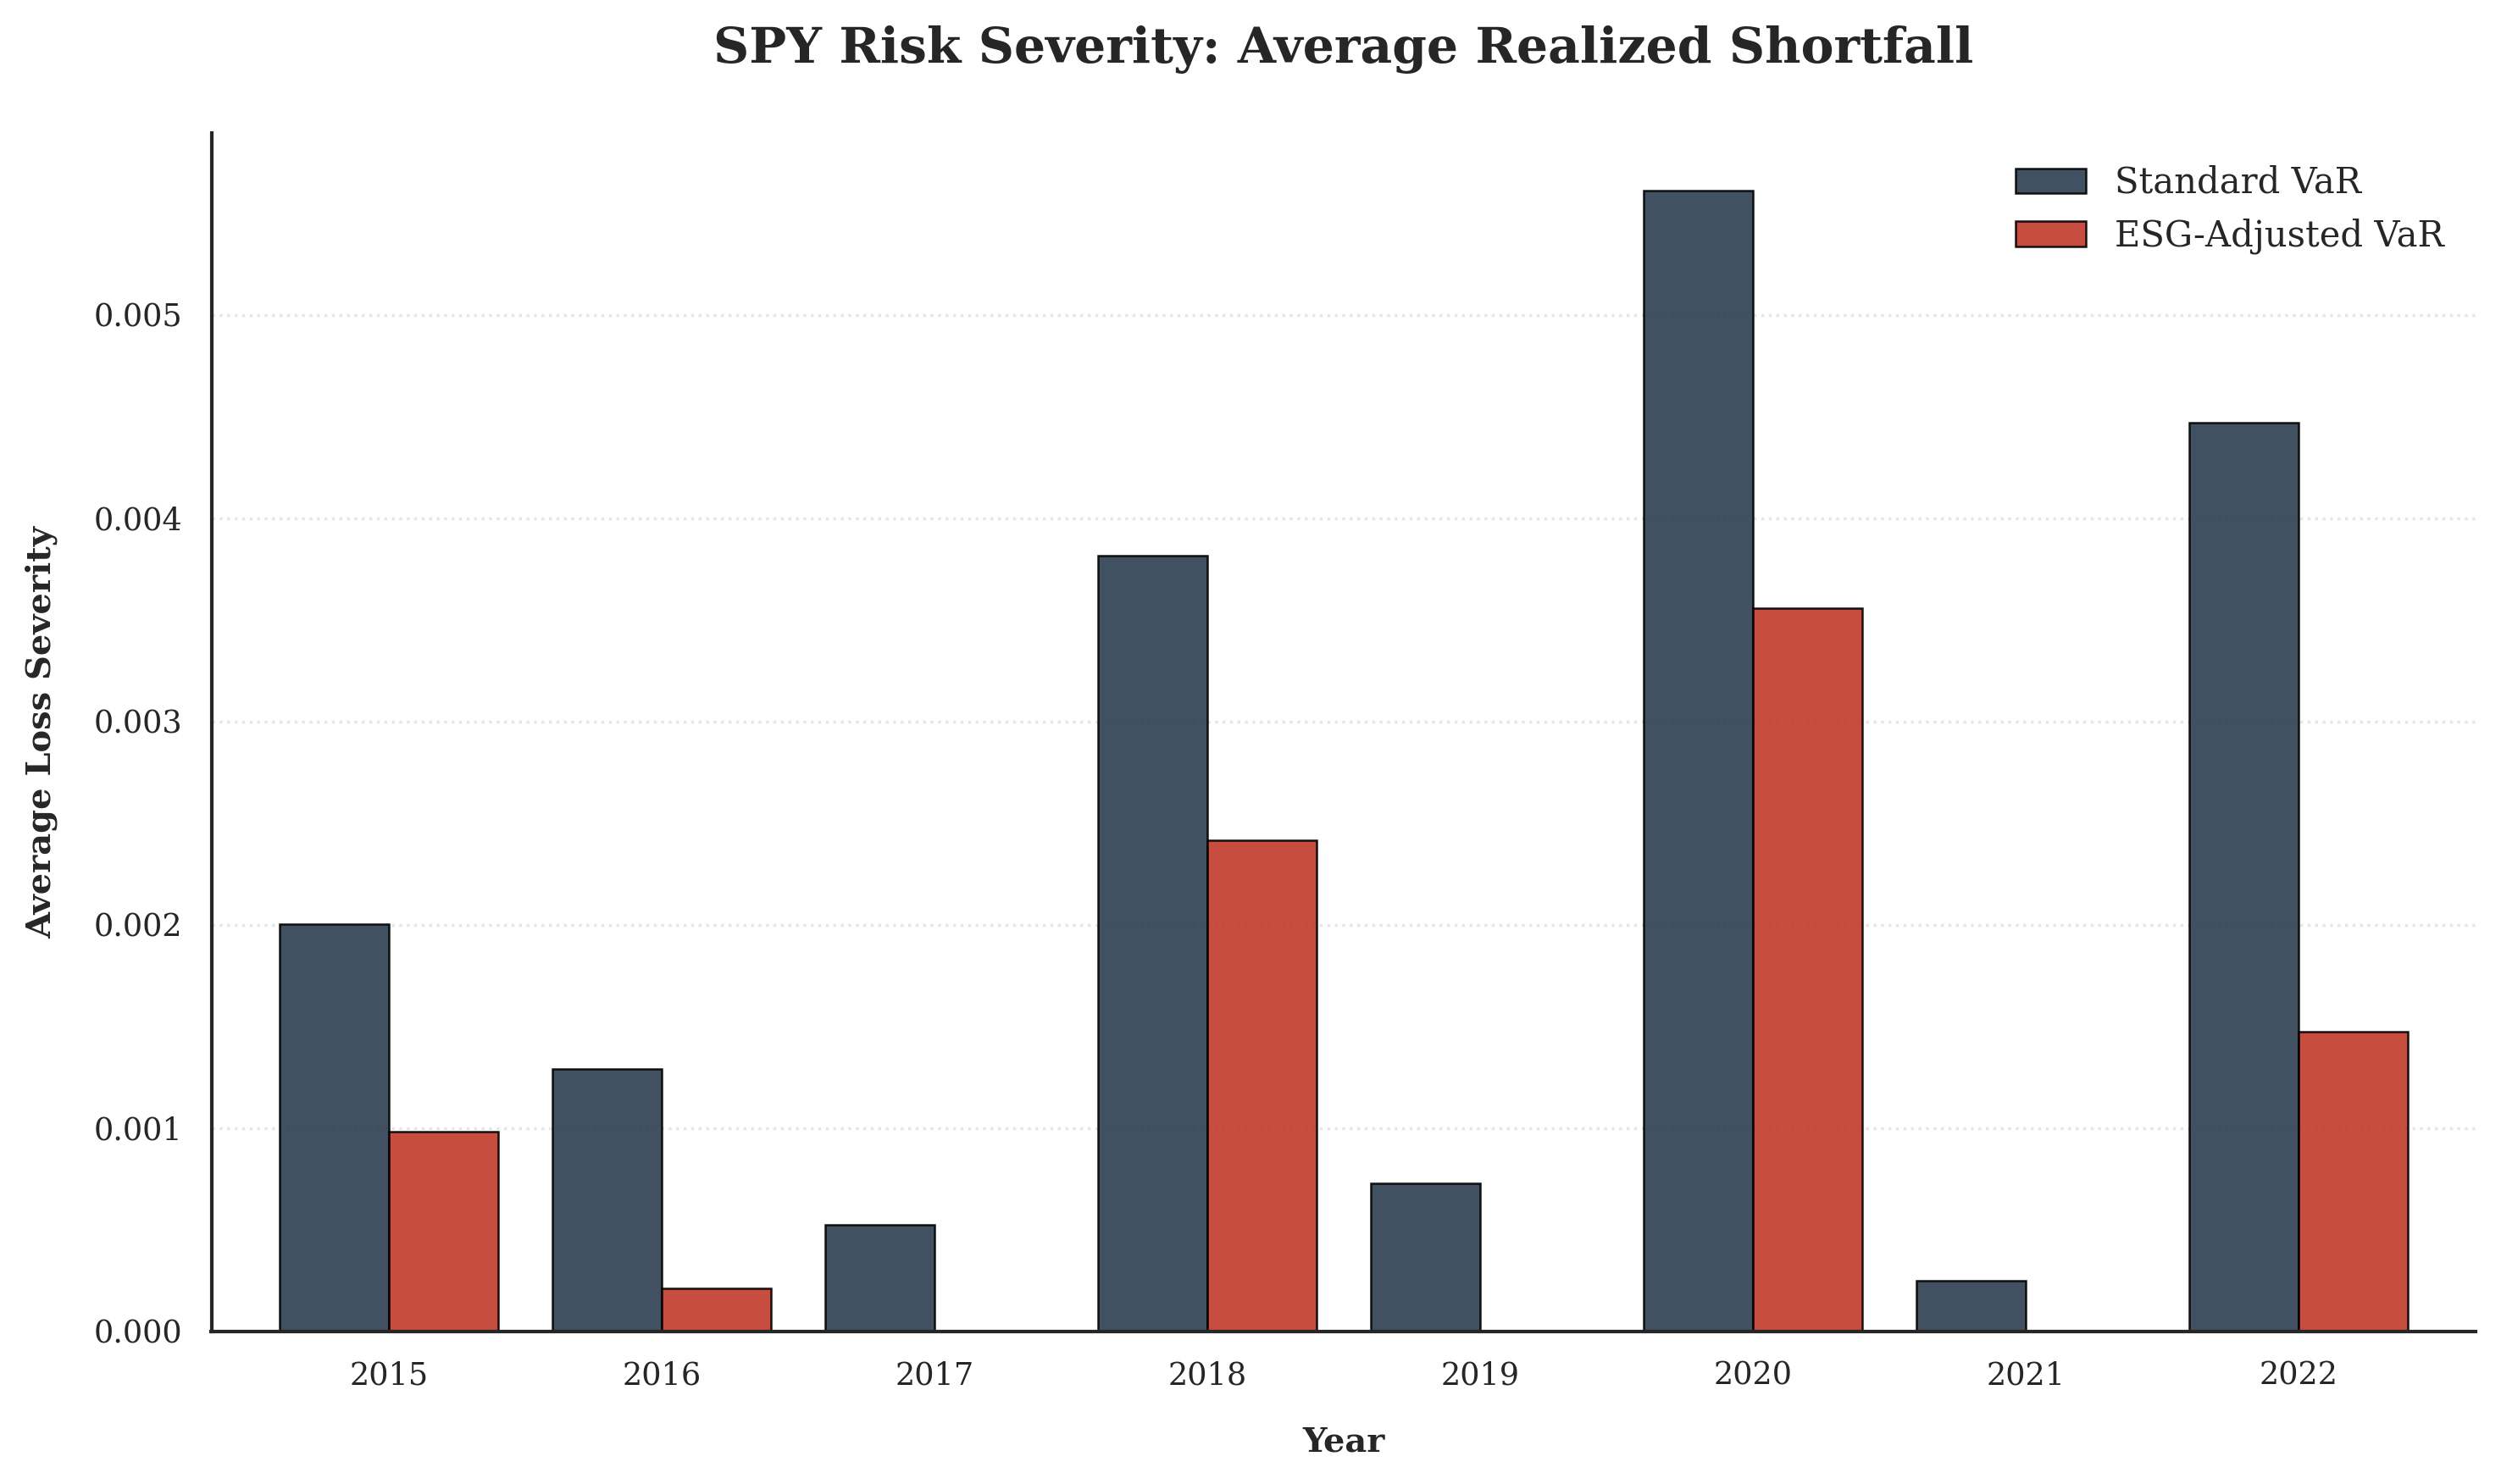

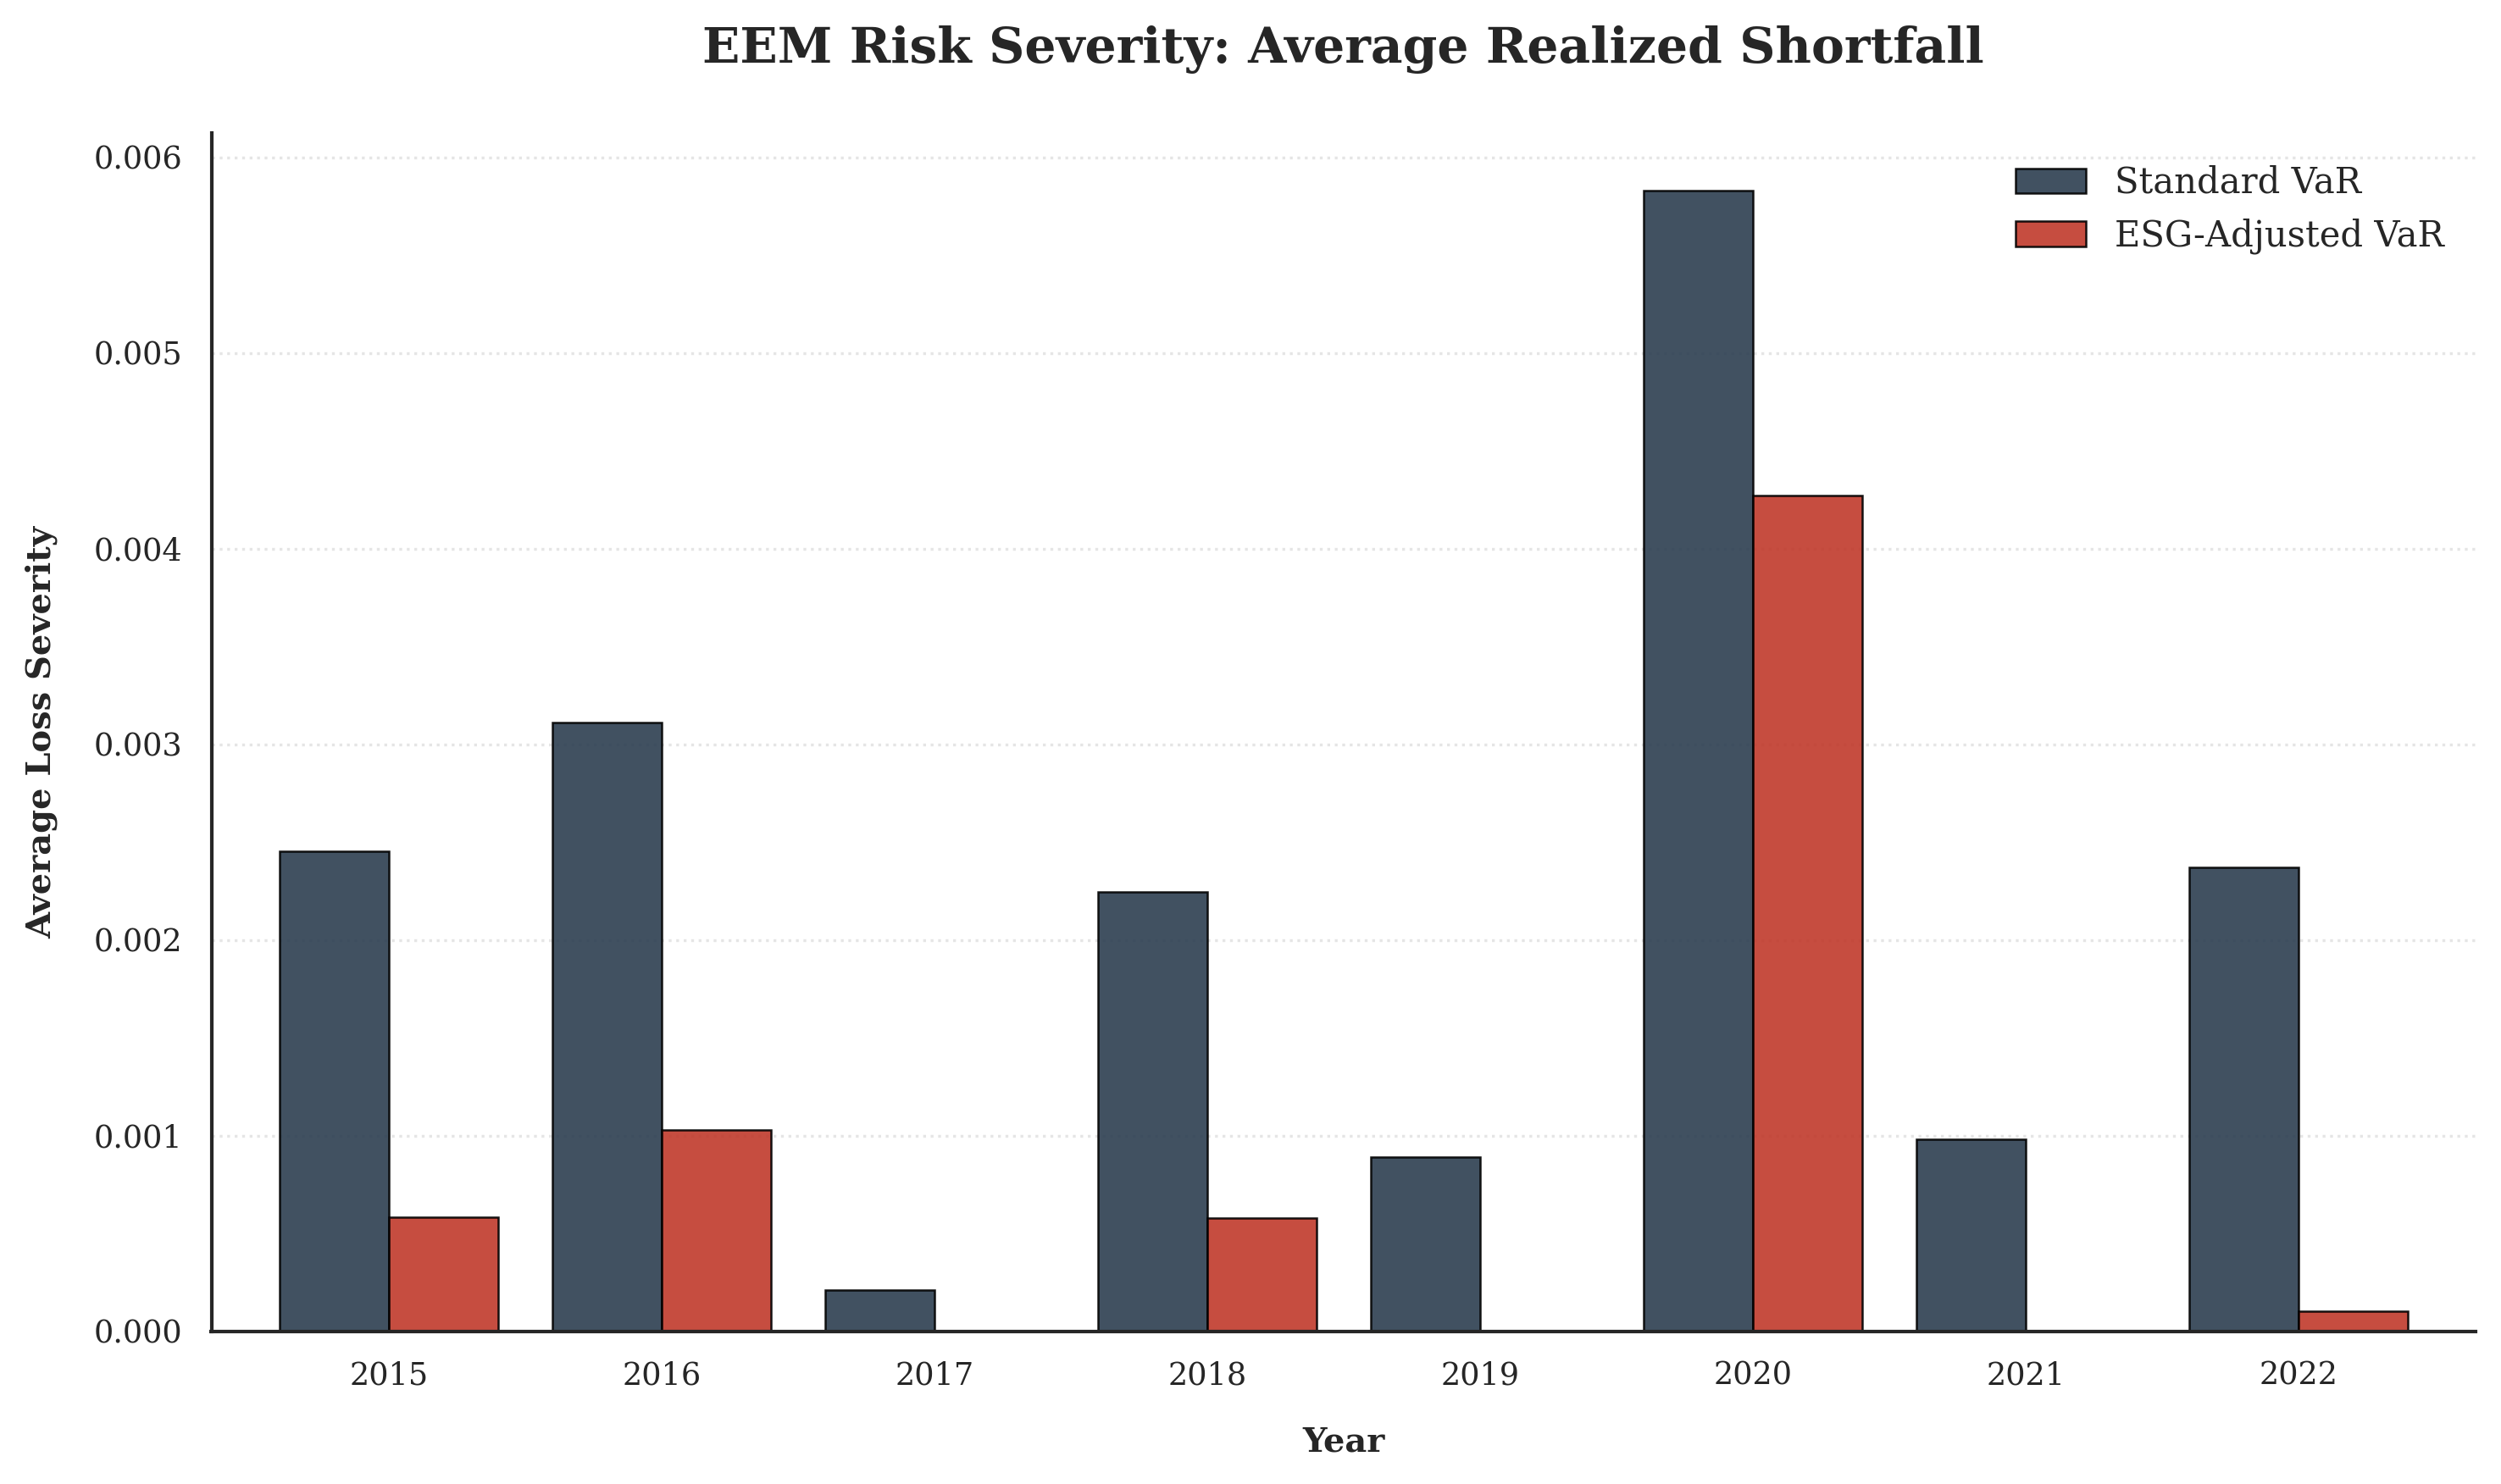

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Use the previous global style settings ---
sns.set_theme(style="white", context="paper")
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.labelweight": "bold",
    "axes.titlesize": 14,
    "figure.dpi": 300
})

# Unify color definitions (consistent with previous VaR/Violations)
COLOR_STD = "#2c3e50" # Dark blue-gray (Standard VaR)
COLOR_ESG = "#c0392b" # Brick red (ESG VaR)

def plot_shortfall_comparison(data, ticker_name):

    shortfall_data = data.groupby("year")[[
        "realised_avg_shortfall_var",
        "realised_avg_shortfall_varesg_adv"
    ]].mean()

    # 👉 rename for clean legend
    shortfall_data = shortfall_data.rename(columns={
        "realised_avg_shortfall_var": "Standard VaR",
        "realised_avg_shortfall_varesg_adv": "ESG-Adjusted VaR"
    })

    fig, ax = plt.subplots(figsize=(10, 6))

    shortfall_data.plot(kind="bar",
                        ax=ax,
                        width=0.8,
                        edgecolor="black",
                        linewidth=0.6,
                        color=[COLOR_STD, COLOR_ESG],
                        alpha=0.9)

    ax.set_title(f"{ticker_name} Risk Severity: Average Realized Shortfall",
                 fontsize=14, fontweight="bold", pad=20)
    ax.set_ylabel("Average Loss Severity", labelpad=10)
    ax.set_xlabel("Year", labelpad=10)

    ax.legend(frameon=False, loc="upper right", fontsize=10)
    ax.grid(axis="y", linestyle=":", alpha=0.5)
    sns.despine()

    plt.xticks(rotation=0)
    plt.tight_layout()

    return fig

# --- 2. Perform plotting ---

# Output SPY Shortfall comparison plot
fig_spy_shortfall = plot_shortfall_comparison(spy_compare, "SPY")
plt.show()

# Output EEM Shortfall comparison plot
fig_eem_shortfall = plot_shortfall_comparison(eem_compare, "EEM")
plt.show()

In [ ]:
import os

VIS_DIR = "/content/drive/MyDrive/Colab Notebooks/Data Analytics/group project/visualization"
os.makedirs(VIS_DIR, exist_ok=True)

print("Visualization folder ready:", VIS_DIR)

Visualization folder ready: /content/drive/MyDrive/Colab Notebooks/Data Analytics/group project/visualization


In [ ]:
import os
import pandas as pd

ADV_DIR = "/content/drive/MyDrive/Colab Notebooks/Data Analytics/group project/advanced_analysis_data"
CLEAN_DIR = "/content/drive/MyDrive/Colab Notebooks/Data Analytics/group project/clean_data"
VIS_DIR = "/content/drive/MyDrive/Colab Notebooks/Data Analytics/group project/visualization"

os.makedirs(VIS_DIR, exist_ok=True)

spy_compare = pd.read_excel(f"{ADV_DIR}/SPY_monthly_comparison_advanced.xlsx")
eem_compare = pd.read_excel(f"{ADV_DIR}/EEM_monthly_comparison_advanced.xlsx")

spy_full = pd.read_excel(f"{ADV_DIR}/SPY_full_summary_advanced.xlsx")
eem_full = pd.read_excel(f"{ADV_DIR}/EEM_full_summary_advanced.xlsx")

spy_holdings = pd.read_excel(f"{CLEAN_DIR}/SPY_final_cleaned_with_lag_esg_v2.xlsx")
eem_holdings = pd.read_excel(f"{CLEAN_DIR}/EEM_final_cleaned_with_lag_esg_v3.xlsx")

print("Data loaded successfully.")

Data loaded successfully.


In [ ]:
table1 = pd.concat([spy_full, eem_full], ignore_index=True)

table1 = table1[[
    "etf",
    "var_violations",
    "varesg_adv_violations",
    "violation_reduction_adv",
    "avg_realised_shortfall_var",
    "avg_realised_shortfall_varesg_adv",
    "total_unexpected_loss_var",
    "total_unexpected_loss_varesg_adv"
]].copy()

table1 = table1.rename(columns={
    "etf": "ETF",
    "var_violations": "VaR Violations",
    "varesg_adv_violations": "VaRESG Violations",
    "violation_reduction_adv": "Violation Reduction",
    "avg_realised_shortfall_var": "Avg Shortfall (VaR)",
    "avg_realised_shortfall_varesg_adv": "Avg Shortfall (VaRESG)",
    "total_unexpected_loss_var": "Total Unexpected Loss (VaR)",
    "total_unexpected_loss_varesg_adv": "Total Unexpected Loss (VaRESG)"
})

print("Table 1 preview:")
print(table1)

table1.to_excel(f"{VIS_DIR}/Table_1_Overall_Performance.xlsx", index=False)
print(f"Saved: {VIS_DIR}/Table_1_Overall_Performance.xlsx")

Table 1 preview:
   ETF  VaR Violations  VaRESG Violations  Violation Reduction  \
0  SPY              66                 33                   33   
1  EEM              48                 18                   30   

   Avg Shortfall (VaR)  Avg Shortfall (VaRESG)  Total Unexpected Loss (VaR)  \
0             0.002361                0.001242                     0.692300   
1             0.002242                0.001019                     0.558748   

   Total Unexpected Loss (VaRESG)  
0                        0.490882  
1                        0.372762  
Saved: /content/drive/MyDrive/Colab Notebooks/Data Analytics/group project/visualization/Table_1_Overall_Performance.xlsx


In [ ]:
print("SPY compare columns:")
print(spy_compare.columns.tolist())

print("\nEEM compare columns:")
print(eem_compare.columns.tolist())

SPY compare columns:
['actual_month', 'n_days', 'var_violations', 'varesg_adv_violations', 'total_unexpected_loss_var', 'total_unexpected_loss_varesg_adv', 'realised_avg_shortfall_var', 'realised_avg_shortfall_varesg_adv', 'var_level', 'varesg_adv_level', 'max_loss', 'forecast_origin_date', 'etf', 'year', 'violation_reduction_adv', 'shortfall_reduction_adv']

EEM compare columns:
['actual_month', 'n_days', 'var_violations', 'varesg_adv_violations', 'total_unexpected_loss_var', 'total_unexpected_loss_varesg_adv', 'realised_avg_shortfall_var', 'realised_avg_shortfall_varesg_adv', 'var_level', 'varesg_adv_level', 'max_loss', 'forecast_origin_date', 'etf', 'year', 'violation_reduction_adv', 'shortfall_reduction_adv']


In [ ]:
spy_2020 = spy_compare[spy_compare["year"] == 2020].copy()
eem_2020 = eem_compare[eem_compare["year"] == 2020].copy()

table2 = pd.concat([spy_2020, eem_2020], ignore_index=True)

table2 = table2[[
    "etf",
    "actual_month",
    "var_violations",
    "varesg_adv_violations",
    "realised_avg_shortfall_var",
    "realised_avg_shortfall_varesg_adv",
    "total_unexpected_loss_var",
    "total_unexpected_loss_varesg_adv"
]].copy()

table2 = table2.rename(columns={
    "etf": "ETF",
    "actual_month": "Month",
    "var_violations": "VaR Violations",
    "varesg_adv_violations": "VaRESG Violations",
    "realised_avg_shortfall_var": "Avg Shortfall (VaR)",
    "realised_avg_shortfall_varesg_adv": "Avg Shortfall (VaRESG)",
    "total_unexpected_loss_var": "Total Unexpected Loss (VaR)",
    "total_unexpected_loss_varesg_adv": "Total Unexpected Loss (VaRESG)"
})

print("Table 2 preview:")
print(table2.head())

table2.to_excel(f"{VIS_DIR}/Table_2_Crisis_Performance_2020.xlsx", index=False)
print(f"Saved: {VIS_DIR}/Table_2_Crisis_Performance_2020.xlsx")

Table 2 preview:
   ETF    Month  VaR Violations  VaRESG Violations  Avg Shortfall (VaR)  \
0  SPY  2020-01               1                  0             0.000754   
1  SPY  2020-02               3                  3             0.017921   
2  SPY  2020-03               8                  6             0.033720   
3  SPY  2020-04               1                  0             0.002783   
4  SPY  2020-05               0                  0             0.000000   

   Avg Shortfall (VaRESG)  Total Unexpected Loss (VaR)  \
0                0.000000                     0.000754   
1                0.011308                     0.053762   
2                0.031363                     0.269757   
3                0.000000                     0.002783   
4                0.000000                     0.000000   

   Total Unexpected Loss (VaRESG)  
0                        0.000000  
1                        0.033925  
2                        0.188177  
3                        0.000000  
4  

In [ ]:
table_2022 = pd.concat([spy_2022, eem_2022], ignore_index=True)

table_2022 = table_2022[[
    "etf",
    "actual_month",
    "var_violations",
    "varesg_adv_violations",
    "realised_avg_shortfall_var",
    "realised_avg_shortfall_varesg_adv",
    "total_unexpected_loss_var",
    "total_unexpected_loss_varesg_adv"
]].copy()

table_2022 = table_2022.rename(columns={
    "etf": "ETF",
    "actual_month": "Month",
    "var_violations": "VaR Violations",
    "varesg_adv_violations": "VaRESG Violations",
    "realised_avg_shortfall_var": "Avg Shortfall (VaR)",
    "realised_avg_shortfall_varesg_adv": "Avg Shortfall (VaRESG)",
    "total_unexpected_loss_var": "Total Unexpected Loss (VaR)",
    "total_unexpected_loss_varesg_adv": "Total Unexpected Loss (VaRESG)"
})

print(table_2022)

table_2022.to_excel(f"{VIS_DIR}/Table5_Downturn_2022.xlsx", index=False)
print(f"Saved: {VIS_DIR}/Table5_Downturn_2022.xlsx")

    ETF    Month  VaR Violations  VaRESG Violations  Avg Shortfall (VaR)  \
0   SPY  2022-01               2                  0             0.000210   
1   SPY  2022-02               2                  0             0.002323   
2   SPY  2022-03               1                  1             0.008282   
3   SPY  2022-04               3                  1             0.008509   
4   SPY  2022-05               3                  2             0.011291   
5   SPY  2022-06               3                  1             0.006191   
6   SPY  2022-07               0                  0             0.000000   
7   SPY  2022-08               1                  0             0.003842   
8   SPY  2022-09               1                  1             0.013001   
9   SPY  2022-10               0                  0             0.000000   
10  SPY  2022-11               0                  0             0.000000   
11  SPY  2022-12               0                  0             0.000000   
12  EEM  202

In [ ]:
spy_yearly = spy_compare.groupby("year")[[
    "var_violations",
    "varesg_adv_violations",
    "violation_reduction_adv"
]].sum().reset_index()
spy_yearly["etf"] = "SPY"

eem_yearly = eem_compare.groupby("year")[[
    "var_violations",
    "varesg_adv_violations",
    "violation_reduction_adv"
]].sum().reset_index()
eem_yearly["etf"] = "EEM"

table3 = pd.concat([spy_yearly, eem_yearly], ignore_index=True)

table3 = table3[[
    "etf",
    "year",
    "var_violations",
    "varesg_adv_violations",
    "violation_reduction_adv"
]].copy()

table3 = table3.rename(columns={
    "etf": "ETF",
    "year": "Year",
    "var_violations": "VaR Violations",
    "varesg_adv_violations": "VaRESG Violations",
    "violation_reduction_adv": "Violation Reduction"
})

print("Table 3 preview:")
print(table3)

table3.to_excel(f"{VIS_DIR}/Table_3_Yearly_Violation_Comparison.xlsx", index=False)
print(f"Saved: {VIS_DIR}/Table_3_Yearly_Violation_Comparison.xlsx")

Table 3 preview:
    ETF  Year  VaR Violations  VaRESG Violations  Violation Reduction
0   SPY  2015               7                  3                    4
1   SPY  2016               4                  1                    3
2   SPY  2017               3                  0                    3
3   SPY  2018              16                  7                    9
4   SPY  2019               4                  0                    4
5   SPY  2020              14                  9                    5
6   SPY  2021               2                  0                    2
7   SPY  2022              16                  6                   10
8   EEM  2015               7                  2                    5
9   EEM  2016               5                  1                    4
10  EEM  2017               2                  0                    2
11  EEM  2018              10                  4                    6
12  EEM  2019               4                  0                    4
13 

In [ ]:
def calc_esg_coverage(df, etf_name):
    data = df.copy()
    data["ESG Score"] = pd.to_numeric(data["ESG Score"], errors="coerce")

    coverage = (
        data.groupby("year")
        .agg(
            total_weight=("Weight", "sum"),
            esg_weight=("Weight", lambda x: x[data.loc[x.index, "ESG Score"].notna()].sum()),
            n_obs=("RIC", "count"),
            n_esg=("ESG Score", lambda x: x.notna().sum())
        )
        .reset_index()
    )

    coverage["weight_coverage_ratio"] = coverage["esg_weight"] / coverage["total_weight"]
    coverage["obs_coverage_ratio"] = coverage["n_esg"] / coverage["n_obs"]
    coverage["etf"] = etf_name

    return coverage

spy_coverage = calc_esg_coverage(spy_holdings, "SPY")
eem_coverage = calc_esg_coverage(eem_holdings, "EEM")

table4 = pd.concat([spy_coverage, eem_coverage], ignore_index=True)

table4 = table4[[
    "etf",
    "year",
    "weight_coverage_ratio",
    "obs_coverage_ratio"
]].copy()

table4 = table4.rename(columns={
    "etf": "ETF",
    "year": "Year",
    "weight_coverage_ratio": "Weight Coverage",
    "obs_coverage_ratio": "Observation Coverage"
})

print("Table 4 preview:")
print(table4)

table4.to_excel(f"{VIS_DIR}/Table_4_ESG_Data_Coverage.xlsx", index=False)
print(f"Saved: {VIS_DIR}/Table_4_ESG_Data_Coverage.xlsx")

Table 4 preview:
    ETF  Year  Weight Coverage  Observation Coverage
0   SPY  2015         0.949600              0.924303
1   SPY  2016         0.982320              0.978044
2   SPY  2017         0.982546              0.982000
3   SPY  2018         0.996459              0.992032
4   SPY  2019         0.989784              0.982000
5   SPY  2020         0.994998              0.984000
6   SPY  2021         0.995684              0.986000
7   SPY  2022         0.996175              0.986000
8   EEM  2015         0.919137              0.907005
9   EEM  2016         0.955652              0.957524
10  EEM  2017         0.979532              0.942857
11  EEM  2018         0.986113              0.971522
12  EEM  2019         0.978853              0.903979
13  EEM  2020         0.986750              0.974695
14  EEM  2021         0.979938              0.960000
15  EEM  2022         0.986724              0.964758
Saved: /content/drive/MyDrive/Colab Notebooks/Data Analytics/group project/visuali